In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel

# Mean and std for group without SMOTE (No)
means_no = {
    'FCGR': [0.9867, 0.9899, 0.9862, 0.9784],
    'One-hot': [0.9500, 0.9579, 0.9248, 0.9357],
    'LE': [0.9552, 0.9575, 0.9238, 0.9003],
    'k-mer': [0.9858, 0.9793, 0.9786, 0.9860]
}
stds_no = {
    'FCGR': [0.001, 0.000, 0.001, 0.008],
    'One-hot': [0.002, 0.001, 0.001, 0.003],
    'LE': [0.001, 0.001, 0.001, 0.005],
    'k-mer': [0.001, 0.001, 0.001, 0.0052]
}

# Mean and std for group with SMOTE (Yes)
means_yes = {
    'FCGR': [0.9882, 0.9885, 0.9882, 0.9871],
    'One-hot': [0.9421, 0.9550, 0.9271, 0.9420],
    'LE': [0.8910, 0.9595, 0.9246, 0.9125],
    'k-mer': [0.9885, 0.9925, 0.9872, 0.9893]
}
stds_yes = {
    'FCGR': [0.0015, 0.001, 0.001, 0.0014],
    'One-hot': [0.003, 0.001, 0.002, 0.003],
    'LE': [0.004, 0.001, 0.001, 0.004],
    'k-mer': [0.001, 0.001, 0.001, 0.001]
}

# Simulate 30 samples from each distribution
np.random.seed(0)
samples_no = {key: np.concatenate([np.random.normal(m, s, 30) for m, s in zip(means_no[key], stds_no[key])]) for key in means_no}
samples_yes = {key: np.concatenate([np.random.normal(m, s, 30) for m, s in zip(means_yes[key], stds_yes[key])]) for key in means_yes}

# Perform paired t-test
ttest_results = {
    key: ttest_rel(samples_yes[key], samples_no[key])
    for key in samples_no
}

# Format results
results_df = pd.DataFrame({
    'Encoding': list(ttest_results.keys()),
    't-statistic': [ttest_results[k].statistic for k in ttest_results],
    'p-value': [ttest_results[k].pvalue for k in ttest_results]
})

results_df

,Encoding,t-statistic,p-value
0,FCGR,3.191944,1.807878e-03
1,One-hot,-1.264736,2.084371e-01
2,LE,-4.160047,6.037979e-05
3,k-mer,14.859357,6.952938e-29


In [ ]:
import numpy as np
from scipy.stats import ttest_rel
import pandas as pd

# Simulate data using mean and std for each encoding method and model
# With SMOTE + GC content
group1_means = {
    "k-mer":   [0.9872, 0.9901, 0.9902, 0.9885],
    "FCGR":    [0.9882, 0.9890, 0.9907, 0.9840],
    "One-hot": [0.9266, 0.9547, 0.9467, 0.9356],
    "Label":   [0.9246, 0.9577, 0.9595, 0.8904],
}
group1_stds = {
    "k-mer":   [0.001, 0.001, 0.001, 0.001],
    "FCGR":    [0.001, 0.001, 0.001, 0.001],
    "One-hot": [0.002, 0.002, 0.002, 0.002],
    "Label":   [0.001, 0.001, 0.001, 0.001],
}

# No SMOTE + No GC
group2_means = {
    "k-mer":   [0.9786, 0.9858, 0.9793, 0.9860],
    "FCGR":    [0.9862, 0.9867, 0.9899, 0.9784],
    "One-hot": [0.9248, 0.9500, 0.9579, 0.9357],
    "Label":   [0.9238, 0.9552, 0.9575, 0.9003],
}
group2_stds = {
    "k-mer":   [0.001, 0.001, 0.001, 0.0052],
    "FCGR":    [0.001, 0.001, 0.000, 0.008],
    "One-hot": [0.001, 0.002, 0.001, 0.003],
    "Label":   [0.001, 0.001, 0.001, 0.005],
}

# Generate samples
np.random.seed(0)
num_samples = 20
results = []

for encoding in group1_means:
    g1_samples = []
    g2_samples = []
    for mean, std in zip(group1_means[encoding], group1_stds[encoding]):
        g1_samples.extend(np.random.normal(mean, std, num_samples))
    for mean, std in zip(group2_means[encoding], group2_stds[encoding]):
        g2_samples.extend(np.random.normal(mean, std, num_samples))
    t_stat, p_val = ttest_rel(g1_samples, g2_samples)
    results.append({
        "Encoding": encoding,
        "Group1 Mean": np.mean(g1_samples),
        "Group2 Mean": np.mean(g2_samples),
        "t-statistic": round(t_stat, 4),
        "p-value": round(p_val, 8)
    })

df_results = pd.DataFrame(results)
df_results[['Encoding','t-statistic', 'p-value']]

,Encoding,t-statistic,p-value
0,k-mer,12.6227,0.000000
1,FCGR,6.8076,0.000000
2,One-hot,-2.0000,0.048932
3,Label,-1.7213,0.089110


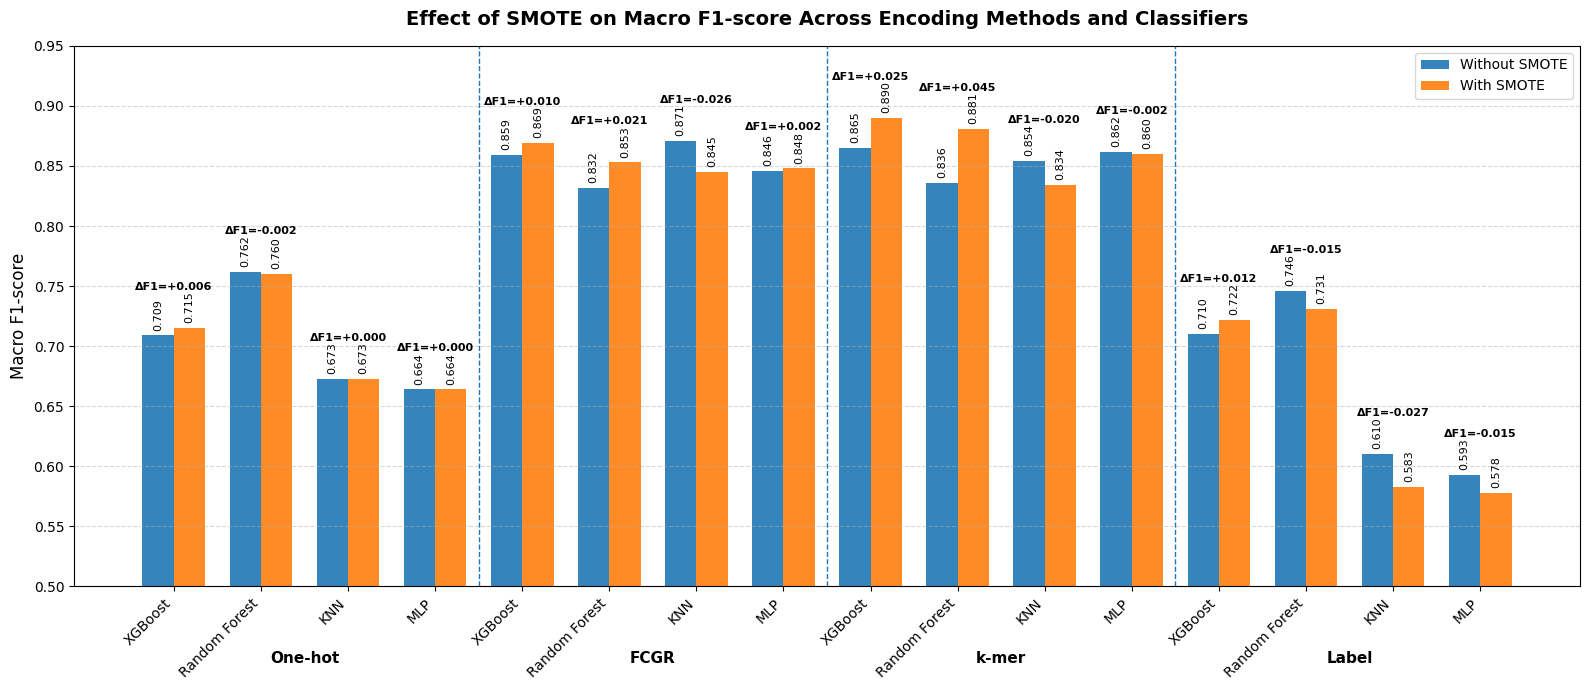

Figure saved as: smote_macro_f1_comparison.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Data from your table
# ============================================================

data = [
    # Encoding, Model, F1_without_smote, F1_with_smote
    ["One-hot", "XGBoost",       0.709, 0.715],
    ["One-hot", "Random Forest", 0.762, 0.760],
    ["One-hot", "KNN",           0.673, 0.673],
    ["One-hot", "MLP",           0.664, 0.664],

    ["FCGR",    "XGBoost",       0.859, 0.869],
    ["FCGR",    "Random Forest", 0.832, 0.853],
    ["FCGR",    "KNN",           0.871, 0.845],
    ["FCGR",    "MLP",           0.846, 0.848],

    ["k-mer",   "XGBoost",       0.865, 0.890],
    ["k-mer",   "Random Forest", 0.836, 0.881],
    ["k-mer",   "KNN",           0.854, 0.834],
    ["k-mer",   "MLP",           0.862, 0.860],

    ["Label",   "XGBoost",       0.710, 0.722],
    ["Label",   "Random Forest", 0.746, 0.731],
    ["Label",   "KNN",           0.610, 0.583],
    ["Label",   "MLP",           0.593, 0.578],
]

df = pd.DataFrame(
    data,
    columns=["Encoding", "Model", "F1_without_SMOTE", "F1_with_SMOTE"]
)

df["Delta_F1"] = df["F1_with_SMOTE"] - df["F1_without_SMOTE"]


# ============================================================
# 2. Plot settings
# ============================================================

encodings = ["One-hot", "FCGR", "k-mer", "Label"]
models = ["XGBoost", "Random Forest", "KNN", "MLP"]

# Keep a consistent order
df["Encoding"] = pd.Categorical(df["Encoding"], categories=encodings, ordered=True)
df["Model"] = pd.Categorical(df["Model"], categories=models, ordered=True)
df = df.sort_values(["Encoding", "Model"]).reset_index(drop=True)

x = np.arange(len(df))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(16, 7))


# ============================================================
# 3. Bars
# ============================================================

bars_without = ax.bar(
    x - bar_width / 2,
    df["F1_without_SMOTE"],
    width=bar_width,
    label="Without SMOTE",
    alpha=0.9
)

bars_with = ax.bar(
    x + bar_width / 2,
    df["F1_with_SMOTE"],
    width=bar_width,
    label="With SMOTE",
    alpha=0.9
)


# ============================================================
# 4. Annotate bar values
# ============================================================

def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.004,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

annotate_bars(bars_without)
annotate_bars(bars_with)


# ============================================================
# 5. Annotate delta F1 above each pair
# ============================================================

for i, row in df.iterrows():
    y_max = max(row["F1_without_SMOTE"], row["F1_with_SMOTE"])
    delta = row["Delta_F1"]
    sign = "+" if delta >= 0 else ""
    ax.text(
        i,
        y_max + 0.03,
        f"ΔF1={sign}{delta:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )


# ============================================================
# 6. X-axis labels and encoding group labels
# ============================================================

ax.set_xticks(x)
ax.set_xticklabels(df["Model"], rotation=45, ha="right")

# Add vertical separators between encoding groups
group_size = 4
for g in range(1, len(encodings)):
    ax.axvline(g * group_size - 0.5, linestyle="--", linewidth=1)

# Add encoding labels below groups
group_centers = [1.5, 5.5, 9.5, 13.5]
for center, encoding in zip(group_centers, encodings):
    ax.text(
        center,
        -0.12,
        encoding,
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=11,
        fontweight="bold"
    )


# ============================================================
# 7. Styling
# ============================================================

ax.set_ylabel("Macro F1-score", fontsize=12)
ax.set_title(
    "Effect of SMOTE on Macro F1-score Across Encoding Methods and Classifiers",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_ylim(0.50, 0.95)
ax.legend(frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()


# ============================================================
# 8. Save figure
# ============================================================

output_path = "smote_macro_f1_comparison.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved as: {output_path}")

### Integrate Supplementary Features, all encoding methods are inculded in different cells

In [ ]:
# integrating features from onehot encoding and gc skew (and/or at/gc content)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def nucleotide_composition(sequence):
    """Calculates mono, di, and tri-nucleotide composition."""
    composition = {}
    for n in range(1, 4):  # Mono, di, tri-nucleotide
        counts = {sequence[i:i+n]: sequence[i:i+n].count(sequence[i:i+n])
                  for i in range(len(sequence) - n + 1)}
        total = sum(counts.values())
        composition.update({f"{n}-mer_{key}": val / total for key, val in counts.items()})
    return composition

def one_hot_encode(sequence):
    """
    One-hot encodes a DNA sequence.

    Args:
        sequence (str): DNA sequence consisting of 'A', 'T', 'G', 'C'.

    Returns:
        np.ndarray: One-hot encoded matrix of shape (len(sequence), 4).
    """
    # Define a mapping for each nucleotide
    mapping = {'A': [1, 0, 0, 0],
               'T': [0, 1, 0, 0],
               'G': [0, 0, 1, 0],
               'C': [0, 0, 0, 1]}

    # Convert sequence to one-hot encoded matrix
    one_hot_matrix = np.array([mapping.get(nucleotide, [0, 0, 0, 0]) for nucleotide in sequence])
    return one_hot_matrix.flatten()  # Flatten into a 1D vector


def preprocess_dataframe_with_additional_features(df, ngram_range=(6, 6), max_features=5000):
    """
    Processes the dataframe to encode sequences using CountVectorizer for k-mer frequencies
    and adds additional features like GC content, AT/GC skew, and nucleotide composition.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        ngram_range (tuple): Range of n-grams to use in encoding.
        max_features (int): Maximum number of features to include in CountVectorizer.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # one-hot encoding features
    onehot_features = []
    for sequence in df['seq']:
        onehot_features.append(one_hot_encode(sequence))


    # Pad sequences to a fixed length (assuming max_seq_length is the desired length)
    max_seq_length = 1000
    onehot_padded_features = pad_sequences(onehot_features, maxlen=max_seq_length, padding='post').tolist()

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        features = {
            'gc_content': calculate_gc_content(sequence),
        }
        # features = {}
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        # Add mono, di, tri-nucleotide composition
        # features.update(nucleotide_composition(sequence))
        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine k-mer and additional features
    onehot_features_df = pd.DataFrame(onehot_padded_features)
    combined_features = pd.concat([onehot_features_df, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, le


def train_model_with_additional_features(df):
    """
    Main function to preprocess data using CountVectorizer and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.

    Returns:
        rf (RandomForestClassifier): Trained Random Forest model.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Preprocess data
    X, y, le = preprocess_dataframe_with_additional_features(df)


    dataset = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)],axis=1)
    dataset["seq"] = df["seq"].reset_index(drop=True)
    dataset["genotype"] = df["genotype"].reset_index(drop=True)

    # # Split data
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # # Train Random Forest Classifier
    # rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # rf.fit(X_train, y_train)

    # # Evaluate the model
    # y_pred = rf.predict(X_test)
    # print("Classification Report:")
    # print(classification_report(y_test, y_pred, target_names=le.classes_))
    # print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    return le, X, y, dataset


# Example Usage:
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y, dataset = train_model_with_additional_features(data)

In [ ]:
dataset.drop('gc_skew',axis=1,inplace=True)
# dataset

In [ ]:
# Do the FCGR then combine the extracted features with the gc skew (and/or other additional features)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def generate_fcgr(sequence, k=5, grid_size=32):
    """
    Generate a Frequency Chaos Game Representation (FCGR) grid from a DNA sequence.

    Parameters:
        sequence (str): DNA sequence (A, T, C, G).
        k (int): Length of k-mers.
        grid_size (int): Resolution of the FCGR grid (e.g., 32x32 for k=5).

    Returns:
        np.array: FCGR grid of size grid_size x grid_size.
    """
    # Initialize an empty grid
    fcgr = np.zeros((grid_size, grid_size))

    # Scale factor for mapping coordinates
    scale = grid_size / (2 ** k)

    # Create mapping from nucleotide pairs to 2D coordinates
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}

    # Iterate over k-mers in the sequence
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i + k]

        # Calculate x and y positions based on k-mer
        x, y = 0, 0
        valid_kmer = True
        for j, nucleotide in enumerate(kmer):
            if nucleotide not in mapping:
                valid_kmer = False
                break
            # Update x and y based on nucleotide position
            factor = 2 ** (k - j - 1)
            x += mapping[nucleotide] % 2 * factor
            y += mapping[nucleotide] // 2 * factor

        if valid_kmer:
            # Map x, y to grid and increment the corresponding cell
            grid_x = int(x * scale)
            grid_y = int(y * scale)
            fcgr[grid_y, grid_x] += 1  # Increment the frequency

    return fcgr

def extract_frequencies(fcgr, sub_grid_size=32):
    """
    Divide the FCGR into sub-regions and calculate k-mer frequencies.

    Parameters:
        fcgr (np.array): FCGR grid (e.g., 32x32).
        sub_grid_size (int): Size of sub-grid (e.g., 8x8).

    Returns:
        np.array: Flattened array of frequencies from all sub-regions.
    """
    # Calculate the size of each sub-grid cell
    cell_size = fcgr.shape[0] // sub_grid_size
    frequencies = []

    # Iterate over the sub-grid
    for row in range(sub_grid_size):
        for col in range(sub_grid_size):
            # Extract the sub-region
            sub_region = fcgr[
                row * cell_size:(row + 1) * cell_size,
                col * cell_size:(col + 1) * cell_size
            ]
            # Calculate the frequency as the sum of pixel intensities
            freq = np.sum(sub_region)
            frequencies.append(freq)

    return np.array(frequencies)


def preprocess_dataframe_with_fcgr_encoding(df, k=5,grid_size=32,sub_grid_size=32):
    """
    Processes the dataframe to encode sequences using FCGR and adds additional features.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        resolution (int): Resolution for FCGR encoding.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # Calculate FCGR features
    fcgr_features = []
    for _, row in df.iterrows():
        sequence = row['seq']
        # label = row['genotype']

        # Generate FCGR for the sequence
        fcgr = generate_fcgr(sequence, k, grid_size)

        # Extract frequencies from the FCGR
        frequencies = extract_frequencies(fcgr, sub_grid_size)
        fcgr_features.append(frequencies)

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        features = {}
        features = {
            'gc_content': calculate_gc_content(sequence),
        }
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine FCGR and additional features
    # fcgr_features_df = pd.DataFrame(fcgr_features, columns=[f"fcgr_{i}" for i in range(fcgr_features.shape[1])])
    fcgr_features_df = pd.DataFrame(fcgr_features)
    combined_features = pd.concat([fcgr_features_df, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, le


def train_model_with_additional_features(df, resolution=5):
    """
    Main function to preprocess data using FCGR encoding and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        resolution (int): Resolution for FCGR encoding.

    Returns:
        rf (RandomForestClassifier): Trained Random Forest model.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Preprocess data
    X, y, le = preprocess_dataframe_with_fcgr_encoding(df,k=5)

    # # Split data
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # # Train Random Forest Classifier
    # rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # rf.fit(X_train, y_train)

    # # Evaluate the model
    # y_pred = rf.predict(X_test)
    # print("Classification Report:")
    # print(classification_report(y_test, y_pred, target_names=le.classes_))
    # print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


    dataset = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)],axis=1)
    dataset["seq"] = df["seq"].reset_index(drop=True)
    dataset["genotype"] = df["genotype"].reset_index(drop=True)

    return le, X, y, dataset


# Example Usage:
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y, dataset = train_model_with_additional_features(data)

In [ ]:
dataset.drop('gc_skew',axis=1,inplace=True)

In [ ]:
# integrating features from kmer encoding and gc skew (and/or at/gc content)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def nucleotide_composition(sequence):
    """Calculates mono, di, and tri-nucleotide composition."""
    composition = {}
    for n in range(1, 4):  # Mono, di, tri-nucleotide
        counts = {sequence[i:i+n]: sequence[i:i+n].count(sequence[i:i+n])
                  for i in range(len(sequence) - n + 1)}
        total = sum(counts.values())
        composition.update({f"{n}-mer_{key}": val / total for key, val in counts.items()})
    return composition


def preprocess_dataframe_with_additional_features(df, ngram_range=(5, 5), max_features=1000):
    """
    Processes the dataframe to encode sequences using CountVectorizer for k-mer frequencies
    and adds additional features like GC content, AT/GC skew, and nucleotide composition.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        ngram_range (tuple): Range of n-grams to use in encoding.
        max_features (int): Maximum number of features to include in CountVectorizer.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # Use CountVectorizer for k-mer encoding
    vectorizer = CountVectorizer(analyzer='char', ngram_range=ngram_range, max_features=max_features)
    kmer_features = vectorizer.fit_transform(df['seq']).toarray()
    kmer_feature_names = vectorizer.get_feature_names_out()

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        features = {
            'gc_content': calculate_gc_content(sequence),
        }
        # features = {}
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        # Add mono, di, tri-nucleotide composition
        # features.update(nucleotide_composition(sequence))
        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine k-mer and additional features
    kmer_features_df = pd.DataFrame(kmer_features, columns=kmer_feature_names)
    combined_features = pd.concat([kmer_features_df, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, vectorizer, le


def train_model_with_additional_features(df):
    """
    Main function to preprocess data using CountVectorizer and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.

    Returns:
        rf (RandomForestClassifier): Trained Random Forest model.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Preprocess data
    X, y, vectorizer, le = preprocess_dataframe_with_additional_features(df)

    # Split data
    # # Split data
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # # Train Random Forest Classifier
    # rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # rf.fit(X_train, y_train)

    # # Evaluate the model
    # y_pred = rf.predict(X_test)
    # print("Classification Report:")
    # print(classification_report(y_test, y_pred, target_names=le.classes_))
    # print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


    dataset = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)],axis=1)
    dataset["seq"] = df["seq"].reset_index(drop=True)
    dataset["genotype"] = df["genotype"].reset_index(drop=True)

    return le, X, y, dataset


# Example Usage:
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y, dataset = train_model_with_additional_features(data)

In [ ]:
dataset.drop('gc_content',axis=1,inplace=True)

In [ ]:
# integrating features from label encoding and gc skew (and/or at/gc content)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def nucleotide_composition(sequence):
    """Calculates mono, di, and tri-nucleotide composition."""
    composition = {}
    for n in range(1, 4):  # Mono, di, tri-nucleotide
        counts = {sequence[i:i+n]: sequence[i:i+n].count(sequence[i:i+n])
                  for i in range(len(sequence) - n + 1)}
        total = sum(counts.values())
        composition.update({f"{n}-mer_{key}": val / total for key, val in counts.items()})
    return composition

def label_encode_dna_sequence(sequence):
    """Label encodes a DNA sequence using integer mapping.

    Args:
        sequence (str): DNA sequence consisting of 'A', 'T', 'G', 'C'.

    Returns:
        list: Label encoded sequence as list of integers.
    """
    encoded_sequence = []
    mapping = {'A': 1, 'T': 4, 'C': 2, 'G': 3}
    for base in sequence:
        encoded_sequence.append(mapping.get(base, 0))  # Default to 0 for unknown bases
    return encoded_sequence


def preprocess_dataframe_with_additional_features(df, ngram_range=(5, 5), max_features=1000):
    """
    Processes the dataframe to encode sequences using label encoding
    and adds additional features like GC content, AT/GC skew, and nucleotide composition.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        ngram_range (tuple): Range of n-grams to use in encoding.
        max_features (int): Maximum number of features to include in CountVectorizer.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # Label encode the DNA sequences
    df['encoded_seq'] = df['seq'].apply(label_encode_dna_sequence)

    # Pad sequences to a fixed length
    max_seq_length = 1000
    padded_sequences = pad_sequences(df['encoded_seq'], maxlen=max_seq_length, padding='post')
    label_encoded_features = pd.DataFrame(padded_sequences)

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        features = {
            'gc_content': calculate_gc_content(sequence),
        }
        # features = {}
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        # Add mono, di, tri-nucleotide composition
        # features.update(nucleotide_composition(sequence))
        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine label encoded sequences and additional features
    combined_features = pd.concat([label_encoded_features, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, le


def train_model_with_additional_features(df):
    """
    Main function to preprocess data using label encoding and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.

    Returns:
        le (LabelEncoder): Fitted label encoder for future use.
        X (DataFrame): Feature matrix.
        y (array): Encoded labels.
    """
    # Preprocess data
    X, y, le = preprocess_dataframe_with_additional_features(df)

    dataset = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)],axis=1)
    dataset["seq"] = df["seq"].reset_index(drop=True)
    dataset["genotype"] = df["genotype"].reset_index(drop=True)

    return le, X, y, dataset


# Example Usage:
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y, dataset = train_model_with_additional_features(data)

In [ ]:
dataset.drop('gc_skew',axis=1,inplace=True)

### Label Encoding

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Function to encode DNA sequence
def encode_dna_sequence(sequence):
    encoded_sequence = []
    # mapping = {'A': 1, 'T': 0.5, 'C': 0.25, 'G': 0.75, 'N': 0}
    mapping = {'A': 1, 'T': 4, 'C': 2, 'G': 3}
    for base in sequence:
        encoded_sequence.append(mapping.get(base, 0))  # Default to 0 for unknown bases
    return encoded_sequence

# Read data from dataframe
# Assuming df is the dataframe with 'seq' and 'genotype' columns
# Example:
# df = pd.read_csv('data.csv').sample(3000)
data = pd.read_csv('data.csv')
data = data.drop_duplicates(subset=['seq'], keep='first')
df = data.copy()
# Encode the DNA sequences
df['encoded_seq'] = df['seq'].apply(encode_dna_sequence)

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

max_seq_length = 1000

# Pad sequences to a fixed length (assuming max_seq_length is the desired length)
#max_seq_length = 10  # Example max sequence length

df['padded_seq'] = pad_sequences(df['encoded_seq'], maxlen=max_seq_length, padding='post').tolist()

# Split the data into training and testing sets
X = np.array(df['padded_seq'].tolist())
y = np.array(df['genotype'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['genotype'])

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier


# X = processed_df.drop('genotype', axis=1).values
# y = processed_df['genotype'].values

# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

#
# y_encoded = label_encoder.fit_transform(processed_df['genotype'])

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y, random_state=42
)


# Step 2: Define pipeline
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    # ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ('clf', xgb.XGBClassifier(n_estimators=300,random_state=42,n_jobs=-1))
    # ('KNN', KNeighborsClassifier(n_neighbors=5))
])

# Step 3: Cross-validation on training set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std Dev: {cv_scores.std():.4f}")

# Step 4: Final evaluation on hold-out test set
pipeline.fit(X_train, y_train)
test_score = pipeline.score(X_test, y_test)
print(f"Hold-Out Test Set Accuracy: {test_score:.4f}")

Cross-Validation Accuracy Scores: [0.95099452 0.94724705 0.94667051 0.94811185 0.95156408]
Mean CV Accuracy: 0.9489
CV Std Dev: 0.0020
Hold-Out Test Set Accuracy: 0.9595


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
from imblearn.over_sampling import SMOTE
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.utils import to_categorical

# X = data.drop('genotype', axis=1).values
# y = data['genotype'].values

# y_encoded = LabelEncoder().fit_transform(y)

# Assume X and y are numpy arrays
# Step 1: Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encode y values
num_classes = len(np.unique(y))
y_train_encoded = to_categorical(y_train_full, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

# Step 2: Cross-validation on the training set
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train_full, y_train_full):
    X_train, X_val = X_train_full[train_index], X_train_full[val_index]
    y_train, y_val = y_train_encoded[train_index], y_train_encoded[val_index]

    # Apply SMOTE to training data only
    # smote = SMOTE(random_state=42)
    # X_train, y_train = smote.fit_resample(X_train, y_train)

    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=10,
        verbose=1,
        validation_data=(X_val, y_val)
    )

    val_predictions = model.predict(X_val)
    val_predictions = np.argmax(val_predictions, axis=1)
    y_val_classes = np.argmax(y_val, axis=1)

    accuracy = accuracy_score(y_val_classes, val_predictions)
    cv_scores.append(accuracy)

print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Std Dev: {np.std(cv_scores):.4f}")

# Step 3: Final evaluation on hold-out test set
final_model = Sequential()
final_model.add(Dense(256, activation='relu', input_shape=(X_train_full.shape[1],)))
final_model.add(Dense(num_classes, activation='softmax'))

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
final_model.fit(X_train_full, y_train_encoded, epochs=10, batch_size=32, verbose=1)

test_predictions = final_model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)

test_accuracy = accuracy_score(y_test_classes, test_predictions)
print(f"Hold-Out Test Set Accuracy: {test_accuracy:.4f}")

### FCGR

In [ ]:
import numpy as np
import pandas as pd

def generate_fcgr(sequence, k=5, grid_size=32):
    """
    Generate a Frequency Chaos Game Representation (FCGR) grid from a DNA sequence.

    Parameters:
        sequence (str): DNA sequence (A, T, C, G).
        k (int): Length of k-mers.
        grid_size (int): Resolution of the FCGR grid (e.g., 32x32 for k=5).

    Returns:
        np.array: FCGR grid of size grid_size x grid_size.
    """
    # Initialize an empty grid
    fcgr = np.zeros((grid_size, grid_size))

    # Scale factor for mapping coordinates
    scale = grid_size / (2 ** k)

    # Create mapping from nucleotide pairs to 2D coordinates
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}

    # Iterate over k-mers in the sequence
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i + k]

        # Calculate x and y positions based on k-mer
        x, y = 0, 0
        valid_kmer = True
        for j, nucleotide in enumerate(kmer):
            if nucleotide not in mapping:
                valid_kmer = False
                break
            # Update x and y based on nucleotide position
            factor = 2 ** (k - j - 1)
            x += mapping[nucleotide] % 2 * factor
            y += mapping[nucleotide] // 2 * factor

        if valid_kmer:
            # Map x, y to grid and increment the corresponding cell
            grid_x = int(x * scale)
            grid_y = int(y * scale)
            fcgr[grid_y, grid_x] += 1  # Increment the frequency

    return fcgr

def extract_frequencies(fcgr, sub_grid_size=8):
    """
    Divide the FCGR into sub-regions and calculate k-mer frequencies.

    Parameters:
        fcgr (np.array): FCGR grid (e.g., 32x32).
        sub_grid_size (int): Size of sub-grid (e.g., 8x8).

    Returns:
        np.array: Flattened array of frequencies from all sub-regions.
    """
    # Calculate the size of each sub-grid cell
    cell_size = fcgr.shape[0] // sub_grid_size
    frequencies = []

    # Iterate over the sub-grid
    for row in range(sub_grid_size):
        for col in range(sub_grid_size):
            # Extract the sub-region
            sub_region = fcgr[
                row * cell_size:(row + 1) * cell_size,
                col * cell_size:(col + 1) * cell_size
            ]
            # Calculate the frequency as the sum of pixel intensities
            freq = np.sum(sub_region)
            frequencies.append(freq)

    return np.array(frequencies)

def process_sequences(df, k=5, grid_size=32, sub_grid_size=32):
    """
    Process sequences in a DataFrame to generate FCGRs and extract frequencies.

    Parameters:
        df (pd.DataFrame): DataFrame with 'seq' (sequences) and 'label' columns.
        k (int): Length of k-mers.
        grid_size (int): Resolution of the FCGR grid (e.g., 32x32).
        sub_grid_size (int): Size of sub-grid for frequency extraction (e.g., 8x8).

    Returns:
        pd.DataFrame: DataFrame of extracted frequencies with corresponding labels.
    """
    data = []
    labels = []

    for _, row in df.iterrows():
        sequence = row['seq']
        label = row['genotype']

        # Generate FCGR for the sequence
        fcgr = generate_fcgr(sequence, k, grid_size)

        # Extract frequencies from the FCGR
        frequencies = extract_frequencies(fcgr, sub_grid_size)

        # Append data and label
        data.append(frequencies)
        labels.append(label)


    # Convert to DataFrame
    feature_df = pd.DataFrame(data)
    feature_df['genotype'] = labels
    return feature_df

data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)

# Process the sequences to extract k-mer frequencies
processed_df = process_sequences(data, k=5, grid_size=32, sub_grid_size=32)
print(processed_df.head())

     0    1    2    3    4    5    6    7    8    9  ...  1015  1016  1017  \
0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   2.0   2.0   0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   1.0   0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   0.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   0.0   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   0.0   

   1018  1019  1020  1021  1022  1023  genotype  
0   1.0   1.0   1.0   2.0   2.0   2.0        1a  
1   1.0   0.0   0.0   2.0   2.0   0.0        1a  
2   1.0   0.0   0.0   2.0   2.0   4.0        1a  
3   1.0   0.0   0.0   1.0   2.0   4.0        1a  
4   1.0   0.0   0.0   1.0   2.0   4.0        1a  

[5 rows x 1025 columns]


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier


# X = processed_df.drop('genotype', axis=1).values
# y = processed_df['genotype'].values

# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

#
# y_encoded = label_encoder.fit_transform(processed_df['genotype'])

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y, random_state=42
)


# Step 2: Define pipeline
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    # ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ('clf', xgb.XGBClassifier(n_estimators=300,random_state=42,n_jobs=-1))
    # ('KNN', KNeighborsClassifier(n_neighbors=5))
])

# Step 3: Cross-validation on training set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std Dev: {cv_scores.std():.4f}")

# Step 4: Final evaluation on hold-out test set
pipeline.fit(X_train, y_train)
test_score = pipeline.score(X_test, y_test)
print(f"Hold-Out Test Set Accuracy: {test_score:.4f}")

Cross-Validation Accuracy Scores: [0.95099452 0.94724705 0.94667051 0.94811185 0.95156408]
Mean CV Accuracy: 0.9489
CV Std Dev: 0.0020
Hold-Out Test Set Accuracy: 0.9595


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
from imblearn.over_sampling import SMOTE
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.utils import to_categorical

# X = data.drop('genotype', axis=1).values
# y = data['genotype'].values

# y_encoded = LabelEncoder().fit_transform(y)

# Assume X and y are numpy arrays
# Step 1: Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encode y values
num_classes = len(np.unique(y))
y_train_encoded = to_categorical(y_train_full, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

# Step 2: Cross-validation on the training set
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train_full, y_train_full):
    X_train, X_val = X_train_full[train_index], X_train_full[val_index]
    y_train, y_val = y_train_encoded[train_index], y_train_encoded[val_index]

    # Apply SMOTE to training data only
    # smote = SMOTE(random_state=42)
    # X_train, y_train = smote.fit_resample(X_train, y_train)

    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=10,
        verbose=1,
        validation_data=(X_val, y_val)
    )

    val_predictions = model.predict(X_val)
    val_predictions = np.argmax(val_predictions, axis=1)
    y_val_classes = np.argmax(y_val, axis=1)

    accuracy = accuracy_score(y_val_classes, val_predictions)
    cv_scores.append(accuracy)

print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Std Dev: {np.std(cv_scores):.4f}")

# Step 3: Final evaluation on hold-out test set
final_model = Sequential()
final_model.add(Dense(256, activation='relu', input_shape=(X_train_full.shape[1],)))
final_model.add(Dense(num_classes, activation='softmax'))

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
final_model.fit(X_train_full, y_train_encoded, epochs=10, batch_size=32, verbose=1)

test_predictions = final_model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)

test_accuracy = accuracy_score(y_test_classes, test_predictions)
print(f"Hold-Out Test Set Accuracy: {test_accuracy:.4f}")

### Onehot encoding

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

def one_hot_encode(sequence):
    """
    One-hot encodes a DNA sequence.

    Args:
        sequence (str): DNA sequence consisting of 'A', 'T', 'G', 'C'.

    Returns:
        np.ndarray: One-hot encoded matrix of shape (len(sequence), 4).
    """
    # Define a mapping for each nucleotide
    mapping = {'A': [1, 0, 0, 0],
               'T': [0, 1, 0, 0],
               'G': [0, 0, 1, 0],
               'C': [0, 0, 0, 1]}

    # Convert sequence to one-hot encoded matrix
    one_hot_matrix = np.array([mapping.get(nucleotide, [0, 0, 0, 0]) for nucleotide in sequence])
    return one_hot_matrix.flatten()  # Flatten into a 1D vector

data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
data['encoded_seq'] = data['seq'].apply(one_hot_encode)

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_seq_length = 1000

# Pad sequences to a fixed length (assuming max_seq_length is the desired length)
#max_seq_length = 10

data['padded_seq'] = pad_sequences(data['encoded_seq'], maxlen=max_seq_length, padding='post').tolist()

# Split the data into training and testing sets
X = np.array(data['padded_seq'].tolist())
y = np.array(data['genotype'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['genotype'])

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier


# X = processed_df.drop('genotype', axis=1).values
# y = processed_df['genotype'].values

# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

#
# y_encoded = label_encoder.fit_transform(processed_df['genotype'])

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y, random_state=42
)


# Step 2: Define pipeline
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    # ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ('clf', xgb.XGBClassifier(n_estimators=300,random_state=42,n_jobs=-1))
    # ('KNN', KNeighborsClassifier(n_neighbors=5))
])

# Step 3: Cross-validation on training set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std Dev: {cv_scores.std():.4f}")

# Step 4: Final evaluation on hold-out test set
pipeline.fit(X_train, y_train)
test_score = pipeline.score(X_test, y_test)
print(f"Hold-Out Test Set Accuracy: {test_score:.4f}")

Cross-Validation Accuracy Scores: [0.95099452 0.94724705 0.94667051 0.94811185 0.95156408]
Mean CV Accuracy: 0.9489
CV Std Dev: 0.0020
Hold-Out Test Set Accuracy: 0.9595


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
from imblearn.over_sampling import SMOTE
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.utils import to_categorical

# X = data.drop('genotype', axis=1).values
# y = data['genotype'].values

# y_encoded = LabelEncoder().fit_transform(y)

# Assume X and y are numpy arrays
# Step 1: Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encode y values
num_classes = len(np.unique(y))
y_train_encoded = to_categorical(y_train_full, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

# Step 2: Cross-validation on the training set
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train_full, y_train_full):
    X_train, X_val = X_train_full[train_index], X_train_full[val_index]
    y_train, y_val = y_train_encoded[train_index], y_train_encoded[val_index]

    # Apply SMOTE to training data only
    # smote = SMOTE(random_state=42)
    # X_train, y_train = smote.fit_resample(X_train, y_train)

    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=10,
        verbose=1,
        validation_data=(X_val, y_val)
    )

    val_predictions = model.predict(X_val)
    val_predictions = np.argmax(val_predictions, axis=1)
    y_val_classes = np.argmax(y_val, axis=1)

    accuracy = accuracy_score(y_val_classes, val_predictions)
    cv_scores.append(accuracy)

print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Std Dev: {np.std(cv_scores):.4f}")

# Step 3: Final evaluation on hold-out test set
final_model = Sequential()
final_model.add(Dense(256, activation='relu', input_shape=(X_train_full.shape[1],)))
final_model.add(Dense(num_classes, activation='softmax'))

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
final_model.fit(X_train_full, y_train_encoded, epochs=10, batch_size=32, verbose=1)

test_predictions = final_model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)

test_accuracy = accuracy_score(y_test_classes, test_predictions)
print(f"Hold-Out Test Set Accuracy: {test_accuracy:.4f}")

### K-mer encoding

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd


# Assuming your dataset is in a numpy array 'data' of shape (3000, 5000)
# Normalize data if needed
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)

y = data['genotype']
y = LabelEncoder().fit_transform(y)


from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
ngram_range = (3, 3)  # Change this for different n-grams

vectorizer = CountVectorizer(analyzer='char', ngram_range=ngram_range,max_features=5000) # select top 5k frequent features
X = vectorizer.fit_transform(data['seq']).toarray()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier


# X = processed_df.drop('genotype', axis=1).values
# y = processed_df['genotype'].values

# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

#
# y_encoded = label_encoder.fit_transform(processed_df['genotype'])

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y, random_state=42
)


# Step 2: Define pipeline
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    # ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ('clf', xgb.XGBClassifier(n_estimators=300,random_state=42,n_jobs=-1))
    # ('KNN', KNeighborsClassifier(n_neighbors=5))
])

# Step 3: Cross-validation on training set only
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

# print(f"Cross-Validation Accuracy Scores: {cv_scores}")
# print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
# print(f"CV Std Dev: {cv_scores.std():.4f}")

# Step 4: Final evaluation on hold-out test set
pipeline.fit(X_train, y_train)
test_score = pipeline.score(X_test, y_test)
print(f"Hold-Out Test Set Accuracy: {test_score:.4f}")

Hold-Out Test Set Accuracy: 0.9904


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
from imblearn.over_sampling import SMOTE
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.utils import to_categorical

# X = data.drop('genotype', axis=1).values
# y = data['genotype'].values

# y_encoded = LabelEncoder().fit_transform(y)

# Assume X and y are numpy arrays
# Step 1: Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encode y values
num_classes = len(np.unique(y))
y_train_encoded = to_categorical(y_train_full, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

# Step 2: Cross-validation on the training set
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train_full, y_train_full):
    X_train, X_val = X_train_full[train_index], X_train_full[val_index]
    y_train, y_val = y_train_encoded[train_index], y_train_encoded[val_index]

    # Apply SMOTE to training data only
    # smote = SMOTE(random_state=42)
    # X_train, y_train = smote.fit_resample(X_train, y_train)

    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=10,
        verbose=1,
        validation_data=(X_val, y_val)
    )

    val_predictions = model.predict(X_val)
    val_predictions = np.argmax(val_predictions, axis=1)
    y_val_classes = np.argmax(y_val, axis=1)

    accuracy = accuracy_score(y_val_classes, val_predictions)
    cv_scores.append(accuracy)

print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Std Dev: {np.std(cv_scores):.4f}")

# Step 3: Final evaluation on hold-out test set
final_model = Sequential()
final_model.add(Dense(256, activation='relu', input_shape=(X_train_full.shape[1],)))
final_model.add(Dense(num_classes, activation='softmax'))

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
final_model.fit(X_train_full, y_train_encoded, epochs=10, batch_size=32, verbose=1)

test_predictions = final_model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)

test_accuracy = accuracy_score(y_test_classes, test_predictions)
print(f"Hold-Out Test Set Accuracy: {test_accuracy:.4f}")

In [ ]:
### full metrics code

from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score
)

import numpy as np
import pandas as pd


# ============================================================
# 1. Prepare X and y
# ============================================================

# X should already be your feature dataframe
# y should already be your genotype labels

# Example:
# X = processed_df.drop("genotype", axis=1)
# y = processed_df["genotype"]

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y.values)

class_labels = np.unique(y_encoded)

class_names = label_encoder.inverse_transform(class_labels)


# ============================================================
# 2. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


# ============================================================
# 3. Choose classifier
# ============================================================

clf = xgb.XGBClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

# Alternative: Random Forest
# clf = RandomForestClassifier(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1
# )

# Alternative: KNN
# clf = KNeighborsClassifier(
#     n_neighbors=5
# )


# ============================================================
# 4. SMOTE pipeline
#    SMOTE is applied only to training data
# ============================================================

pipeline = Pipeline([
    ("smote", SMOTE(
        sampling_strategy="auto",
        random_state=42
    )),
    ("clf", clf)
])


# ============================================================
# 5. Train model
# ============================================================

pipeline.fit(
    X_train,
    y_train
)


# ============================================================
# 6. Predict on untouched test set
# ============================================================

y_pred = pipeline.predict(
    X_test
)

if hasattr(pipeline.named_steps["clf"], "predict_proba"):
    y_proba = pipeline.predict_proba(
        X_test
    )
else:
    y_proba = None


# ============================================================
# 7. Confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)


# ============================================================
# 8. Per-class precision, recall, F1, support
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_labels,
    zero_division=0
)


# ============================================================
# 9. Per-class specificity
# ============================================================

specificity = []

for i, cls in enumerate(class_labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)


# ============================================================
# 10. Per-class AUC-ROC
# ============================================================

auc_per_class = []

if y_proba is not None:
    y_test_binarized = label_binarize(
        y_test,
        classes=class_labels
    )

    for i, cls in enumerate(class_labels):
        try:
            auc_value = roc_auc_score(
                y_test_binarized[:, i],
                y_proba[:, i]
            )
        except ValueError:
            auc_value = np.nan

        auc_per_class.append(auc_value)

else:
    auc_per_class = [np.nan] * len(class_labels)


# ============================================================
# 11. Build per-class metrics table
# ============================================================

per_class_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "AUC-ROC": auc_per_class,
    "Support": support
})


# ============================================================
# 12. Overall accuracy and MCC
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

mcc = matthews_corrcoef(
    y_test,
    y_pred
)


# ============================================================
# 13. Macro averages
# ============================================================

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_specificity = np.mean(
    specificity
)

if y_proba is not None:
    y_test_binarized = label_binarize(
        y_test,
        classes=class_labels
    )

    macro_auc_roc = roc_auc_score(
        y_test_binarized,
        y_proba,
        average="macro",
        multi_class="ovr"
    )
else:
    macro_auc_roc = np.nan


# ============================================================
# 14. Weighted averages
# ============================================================

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_specificity = np.average(
    specificity,
    weights=support
)

if y_proba is not None:
    weighted_auc_roc = roc_auc_score(
        y_test_binarized,
        y_proba,
        average="weighted",
        multi_class="ovr"
    )
else:
    weighted_auc_roc = np.nan


# ============================================================
# 15. Summary metrics table
# ============================================================

summary_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",

        "Macro Precision",
        "Macro Recall/Sensitivity",
        "Macro Specificity",
        "Macro F1-score",
        "Macro AUC-ROC",

        "Weighted Precision",
        "Weighted Recall/Sensitivity",
        "Weighted Specificity",
        "Weighted F1-score",
        "Weighted AUC-ROC",

        "Matthews Correlation Coefficient"
    ],
    "Value": [
        accuracy,

        macro_precision,
        macro_recall,
        macro_specificity,
        macro_f1,
        macro_auc_roc,

        weighted_precision,
        weighted_recall,
        weighted_specificity,
        weighted_f1,
        weighted_auc_roc,

        mcc
    ]
})


# ============================================================
# 16. Print results
# ============================================================

print("\nHold-out test set summary metrics:")
print(summary_metrics)

print("\nPer-class metrics:")
print(per_class_metrics)

print("\nConfusion matrix:")
print(cm_df)


# ============================================================
# 17. Save results
# ============================================================

summary_metrics.to_csv(
    "smote_summary_metrics.csv",
    index=False
)

per_class_metrics.to_csv(
    "smote_per_class_metrics.csv",
    index=False
)

cm_df.to_csv(
    "smote_confusion_matrix.csv"
)

print("\nSaved files:")
print("smote_summary_metrics.csv")
print("smote_per_class_metrics.csv")
print("smote_confusion_matrix.csv")



Hold-out test set summary metrics:
                              Metric     Value
0                           Accuracy  0.990776
1                    Macro Precision  0.991873
2           Macro Recall/Sensitivity  0.988657
3                  Macro Specificity  0.998905
4                     Macro F1-score  0.990251
5                      Macro AUC-ROC  0.999152
6                 Weighted Precision  0.990788
7        Weighted Recall/Sensitivity  0.990776
8               Weighted Specificity  0.998271
9                  Weighted F1-score  0.990774
10                  Weighted AUC-ROC  0.999270
11  Matthews Correlation Coefficient  0.989169

Per-class metrics:
   Class  Precision  Recall/Sensitivity  Specificity  F1-score   AUC-ROC  \
0      0   0.989068            0.995368     0.997265  0.992208  0.999490   
1      1   0.986553            0.990792     0.996877  0.988668  0.999153   
2      2   0.987893            0.987893     0.999395  0.987893  0.999913   
3      3   0.994723          

### Random undersampling VS SMOTE

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)
from sklearn.preprocessing import label_binarize

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb


# ============================================================
# 1. Train-test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.2,
    stratify=y,
    random_state=42
)

class_labels = np.unique(y_train)


# ============================================================
# 2. Choose classifier
# ============================================================

# XGBoost
# clf = xgb.XGBClassifier(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1,
#     eval_metric="mlogloss"
# )

# Random Forest
# clf = RandomForestClassifier(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1
# )

# KNN
clf = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)


# ============================================================
# 3. Pipeline with random undersampling
# ============================================================
pipeline = Pipeline([
    ("undersampling", RandomUnderSampler(
        sampling_strategy="auto",
        random_state=42
    )),
    ("clf", clf)
])


# ============================================================
# 4. Cross-validation accuracy on training set only
# ============================================================
# cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

# cv_scores = cross_val_score(
#     pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring="accuracy"
# )

# print("Cross-validation accuracy scores:", cv_scores)
# print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
# print(f"CV std: {cv_scores.std():.4f}")


# ============================================================
# 5. Train final model
# ============================================================
pipeline.fit(X_train, y_train)


# ============================================================
# 6. Predictions
# ============================================================
y_pred = pipeline.predict(X_test)

if hasattr(pipeline.named_steps["clf"], "predict_proba"):
    y_proba = pipeline.predict_proba(X_test)
else:
    y_proba = None


# ============================================================
# 7. Accuracy and MCC
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"\nHold-out test accuracy: {accuracy:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")


# ============================================================
# 8. Confusion matrix
# ============================================================
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_labels],
    columns=[f"Pred_{c}" for c in class_labels]
)

print("\nConfusion Matrix:")
print(cm_df)


# ============================================================
# 9. Per-class precision, recall, F1-score
# ============================================================
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_labels,
    zero_division=0
)


# ============================================================
# 10. Per-class specificity
# ============================================================
specificity = []

for i, cls in enumerate(class_labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)


# ============================================================
# 11. Per-class metrics table
# ============================================================
per_class_metrics = pd.DataFrame({
    "Class": class_labels,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "Support": support
})

print("\nPer-class metrics:")
print(per_class_metrics)


# ============================================================
# 12. Macro, weighted, and overall/micro metrics
# ============================================================

# Macro averages
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

# Weighted averages
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# Overall/micro averages
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

# Macro and weighted specificity
macro_specificity = np.mean(specificity)

weighted_specificity = np.average(
    specificity,
    weights=support
)

# Overall/micro specificity from one-vs-rest aggregation
TP_total = np.trace(cm)

FP_total = (cm.sum(axis=0) - np.diag(cm)).sum()
FN_total = (cm.sum(axis=1) - np.diag(cm)).sum()

TN_total = cm.sum() * len(class_labels) - TP_total - FP_total - FN_total

overall_specificity = (
    TN_total / (TN_total + FP_total)
    if (TN_total + FP_total) > 0
    else 0
)


# ============================================================
# 13. Multi-class AUC-ROC
# ============================================================
auc_roc_macro = np.nan
auc_roc_weighted = np.nan

if y_proba is not None:
    y_test_binarized = label_binarize(
        y_test,
        classes=class_labels
    )

    auc_roc_macro = roc_auc_score(
        y_test_binarized,
        y_proba,
        average="macro",
        multi_class="ovr"
    )

    auc_roc_weighted = roc_auc_score(
        y_test_binarized,
        y_proba,
        average="weighted",
        multi_class="ovr"
    )

    print(f"\nMacro AUC-ROC (OvR): {auc_roc_macro:.4f}")
    print(f"Weighted AUC-ROC (OvR): {auc_roc_weighted:.4f}")
else:
    print("\nAUC-ROC was not computed because the classifier does not provide predict_proba().")


# ============================================================
# 14. Summary metrics table
# ============================================================
summary_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",

        "Overall Precision",
        "Overall Recall/Sensitivity",
        "Overall Specificity",
        "Overall F1-score",

        "Macro Precision",
        "Macro Recall/Sensitivity",
        "Macro Specificity",
        "Macro F1-score",

        "Weighted Precision",
        "Weighted Recall/Sensitivity",
        "Weighted Specificity",
        "Weighted F1-score",

        "Macro AUC-ROC",
        "Weighted AUC-ROC",

        "Matthews Correlation Coefficient"
    ],
    "Value": [
        accuracy,

        overall_precision,
        overall_recall,
        overall_specificity,
        overall_f1,

        macro_precision,
        macro_recall,
        macro_specificity,
        macro_f1,

        weighted_precision,
        weighted_recall,
        weighted_specificity,
        weighted_f1,

        auc_roc_macro,
        auc_roc_weighted,

        mcc
    ]
})

print("\nSummary metrics:")
print(summary_metrics)


# ============================================================
# 15. Optional classification report
# ============================================================
print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=class_labels,
        zero_division=0
    )
)

In [ ]:
### here we implement the MLP

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

from imblearn.under_sampling import RandomUnderSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


# ============================================================
# 1. Encode labels
# ============================================================
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y.values)

class_labels = np.unique(y_encoded)
class_names = label_encoder.inverse_transform(class_labels)
num_classes = len(class_labels)


# ============================================================
# 2. Train-test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


# ============================================================
# 3. Random undersampling on training set only
# ============================================================
rus = RandomUnderSampler(
    sampling_strategy="auto",
    random_state=42
)

X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)


# ============================================================
# 4. Train-validation split from balanced training data
# ============================================================
X_train_mlp, X_val, y_train_mlp, y_val = train_test_split(
    X_train_balanced,
    y_train_balanced,
    test_size=0.2,
    stratify=y_train_balanced,
    random_state=42
)


# ============================================================
# 5. Convert labels to categorical
# ============================================================
y_train_cat = to_categorical(y_train_mlp, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


# ============================================================
# 6. Define MLP model
# ============================================================
model = Sequential()
model.add(Dense(256, activation="relu", input_shape=(X_train_mlp.shape[1],)))
model.add(Dense(num_classes, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 7. Train model
# ============================================================
history = model.fit(
    X_train_mlp,
    y_train_cat,
    batch_size=32,
    epochs=10,
    verbose=1,
    validation_data=(X_val, y_val_cat)
)


# ============================================================
# 8. Predict on untouched test set
# ============================================================
y_proba = model.predict(X_test)

y_pred = np.argmax(y_proba, axis=1)


# ============================================================
# 9. Accuracy and MCC
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"\nHold-out test accuracy: {accuracy:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")


# ============================================================
# 10. Confusion matrix
# ============================================================
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

print("\nConfusion Matrix:")
print(cm_df)


# ============================================================
# 11. Per-class precision, recall, F1
# ============================================================
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_labels,
    zero_division=0
)


# ============================================================
# 12. Per-class specificity
# ============================================================
specificity = []

for i, cls in enumerate(class_labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)


per_class_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "Support": support
})

print("\nPer-class metrics:")
print(per_class_metrics)


# ============================================================
# 13. Overall, macro, and weighted metrics
# ============================================================
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_specificity = np.mean(specificity)
weighted_specificity = np.average(specificity, weights=support)

TP_total = np.trace(cm)
FP_total = (cm.sum(axis=0) - np.diag(cm)).sum()
FN_total = (cm.sum(axis=1) - np.diag(cm)).sum()
TN_total = cm.sum() * len(class_labels) - TP_total - FP_total - FN_total

overall_specificity = (
    TN_total / (TN_total + FP_total)
    if (TN_total + FP_total) > 0
    else 0
)


# ============================================================
# 14. Multi-class AUC-ROC
# ============================================================
y_test_binarized = label_binarize(
    y_test,
    classes=class_labels
)

auc_roc_macro = roc_auc_score(
    y_test_binarized,
    y_proba,
    average="macro",
    multi_class="ovr"
)

auc_roc_weighted = roc_auc_score(
    y_test_binarized,
    y_proba,
    average="weighted",
    multi_class="ovr"
)


# ============================================================
# 15. Summary metrics
# ============================================================
summary_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",

        "Overall Precision",
        "Overall Recall/Sensitivity",
        "Overall Specificity",
        "Overall F1-score",

        "Macro Precision",
        "Macro Recall/Sensitivity",
        "Macro Specificity",
        "Macro F1-score",

        "Weighted Precision",
        "Weighted Recall/Sensitivity",
        "Weighted Specificity",
        "Weighted F1-score",

        "Macro AUC-ROC",
        "Weighted AUC-ROC",

        "Matthews Correlation Coefficient"
    ],
    "Value": [
        accuracy,

        overall_precision,
        overall_recall,
        overall_specificity,
        overall_f1,

        macro_precision,
        macro_recall,
        macro_specificity,
        macro_f1,

        weighted_precision,
        weighted_recall,
        weighted_specificity,
        weighted_f1,

        auc_roc_macro,
        auc_roc_weighted,

        mcc
    ]
})

print("\nSummary metrics:")
print(summary_metrics)

In [ ]:
# ### kmer + GC skew + random undersampling
####################################### XGB ###################################

# Hold-out test accuracy: 0.9767
# Matthews Correlation Coefficient (MCC): 0.9727

# Confusion Matrix:
#         Pred_0  Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6  Pred_7  \
# True_0    1687      18       2       0       0       5       1       2
# True_1      32    1581       3       2       0       1       0       1
# True_2       0       0     406       3       4       0       0       0
# True_3       1       3       1     377       0       1       0       0
# True_4       0       1       0       0     178       0       0       0
# True_5       3       7       1       1       0    1622       7       2
# True_6       0       0       0       0       0       2     284       1
# True_7       6       7       1       3       0       5       0    1072
# True_8       0       1       1       0       1       1       0       1
# True_9       2       7       3       3       0       2       1      13

#         Pred_8  Pred_9
# True_0       0      12
# True_1       1       8
# True_2       0       0
# True_3       0       0
# True_4       0       0
# True_5       0       1
# True_6       1       1
# True_7       1      11
# True_8     254       0
# True_9       3    1010

# Per-class metrics:
#    Class  Precision  Recall/Sensitivity  Specificity  F1-score  Support
# 0      0   0.974581            0.976838     0.993665  0.975709     1727
# 1      1   0.972923            0.970534     0.993754  0.971727     1629
# 2      2   0.971292            0.983051     0.998547  0.977136      413
# 3      3   0.969152            0.984334     0.998552  0.976684      383
# 4      4   0.972678            0.994413     0.999411  0.983425      179
# 5      5   0.989628            0.986618     0.997581  0.988121     1644
# 6      6   0.969283            0.982699     0.998927  0.975945      289
# 7      7   0.981685            0.969259     0.997357  0.975432     1106
# 8      8   0.976923            0.980695     0.999287  0.978805      259
# 9      9   0.968360            0.967433     0.995674  0.967897     1044

# Macro AUC-ROC (OvR): 0.9984
# Weighted AUC-ROC (OvR): 0.9981

# Summary metrics:
#                               Metric     Value
# 0                           Accuracy  0.976709
# 1                  Overall Precision  0.976709
# 2         Overall Recall/Sensitivity  0.976709
# 3                Overall Specificity  0.997412
# 4                   Overall F1-score  0.976709
# 5                    Macro Precision  0.974651
# 6           Macro Recall/Sensitivity  0.979587
# 7                  Macro Specificity  0.997276
# 8                     Macro F1-score  0.977088
# 9                 Weighted Precision  0.976737
# 10       Weighted Recall/Sensitivity  0.976709
# 11              Weighted Specificity  0.996047
# 12                 Weighted F1-score  0.976709
# 13                     Macro AUC-ROC  0.998409
# 14                  Weighted AUC-ROC  0.998097
# 15  Matthews Correlation Coefficient  0.972666


####################################### Random Forest ############################

# Hold-out test accuracy: 0.9745
# Matthews Correlation Coefficient (MCC): 0.9701

# Confusion Matrix:
#         Pred_0  Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6  Pred_7  \
# True_0    1682      26       0       3       0       2       2       1
# True_1      19    1594       1       4       0       2       0       1
# True_2       0       0     408       2       3       0       0       0
# True_3       2       3       0     378       0       0       0       0
# True_4       0       1       0       0     178       0       0       0
# True_5      10      16       0       0       3    1606       8       0
# True_6       0       0       0       1       0       5     281       2
# True_7       6      17       1       2       0       4       0    1075
# True_8       0       0       0       2       0       0       1       1
# True_9       0      12       0       6       1       9       1      18

#         Pred_8  Pred_9
# True_0       0      11
# True_1       2       6
# True_2       0       0
# True_3       0       0
# True_4       0       0
# True_5       0       1
# True_6       0       0
# True_7       1       0
# True_8     254       1
# True_9       1     996

# Per-class metrics:
#    Class  Precision  Recall/Sensitivity  Specificity  F1-score  Support
# 0      0   0.978476            0.973943     0.994673  0.976204     1727
# 1      1   0.955063            0.978514     0.989353  0.966646     1629
# 2      2   0.995122            0.987893     0.999758  0.991495      413
# 3      3   0.949749            0.986945     0.997587  0.967990      383
# 4      4   0.962162            0.994413     0.999176  0.978022      179
# 5      5   0.986486            0.976886     0.996870  0.981663     1644
# 6      6   0.959044            0.972318     0.998569  0.965636      289
# 7      7   0.979053            0.971971     0.996960  0.975499     1106
# 8      8   0.984496            0.980695     0.999525  0.982592      259
# 9      9   0.981281            0.954023     0.997510  0.967460     1044

# Macro AUC-ROC (OvR): 0.9981
# Weighted AUC-ROC (OvR): 0.9977

# Summary metrics:
#                               Metric     Value
# 0                           Accuracy  0.974519
# 1                  Overall Precision  0.974519
# 2         Overall Recall/Sensitivity  0.974519
# 3                Overall Specificity  0.997169
# 4                   Overall F1-score  0.974519
# 5                    Macro Precision  0.973093
# 6           Macro Recall/Sensitivity  0.977760
# 7                  Macro Specificity  0.996998
# 8                     Macro F1-score  0.975321
# 9                 Weighted Precision  0.974728
# 10       Weighted Recall/Sensitivity  0.974519
# 11              Weighted Specificity  0.995462
# 12                 Weighted F1-score  0.974543
# 13                     Macro AUC-ROC  0.998069
# 14                  Weighted AUC-ROC  0.997687
# 15  Matthews Correlation Coefficient  0.970110


########################################### KNN ########################################

# Hold-out test accuracy: 0.9715
# Matthews Correlation Coefficient (MCC): 0.9666

# Confusion Matrix:
#         Pred_0  Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6  Pred_7  \
# True_0    1685      19       0       7       0       2       0       3
# True_1      32    1576       3       4       6       0       0       1
# True_2       1       0     406       1       4       0       0       1
# True_3       1       2       0     379       0       0       0       1
# True_4       0       3       0       0     176       0       0       0
# True_5       8       3       2       2       0    1608       9      10
# True_6       0       0       0       0       0       2     285       0
# True_7      22      15       2       1       1       2       2    1056
# True_8       0       0       0       0       1       1       0       1
# True_9       6      13       4       7       2       5       4       2

#         Pred_8  Pred_9
# True_0       0      11
# True_1       0       7
# True_2       0       0
# True_3       0       0
# True_4       0       0
# True_5       0       2
# True_6       0       2
# True_7       4       1
# True_8     255       1
# True_9       1    1000

# Per-class metrics:
#    Class  Precision  Recall/Sensitivity  Specificity  F1-score  Support
# 0      0   0.960114            0.975680     0.989922  0.967835     1727
# 1      1   0.966278            0.967465     0.992192  0.966871     1629
# 2      2   0.973621            0.983051     0.998668  0.978313      413
# 3      3   0.945137            0.989556     0.997346  0.966837      383
# 4      4   0.926316            0.983240     0.998352  0.953930      179
# 5      5   0.992593            0.978102     0.998293  0.985294     1644
# 6      6   0.950000            0.986159     0.998211  0.967742      289
# 7      7   0.982326            0.954792     0.997489  0.968363     1106
# 8      8   0.980769            0.984556     0.999406  0.982659      259
# 9      9   0.976562            0.957854     0.996854  0.967118     1044

# Macro AUC-ROC (OvR): 0.9938
# Weighted AUC-ROC (OvR): 0.9931

# Summary metrics:
#                               Metric     Value
# 0                           Accuracy  0.971521
# 1                  Overall Precision  0.971521
# 2         Overall Recall/Sensitivity  0.971521
# 3                Overall Specificity  0.996836
# 4                   Overall F1-score  0.971521
# 5                    Macro Precision  0.965372
# 6           Macro Recall/Sensitivity  0.976046
# 7                  Macro Specificity  0.996673
# 8                     Macro F1-score  0.970496
# 9                 Weighted Precision  0.971805
# 10       Weighted Recall/Sensitivity  0.971521
# 11              Weighted Specificity  0.995212
# 12                 Weighted F1-score  0.971552
# 13                     Macro AUC-ROC  0.993833
# 14                  Weighted AUC-ROC  0.993078
# 15  Matthews Correlation Coefficient  0.966604


#################################### MLP ######################################

# Hold-out test accuracy: 0.9775
# Matthews Correlation Coefficient (MCC): 0.9736

# Confusion Matrix:
#         Pred_0  Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6  Pred_7  \
# True_0    1683      20       0       1       0       7       0       7
# True_1      34    1575       3       4       1       0       0       1
# True_2       1       0     405       1       5       0       0       1
# True_3       2       1       1     378       0       1       0       0
# True_4       0       2       0       1     176       0       0       0
# True_5       2       2       1       0       0    1628       6       3
# True_6       0       0       0       0       0       3     285       1
# True_7       5       6       1       4       1       6       0    1079
# True_8       0       0       0       1       0       1       0       1
# True_9       0       1       1       3       1       8       2      14

#         Pred_8  Pred_9
# True_0       1       8
# True_1       1      10
# True_2       0       0
# True_3       0       0
# True_4       0       0
# True_5       0       2
# True_6       0       0
# True_7       0       4
# True_8     256       0
# True_9       1    1013

# Per-class metrics:
#    Class  Precision  Recall/Sensitivity  Specificity  F1-score  Support
# 0      0   0.974522            0.974522     0.993665  0.974522     1727
# 1      1   0.980087            0.966851     0.995457  0.973424     1629
# 2      2   0.983010            0.980630     0.999153  0.981818      413
# 3      3   0.961832            0.986945     0.998191  0.974227      383
# 4      4   0.956522            0.983240     0.999058  0.969697      179
# 5      5   0.984281            0.990268     0.996301  0.987265     1644
# 6      6   0.972696            0.986159     0.999046  0.979381      289
# 7      7   0.974706            0.975588     0.996300  0.975147     1106
# 8      8   0.988417            0.988417     0.999643  0.988417      259
# 9      9   0.976856            0.970307     0.996854  0.973570     1044

# Summary metrics:
#                               Metric     Value
# 0                           Accuracy  0.977516
# 1                  Overall Precision  0.977516
# 2         Overall Recall/Sensitivity  0.977516
# 3                Overall Specificity  0.997502
# 4                   Overall F1-score  0.977516
# 5                    Macro Precision  0.975293
# 6           Macro Recall/Sensitivity  0.980293
# 7                  Macro Specificity  0.997367
# 8                     Macro F1-score  0.977747
# 9                 Weighted Precision  0.977548
# 10       Weighted Recall/Sensitivity  0.977516
# 11              Weighted Specificity  0.996152
# 12                 Weighted F1-score  0.977508
# 13                     Macro AUC-ROC  0.997977
# 14                  Weighted AUC-ROC  0.997902
# 15  Matthews Correlation Coefficient  0.973617


In [ ]:
################## SMOTE full metrics
################## you need to have the input X & y ready (apply encoding method first and then run this code)

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb


# ============================================================
# 1. Prepare X and y
# ============================================================

# If X and y are already defined, keep these lines:
X_data = X.values
y_data = y.values

# Encode class labels to integers
# This is especially important for XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_data)

class_labels = np.unique(y_encoded)
class_names = label_encoder.inverse_transform(class_labels)
num_classes = len(class_labels)


# ============================================================
# 2. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


# ============================================================
# 3. Define classifier
# ============================================================

# XGBoost
# clf = xgb.XGBClassifier(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1,
#     eval_metric="mlogloss"
# )

# Random Forest
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# KNN
# clf = KNeighborsClassifier(
#     n_neighbors=5
# )

# Distance-weighted KNN
# clf = KNeighborsClassifier(
#     n_neighbors=5,
#     weights="distance"
# )


# ============================================================
# 4. Define SMOTE pipeline
# ============================================================

pipeline = Pipeline([
    ("smote", SMOTE(
        sampling_strategy="auto",
        random_state=42
    )),
    ("clf", clf)
])


# ============================================================
# 5. Optional cross-validation on training set only
# ============================================================

# cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

# cv_scores = cross_val_score(
#     pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring="accuracy"
# )

# print("Cross-validation accuracy scores:", cv_scores)
# print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
# print(f"CV std: {cv_scores.std():.4f}")


# ============================================================
# 6. Train final model on training set only
# ============================================================

pipeline.fit(X_train, y_train)


# ============================================================
# 7. Predict on untouched hold-out test set
# ============================================================

y_pred = pipeline.predict(X_test)

if hasattr(pipeline.named_steps["clf"], "predict_proba"):
    y_proba = pipeline.predict_proba(X_test)
else:
    y_proba = None


# ============================================================
# 8. Accuracy and MCC
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"\nHold-out test accuracy: {accuracy:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")


# ============================================================
# 9. Confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

print("\nConfusion Matrix:")
print(cm_df)


# ============================================================
# 10. Per-class precision, recall, F1-score
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_labels,
    zero_division=0
)


# ============================================================
# 11. Per-class specificity
# ============================================================

specificity = []

for i, cls in enumerate(class_labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)


# ============================================================
# 12. Per-class metrics table
# ============================================================

per_class_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "Support": support
})

print("\nPer-class metrics:")
print(per_class_metrics)


# ============================================================
# 13. Overall, macro, and weighted averages
# ============================================================

# Overall / micro averages
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

# Macro averages
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

# Weighted averages
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# Macro and weighted specificity
macro_specificity = np.mean(specificity)

weighted_specificity = np.average(
    specificity,
    weights=support
)

# Overall specificity using one-vs-rest aggregation
TP_total = np.trace(cm)
FP_total = (cm.sum(axis=0) - np.diag(cm)).sum()
FN_total = (cm.sum(axis=1) - np.diag(cm)).sum()

TN_total = cm.sum() * len(class_labels) - TP_total - FP_total - FN_total

overall_specificity = (
    TN_total / (TN_total + FP_total)
    if (TN_total + FP_total) > 0
    else 0
)


# ============================================================
# 14. Multi-class AUC-ROC
# ============================================================

auc_roc_macro = np.nan
auc_roc_weighted = np.nan

if y_proba is not None:
    y_test_binarized = label_binarize(
        y_test,
        classes=class_labels
    )

    auc_roc_macro = roc_auc_score(
        y_test_binarized,
        y_proba,
        average="macro",
        multi_class="ovr"
    )

    auc_roc_weighted = roc_auc_score(
        y_test_binarized,
        y_proba,
        average="weighted",
        multi_class="ovr"
    )

    print(f"\nMacro AUC-ROC (OvR): {auc_roc_macro:.4f}")
    print(f"Weighted AUC-ROC (OvR): {auc_roc_weighted:.4f}")

else:
    print("\nAUC-ROC was not computed because the classifier does not provide predict_proba().")


# ============================================================
# 15. Summary metrics table
# ============================================================

summary_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",

        "Overall Precision",
        "Overall Recall/Sensitivity",
        "Overall Specificity",
        "Overall F1-score",

        "Macro Precision",
        "Macro Recall/Sensitivity",
        "Macro Specificity",
        "Macro F1-score",

        "Weighted Precision",
        "Weighted Recall/Sensitivity",
        "Weighted Specificity",
        "Weighted F1-score",

        "Macro AUC-ROC",
        "Weighted AUC-ROC",

        "Matthews Correlation Coefficient"
    ],
    "Value": [
        accuracy,

        overall_precision,
        overall_recall,
        overall_specificity,
        overall_f1,

        macro_precision,
        macro_recall,
        macro_specificity,
        macro_f1,

        weighted_precision,
        weighted_recall,
        weighted_specificity,
        weighted_f1,

        auc_roc_macro,
        auc_roc_weighted,

        mcc
    ]
})

print("\nSummary metrics:")
print(summary_metrics)


# ============================================================
# 16. Classification report
# ============================================================

# print("\nClassification report:")
# print(
#     classification_report(
#         y_test,
#         y_pred,
#         target_names=class_names,
#         zero_division=0
#     )
# )


# # ============================================================
# # 17. Optional: save outputs as CSV files
# # ============================================================

# per_class_metrics.to_csv("smote_per_class_metrics.csv", index=False)
# summary_metrics.to_csv("smote_summary_metrics.csv", index=False)
# cm_df.to_csv("smote_confusion_matrix.csv")

# print("\nSaved files:")
# print("smote_per_class_metrics.csv")
# print("smote_summary_metrics.csv")
# print("smote_confusion_matrix.csv")


Hold-out test accuracy: 0.9904
Matthews Correlation Coefficient (MCC): 0.9888

Confusion Matrix:
        Pred_0  Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6  Pred_7  \
True_0    1720       2       0       0       0       0       0       1   
True_1       9    1614       1       2       0       1       0       1   
True_2       0       1     409       1       1       0       0       1   
True_3       0       3       1     378       0       1       0       0   
True_4       0       2       0       0     177       0       0       0   
True_5       2       3       0       0       0    1634       5       0   
True_6       0       0       0       0       0       3     283       1   
True_7       6       7       1       0       0       3       0    1089   
True_8       0       0       0       0       0       0       0       1   
True_9       1       5       0       0       0       1       0       6   

        Pred_8  Pred_9  
True_0       0       4  
True_1       0       1  
True_2      

In [ ]:
### A version for the MLP

################## SMOTE full metrics for MLP
################## You need to have the input X & y ready
################## Apply encoding method first, then run this code

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


# ============================================================
# 0. Reproducibility
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 1. Prepare X and y
# ============================================================

# If X and y are already defined, keep these lines:
X_data = X.values
y_data = y.values

# Encode class labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_data)

class_labels = np.unique(y_encoded)
class_names = label_encoder.inverse_transform(class_labels)
num_classes = len(class_labels)


# ============================================================
# 2. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


# ============================================================
# 3. Apply SMOTE only on the training data
# ============================================================

smote = SMOTE(
    sampling_strategy="auto",
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())


# ============================================================
# 4. Split SMOTE-balanced training data into train/validation
# ============================================================

X_train_mlp, X_val, y_train_mlp, y_val = train_test_split(
    X_train_smote,
    y_train_smote,
    test_size=0.2,
    stratify=y_train_smote,
    random_state=42
)


# ============================================================
# 5. Convert labels to categorical format
# ============================================================

y_train_cat = to_categorical(
    y_train_mlp,
    num_classes=num_classes
)

y_val_cat = to_categorical(
    y_val,
    num_classes=num_classes
)

y_test_cat = to_categorical(
    y_test,
    num_classes=num_classes
)


# ============================================================
# 6. Define MLP model
# ============================================================

model = Sequential()

model.add(
    Dense(
        256,
        activation="relu",
        input_shape=(X_train_mlp.shape[1],)
    )
)

model.add(
    Dense(
        num_classes,
        activation="softmax"
    )
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ============================================================
# 7. Train MLP model
# ============================================================

history = model.fit(
    X_train_mlp,
    y_train_cat,
    batch_size=32,
    epochs=10,
    verbose=1,
    validation_data=(X_val, y_val_cat)
)


# ============================================================
# 8. Predict on untouched hold-out test set
# ============================================================

y_proba = model.predict(X_test)

y_pred = np.argmax(
    y_proba,
    axis=1
)


# ============================================================
# 9. Accuracy and MCC
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

mcc = matthews_corrcoef(
    y_test,
    y_pred
)

print(f"\nHold-out test accuracy: {accuracy:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")


# ============================================================
# 10. Confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

print("\nConfusion Matrix:")
print(cm_df)


# ============================================================
# 11. Per-class precision, recall, F1-score
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_labels,
    zero_division=0
)


# ============================================================
# 12. Per-class specificity
# ============================================================

specificity = []

for i, cls in enumerate(class_labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)


# ============================================================
# 13. Per-class metrics table
# ============================================================

per_class_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "Support": support
})

print("\nPer-class metrics:")
print(per_class_metrics)


# ============================================================
# 14. Overall, macro, and weighted averages
# ============================================================

# Overall / micro averages
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

# Macro averages
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

# Weighted averages
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# Macro specificity
macro_specificity = np.mean(specificity)

# Weighted specificity
weighted_specificity = np.average(
    specificity,
    weights=support
)

# Overall specificity using one-vs-rest aggregation
TP_total = np.trace(cm)

FP_total = (
    cm.sum(axis=0) - np.diag(cm)
).sum()

FN_total = (
    cm.sum(axis=1) - np.diag(cm)
).sum()

TN_total = (
    cm.sum() * len(class_labels)
    - TP_total
    - FP_total
    - FN_total
)

overall_specificity = (
    TN_total / (TN_total + FP_total)
    if (TN_total + FP_total) > 0
    else 0
)


# ============================================================
# 15. Multi-class AUC-ROC
# ============================================================

auc_roc_macro = np.nan
auc_roc_weighted = np.nan

y_test_binarized = label_binarize(
    y_test,
    classes=class_labels
)

auc_roc_macro = roc_auc_score(
    y_test_binarized,
    y_proba,
    average="macro",
    multi_class="ovr"
)

auc_roc_weighted = roc_auc_score(
    y_test_binarized,
    y_proba,
    average="weighted",
    multi_class="ovr"
)

print(f"\nMacro AUC-ROC (OvR): {auc_roc_macro:.4f}")
print(f"Weighted AUC-ROC (OvR): {auc_roc_weighted:.4f}")


# ============================================================
# 16. Summary metrics table
# ============================================================

summary_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",

        "Overall Precision",
        "Overall Recall/Sensitivity",
        "Overall Specificity",
        "Overall F1-score",

        "Macro Precision",
        "Macro Recall/Sensitivity",
        "Macro Specificity",
        "Macro F1-score",

        "Weighted Precision",
        "Weighted Recall/Sensitivity",
        "Weighted Specificity",
        "Weighted F1-score",

        "Macro AUC-ROC",
        "Weighted AUC-ROC",

        "Matthews Correlation Coefficient"
    ],
    "Value": [
        accuracy,

        overall_precision,
        overall_recall,
        overall_specificity,
        overall_f1,

        macro_precision,
        macro_recall,
        macro_specificity,
        macro_f1,

        weighted_precision,
        weighted_recall,
        weighted_specificity,
        weighted_f1,

        auc_roc_macro,
        auc_roc_weighted,

        mcc
    ]
})

print("\nSummary metrics:")
print(summary_metrics)


# ============================================================
# 17. Classification report
# ============================================================

# print("\nClassification report:")
# print(
#     classification_report(
#         y_test,
#         y_pred,
#         target_names=class_names,
#         zero_division=0
#     )
# )


# ============================================================
# 18. Optional: save outputs as CSV files
# ============================================================

# per_class_metrics.to_csv("smote_mlp_per_class_metrics.csv", index=False)
# summary_metrics.to_csv("smote_mlp_summary_metrics.csv", index=False)
# cm_df.to_csv("smote_mlp_confusion_matrix.csv")

# print("\nSaved files:")
# print("smote_mlp_per_class_metrics.csv")
# print("smote_mlp_summary_metrics.csv")
# print("smote_mlp_confusion_matrix.csv")

Class distribution before SMOTE:
0    6907
1    6515
2    1652
3    1530
4     717
5    6576
6    1157
7    4424
8    1036
9    4175
Name: count, dtype: int64

Class distribution after SMOTE:
0    6907
1    6907
2    6907
3    6907
4    6907
5    6907
6    6907
7    6907
8    6907
9    6907
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       256,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,082 (1012.04 KB)

 Trainable params: 259,082 (1012.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9449 - loss: 0.3196 - val_accuracy: 0.9857 - val_loss: 0.0840
Epoch 2/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9854 - loss: 0.1105 - val_accuracy: 0.9923 - val_loss: 0.0410
Epoch 3/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9852 - loss: 0.1415 - val_accuracy: 0.9931 - val_loss: 0.0320
Epoch 4/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9950 - loss: 0.0294 - val_accuracy: 0.9941 - val_loss: 0.0220
Epoch 5/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9965 - loss: 0.0166 - val_accuracy: 0.9867 - val_loss: 0.1348
Epoch 6/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9867 - loss: 0.1657 - val_accuracy: 0.9936 - val_loss: 0.0311
Epoch 7/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9969 - loss: 0.0175 - val_accuracy: 0.9944 - val_loss: 0.0251
Epoch 8/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9910 - loss: 0.

TypeError: object of type 'numpy.int64' has no len()

In [ ]:
##################### kmer + gc_skew + SMOTE
##################### XGBoost

# Hold-out test accuracy: 0.9904
# Matthews Correlation Coefficient (MCC): 0.9888

# Confusion Matrix:
#         Pred_0  Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6  Pred_7  \
# True_0    1719       4       0       0       0       0       0       1
# True_1      11    1613       1       1       0       0       0       1
# True_2       0       2     409       2       0       0       0       0
# True_3       0       3       3     376       0       0       0       1
# True_4       0       1       0       0     178       0       0       0
# True_5       2       1       0       0       0    1635       4       1
# True_6       0       0       0       0       0       4     282       1
# True_7       4       3       1       0       0       3       0    1094
# True_8       0       0       1       0       0       1       0       3
# True_9       2       3       0       0       0       1       0       7

#         Pred_8  Pred_9
# True_0       0       3
# True_1       1       1
# True_2       0       0
# True_3       0       0
# True_4       0       0
# True_5       0       1
# True_6       0       2
# True_7       0       1
# True_8     253       1
# True_9       0    1031

# Per-class metrics:
#    Class  Precision  Recall/Sensitivity  Specificity  F1-score  Support
# 0      0   0.989068            0.995368     0.997265  0.992208     1727
# 1      1   0.989571            0.990178     0.997587  0.989874     1629
# 2      2   0.985542            0.990315     0.999274  0.987923      413
# 3      3   0.992084            0.981723     0.999638  0.986877      383
# 4      4   1.000000            0.994413     1.000000  0.997199      179
# 5      5   0.994526            0.994526     0.998720  0.994526     1644
# 6      6   0.986014            0.975779     0.999523  0.980870      289
# 7      7   0.986474            0.989150     0.998018  0.987810     1106
# 8      8   0.996063            0.976834     0.999881  0.986355      259
# 9      9   0.991346            0.987548     0.998820  0.989443     1044

# Macro AUC-ROC (OvR): 0.9991
# Weighted AUC-ROC (OvR): 0.9992

# Summary metrics:
#                               Metric     Value
# 0                           Accuracy  0.990430
# 1                  Overall Precision  0.990430
# 2         Overall Recall/Sensitivity  0.990430
# 3                Overall Specificity  0.998937
# 4                   Overall F1-score  0.990430
# 5                    Macro Precision  0.991069
# 6           Macro Recall/Sensitivity  0.987583
# 7                  Macro Specificity  0.998872
# 8                     Macro F1-score  0.989308
# 9                 Weighted Precision  0.990438
# 10       Weighted Recall/Sensitivity  0.990430
# 11              Weighted Specificity  0.998295
# 12                 Weighted F1-score  0.990426
# 13                     Macro AUC-ROC  0.999088
# 14                  Weighted AUC-ROC  0.999176
# 15  Matthews Correlation Coefficient  0.988763

##################### Random forest

# Hold-out test accuracy: 0.9904
# Matthews Correlation Coefficient (MCC): 0.9888

# Confusion Matrix:
#         Pred_0  Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6  Pred_7  \
# True_0    1720       2       0       0       0       0       0       1
# True_1       9    1614       1       2       0       1       0       1
# True_2       0       1     409       1       1       0       0       1
# True_3       0       3       1     378       0       1       0       0
# True_4       0       2       0       0     177       0       0       0
# True_5       2       3       0       0       0    1634       5       0
# True_6       0       0       0       0       0       3     283       1
# True_7       6       7       1       0       0       3       0    1089
# True_8       0       0       0       0       0       0       0       1
# True_9       1       5       0       0       0       1       0       6

#         Pred_8  Pred_9
# True_0       0       4
# True_1       0       1
# True_2       0       0
# True_3       0       0
# True_4       0       0
# True_5       0       0
# True_6       0       2
# True_7       0       0
# True_8     255       3
# True_9       0    1031

# Per-class metrics:
#    Class  Precision  Recall/Sensitivity  Specificity  F1-score  Support
# 0      0   0.989643            0.995947     0.997409  0.992785     1727
# 1      1   0.985950            0.990792     0.996735  0.988365     1629
# 2      2   0.992718            0.990315     0.999637  0.991515      413
# 3      3   0.992126            0.986945     0.999638  0.989529      383
# 4      4   0.994382            0.988827     0.999882  0.991597      179
# 5      5   0.994522            0.993917     0.998720  0.994220     1644
# 6      6   0.982639            0.979239     0.999404  0.980936      289
# 7      7   0.990000            0.984629     0.998546  0.987307     1106
# 8      8   1.000000            0.984556     1.000000  0.992218      259
# 9      9   0.990394            0.987548     0.998689  0.988969     1044

# Macro AUC-ROC (OvR): 0.9987
# Weighted AUC-ROC (OvR): 0.9990

# Summary metrics:
#                               Metric     Value
# 0                           Accuracy  0.990430
# 1                  Overall Precision  0.990430
# 2         Overall Recall/Sensitivity  0.990430
# 3                Overall Specificity  0.998937
# 4                   Overall F1-score  0.990430
# 5                    Macro Precision  0.991237
# 6           Macro Recall/Sensitivity  0.988271
# 7                  Macro Specificity  0.998866
# 8                     Macro F1-score  0.989744
# 9                 Weighted Precision  0.990440
# 10       Weighted Recall/Sensitivity  0.990430
# 11              Weighted Specificity  0.998229
# 12                 Weighted F1-score  0.990428
# 13                     Macro AUC-ROC  0.998670
# 14                  Weighted AUC-ROC  0.999010
# 15  Matthews Correlation Coefficient  0.988763


##################### KNN

# Hold-out test accuracy: 0.9881
# Matthews Correlation Coefficient (MCC): 0.9861

# Confusion Matrix:
#         Pred_0  Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6  Pred_7  \
# True_0    1716       3       1       2       0       1       0       0
# True_1      12    1599      11       4       0       0       1       1
# True_2       0       0     408       3       2       0       0       0
# True_3       0       1       2     380       0       0       0       0
# True_4       0       1       0       0     178       0       0       0
# True_5       2       1       1       1       2    1629       6       2
# True_6       0       0       0       0       0       2     285       0
# True_7       8       1       4       4       0       2       1    1085
# True_8       0       0       0       0       2       0       0       2
# True_9       2       1       0       2       2       1       0       0

#         Pred_8  Pred_9
# True_0       0       4
# True_1       0       1
# True_2       0       0
# True_3       0       0
# True_4       0       0
# True_5       0       0
# True_6       0       2
# True_7       1       0
# True_8     255       0
# True_9       1    1035

# Per-class metrics:
#    Class  Precision  Recall/Sensitivity  Specificity  F1-score  Support
# 0      0   0.986207            0.993631     0.996545  0.989905     1727
# 1      1   0.995022            0.981584     0.998864  0.988257     1629
# 2      2   0.955504            0.987893     0.997700  0.971429      413
# 3      3   0.959596            0.992167     0.998070  0.975610      383
# 4      4   0.956989            0.994413     0.999058  0.975342      179
# 5      5   0.996330            0.990876     0.999146  0.993596     1644
# 6      6   0.972696            0.986159     0.999046  0.979381      289
# 7      7   0.995413            0.981013     0.999339  0.988160     1106
# 8      8   0.992218            0.984556     0.999762  0.988372      259
# 9      9   0.993282            0.991379     0.999082  0.992330     1044

# Macro AUC-ROC (OvR): 0.9961
# Weighted AUC-ROC (OvR): 0.9966

# Summary metrics:
#                               Metric     Value
# 0                           Accuracy  0.988124
# 1                  Overall Precision  0.988124
# 2         Overall Recall/Sensitivity  0.988124
# 3                Overall Specificity  0.998680
# 4                   Overall F1-score  0.988124
# 5                    Macro Precision  0.980326
# 6           Macro Recall/Sensitivity  0.988367
# 7                  Macro Specificity  0.998661
# 8                     Macro F1-score  0.984238
# 9                 Weighted Precision  0.988296
# 10       Weighted Recall/Sensitivity  0.988124
# 11              Weighted Specificity  0.998489
# 12                 Weighted F1-score  0.988156
# 13                     Macro AUC-ROC  0.996142
# 14                  Weighted AUC-ROC  0.996615
# 15  Matthews Correlation Coefficient  0.986076


############################ MLP

# Hold-out test accuracy: 0.9863
# Matthews Correlation Coefficient (MCC): 0.9839

# Confusion Matrix:
#         Pred_0  Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6  Pred_7  \
# True_0    1710       3       0       0       0       0       0       9
# True_1      14    1600       1       2       0       2       0       6
# True_2       0       0     406       2       3       1       0       1
# True_3       0       3       2     377       0       0       0       1
# True_4       0       1       0       1     177       0       0       0
# True_5       4       3       0       2       0    1623       7       1
# True_6       0       0       0       0       0       2     285       1
# True_7       4       0       1       0       1       2       0    1095
# True_8       0       0       0       0       0       0       1       2
# True_9       3       5       0       0       0       1       3       6

#         Pred_8  Pred_9
# True_0       0       5
# True_1       0       4
# True_2       0       0
# True_3       0       0
# True_4       0       0
# True_5       0       4
# True_6       0       1
# True_7       0       3
# True_8     256       0
# True_9       1    1025

# Per-class metrics:
#    Class  Precision  Recall/Sensitivity  Specificity  F1-score  Support
# 0      0   0.985591            0.990156     0.996401  0.987868     1727
# 1      1   0.990712            0.982198     0.997871  0.986436     1629
# 2      2   0.990244            0.983051     0.999516  0.986634      413
# 3      3   0.981771            0.984334     0.999156  0.983051      383
# 4      4   0.977901            0.988827     0.999529  0.983333      179
# 5      5   0.995095            0.987226     0.998862  0.991145     1644
# 6      6   0.962838            0.986159     0.998688  0.974359      289
# 7      7   0.975936            0.990054     0.996432  0.982944     1106
# 8      8   0.996109            0.988417     0.999881  0.992248      259
# 9      9   0.983685            0.981801     0.997772  0.982742     1044

# Macro AUC-ROC (OvR): 0.9985
# Weighted AUC-ROC (OvR): 0.9987

# Summary metrics:
#                               Metric     Value
# 0                           Accuracy  0.986279
# 1                  Overall Precision  0.986279
# 2         Overall Recall/Sensitivity  0.986279
# 3                Overall Specificity  0.998475
# 4                   Overall F1-score  0.986279
# 5                    Macro Precision  0.983988
# 6           Macro Recall/Sensitivity  0.986222
# 7                  Macro Specificity  0.998411
# 8                     Macro F1-score  0.985076
# 9                 Weighted Precision  0.986344
# 10       Weighted Recall/Sensitivity  0.986279
# 11              Weighted Specificity  0.997827
# 12                 Weighted F1-score  0.986291
# 13                     Macro AUC-ROC  0.998543
# 14                  Weighted AUC-ROC  0.998663
# 15  Matthews Correlation Coefficient  0.983900

### RF and XGB Feature Importance

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:36:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Feature  Importance
0   ttaag    0.023601
1   gggtg    0.015933
2   acata    0.015882
3   gtcct    0.013905
4   taagg    0.013331
5   agtga    0.013163
6   gtcta    0.012022
7   gacat    0.010753
8   tatac    0.010735
9   tatgt    0.010566


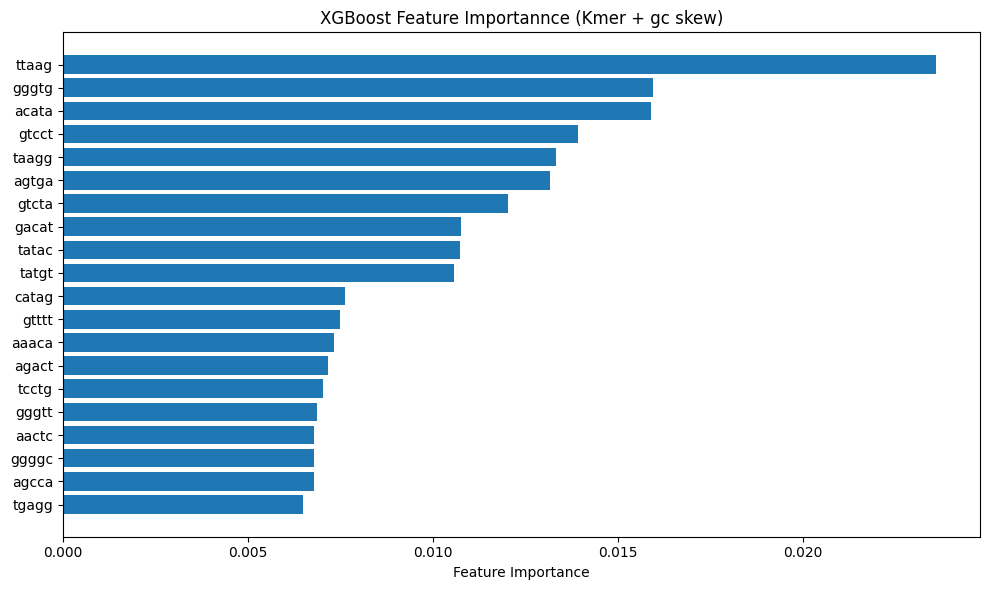

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split

# Prepare your data
# X = df.drop('target', axis=1)
# y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Train XGBoost model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)

# Get feature importances
importances = xgb.feature_importances_
feature_names = X.columns

# Create a DataFrame for ranking
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Show top 10 features
print(importance_df.head(10))

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:20][::-1], importance_df['Importance'][:20][::-1])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importannce (Kmer + gc skew)')
plt.tight_layout()
plt.show()

  Feature  Importance
0   tatac    0.006210
1   atagc    0.005844
2   ctgcg    0.005569
3   gtcct    0.005304
4   agact    0.004813
5   gacat    0.004812
6   aactc    0.004343
7   tgatc    0.004289
8   gggga    0.004285
9   gggtg    0.003982


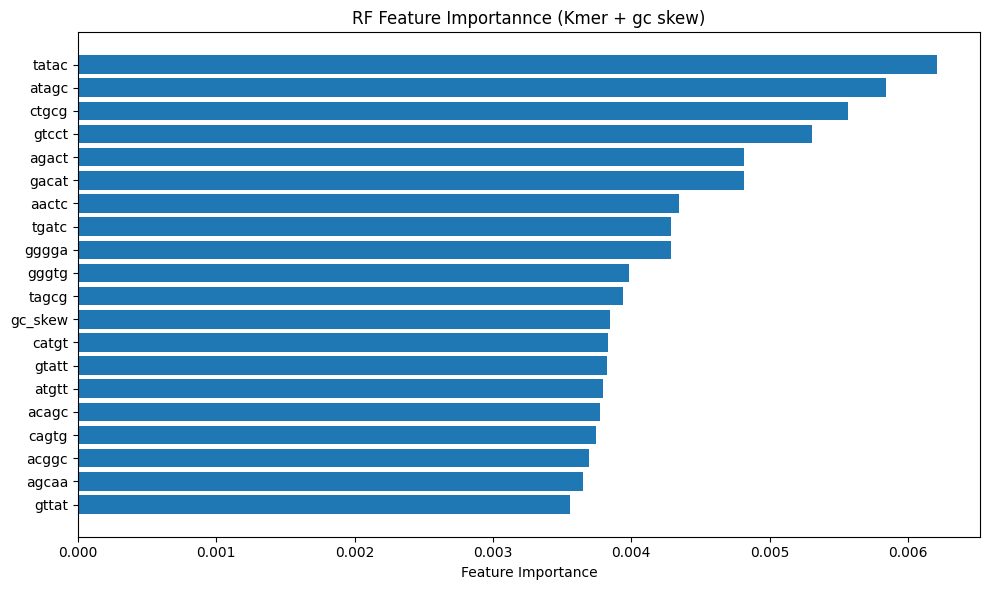

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split

# Prepare your data
# X = df.drop('target', axis=1)
# y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Train RF model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for ranking
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Show top 10 features
print(importance_df.head(10))

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:20][::-1], importance_df['Importance'][:20][::-1])
plt.xlabel('Feature Importance')
plt.title('RF Feature Importannce (Kmer + gc skew)')
plt.tight_layout()
plt.show()

### CD-HIT-EST clustering
 Solve Sequence-identity leakage

In [ ]:
!apt-get install cd-hit

In [ ]:
# import os
# import re
# import subprocess
# import numpy as np
# import pandas as pd

# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import StratifiedGroupKFold


# # ============================================================
# # 1. Input dataframe
# # ============================================================

# # Your dataframe should contain:
# # df["sequence"] = raw nucleotide sequence
# # df["genotype"] = genotype label

# sequence_col = "seq"
# label_col = "genotype"

# df = dataset.copy()
# # df = df.copy()
# df = df.reset_index(drop=True)

# # Optional: clean sequences
# df[sequence_col] = (
#     df[sequence_col]
#     .astype(str)
#     .str.upper()
#     .str.replace("U", "T", regex=False)
# )

# # Keep only valid A/C/G/T sequences
# valid_mask = df[sequence_col].str.fullmatch(r"[ACGT]+")
# df = df[valid_mask].reset_index(drop=True)

# print("Number of sequences after cleaning:", len(df))
# print(df[label_col].value_counts())


# # ============================================================
# # 2. Write sequences to FASTA
# # ============================================================

# fasta_path = "hcv_sequences_cleaned.fasta"

# with open(fasta_path, "w") as f:
#     for idx, seq in enumerate(df[sequence_col]):
#         f.write(f">seq_{idx}\n")
#         f.write(f"{seq}\n")

# print(f"FASTA file saved to: {fasta_path}")


# # ============================================================
# # 3. Run CD-HIT-EST clustering
# # ============================================================

# identity_threshold = 0.90

# cdhit_output = f"hcv_cdhit_{int(identity_threshold * 100)}"

# cmd = [
#     "cd-hit-est",
#     "-i", fasta_path,
#     "-o", cdhit_output,
#     "-c", str(identity_threshold),
#     "-n", "10",
#     "-M", "0",
#     "-T", "0"
# ]

# print("Running CD-HIT-EST...")
# print(" ".join(cmd))

# subprocess.run(cmd, check=True)

# print("CD-HIT-EST finished.")
# print(f"Cluster file: {cdhit_output}.clstr")


# # ============================================================
# # 4. Parse CD-HIT cluster file
# # ============================================================

# def parse_cdhit_clusters(clstr_file):
#     """
#     Parses CD-HIT .clstr file and returns:
#     sequence index -> cluster ID
#     """
#     seq_to_cluster = {}
#     current_cluster = None

#     with open(clstr_file, "r") as f:
#         for line in f:
#             line = line.strip()

#             if line.startswith(">Cluster"):
#                 current_cluster = int(line.split()[1])

#             else:
#                 match = re.search(r">seq_(\d+)\.\.\.", line)

#                 if match:
#                     seq_idx = int(match.group(1))
#                     seq_to_cluster[seq_idx] = current_cluster

#     return seq_to_cluster


# cluster_file = f"{cdhit_output}.clstr"
# seq_to_cluster = parse_cdhit_clusters(cluster_file)

# df["cluster_id"] = df.index.map(seq_to_cluster)

# # Safety check
# missing_clusters = df["cluster_id"].isna().sum()
# print("Missing cluster assignments:", missing_clusters)

# df = df.dropna(subset=["cluster_id"]).reset_index(drop=True)
# df["cluster_id"] = df["cluster_id"].astype(int)

# print("Number of clusters:", df["cluster_id"].nunique())
# print(df[["genotype", "cluster_id"]].head())


# # ============================================================
# # 5. Encode labels
# # ============================================================

# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(df[label_col].values)

# class_labels = np.unique(y_encoded)
# class_names = label_encoder.inverse_transform(class_labels)

# groups = df["cluster_id"].values


# # ============================================================
# # 6. Cluster-aware train-test split
# # ============================================================

# outer_splitter = StratifiedGroupKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

# train_idx, test_idx = next(
#     outer_splitter.split(
#         X=df[sequence_col].values,
#         y=y_encoded,
#         groups=groups
#     )
# )

# train_df = df.iloc[train_idx].reset_index(drop=True)
# test_df = df.iloc[test_idx].reset_index(drop=True)

# y_train = y_encoded[train_idx]
# y_test = y_encoded[test_idx]

# train_clusters = set(train_df["cluster_id"])
# test_clusters = set(test_df["cluster_id"])

# overlap = train_clusters.intersection(test_clusters)

# print("Number of training sequences:", len(train_df))
# print("Number of test sequences:", len(test_df))
# print("Number of overlapping clusters:", len(overlap))

# if len(overlap) == 0:
#     print("No sequence-identity leakage detected between train and test clusters.")
# else:
#     print("Warning: overlapping clusters found.")

# print("\nTraining class distribution:")
# print(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())

# print("\nTest class distribution:")
# print(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())





import re
import subprocess
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder


# ============================================================
# 1. Input dataframe
# ============================================================

# dataset should contain:
# - raw sequence column: "seq"
# - label column: "genotype"
# - encoded feature columns

df = dataset.copy()
df = df.reset_index(drop=True)

sequence_col = "seq"
label_col = "genotype"

identity_threshold = 0.90


# ============================================================
# 2. Safety checks
# ============================================================

if sequence_col not in df.columns:
    raise ValueError(f"Missing sequence column: {sequence_col}")

if label_col not in df.columns:
    raise ValueError(f"Missing label column: {label_col}")


# ============================================================
# 3. Clean sequences only for CD-HIT
#    The original dataframe features are not modified
# ============================================================

seq_clean = (
    df[sequence_col]
    .astype(str)
    .str.upper()
    .str.replace("U", "T", regex=False)
)

valid_mask = seq_clean.str.fullmatch(r"[ACGT]+")

df = df[valid_mask].reset_index(drop=True)
seq_clean = seq_clean[valid_mask].reset_index(drop=True)

print("Number of valid sequences:", len(df))
print("\nClass distribution:")
print(df[label_col].value_counts())


# ============================================================
# 4. Write sequences to FASTA for CD-HIT
# ============================================================

fasta_path = f"hcv_sequences_cleaned_{int(identity_threshold * 100)}.fasta"

with open(fasta_path, "w") as f:
    for idx, seq in enumerate(seq_clean):
        f.write(f">seq_{idx}\n")
        f.write(f"{seq}\n")

print(f"\nFASTA file saved to: {fasta_path}")


# ============================================================
# 5. Run CD-HIT-EST at 90% identity
# ============================================================

cdhit_output = f"hcv_cdhit_{int(identity_threshold * 100)}"

# Recommended word size for CD-HIT-EST
if identity_threshold >= 0.95:
    word_size = "10"
elif identity_threshold >= 0.90:
    word_size = "8"
else:
    word_size = "7"

cmd = [
    "cd-hit-est",
    "-i", fasta_path,
    "-o", cdhit_output,
    "-c", str(identity_threshold),
    "-n", word_size,
    "-M", "0",
    "-T", "0"
]

print("\nRunning CD-HIT-EST...")
print(" ".join(cmd))

subprocess.run(cmd, check=True)

print("\nCD-HIT-EST finished.")
print(f"Cluster file: {cdhit_output}.clstr")


# ============================================================
# 6. Parse CD-HIT cluster file
# ============================================================

def parse_cdhit_clusters(clstr_file):
    """
    Parses CD-HIT .clstr file.

    Returns:
        Dictionary mapping sequence index to cluster ID.
    """

    seq_to_cluster = {}
    current_cluster = None

    with open(clstr_file, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith(">Cluster"):
                current_cluster = int(line.split()[1])

            else:
                match = re.search(r">seq_(\d+)\.\.\.", line)

                if match:
                    seq_idx = int(match.group(1))
                    seq_to_cluster[seq_idx] = current_cluster

    return seq_to_cluster


cluster_file = f"{cdhit_output}.clstr"

seq_to_cluster = parse_cdhit_clusters(cluster_file)

df["cluster_id"] = df.index.map(seq_to_cluster)

missing_clusters = df["cluster_id"].isna().sum()
print("\nMissing cluster assignments:", missing_clusters)

if missing_clusters > 0:
    df = df.dropna(subset=["cluster_id"]).reset_index(drop=True)

df["cluster_id"] = df["cluster_id"].astype(int)

print("Number of CD-HIT clusters:", df["cluster_id"].nunique())


# ============================================================
# 7. Prepare X, y, and groups
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    df[label_col].values
)

class_labels = np.unique(y_encoded)

class_names = label_encoder.inverse_transform(
    class_labels
)

groups = df["cluster_id"].values


# ============================================================
# 8. Select encoded feature columns
#    Sequence column is excluded from X
# ============================================================

non_feature_cols = [
    label_col,
    "genotype",
    "genotype_encoded",
    "label",
    "target",
    "class",
    "cluster_id",
    sequence_col,
    "seq",
    "sequence",
    "accession",
    "id"
]

feature_cols = [
    col for col in df.columns
    if col not in non_feature_cols
]

X = df[feature_cols]

# Keep only numeric encoded features
X = X.select_dtypes(include=[np.number])

### check
print("Feature columns used:")
print(list(X.columns))

for suspicious_col in ["genotype", "genotype_encoded", "label", "target", "class", "cluster_id"]:
    if suspicious_col in X.columns:
        raise ValueError(f"Leakage detected: {suspicious_col} is included in X.")


if X.shape[1] == 0:
    raise ValueError(
        "No numeric encoded feature columns found. "
        "Please make sure dataset contains encoded numeric columns."
    )

print("\nNumber of encoded feature columns:", X.shape[1])


# ============================================================
# 9. Cluster-aware train-test split
# ============================================================

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X=X,
        y=y_encoded,
        groups=groups
    )
)


# ============================================================
# 10. Final outputs
# ============================================================

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)

y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]


# ============================================================
# 11. Safety check: no cluster overlap
# ============================================================

train_clusters = set(df.iloc[train_idx]["cluster_id"].values)
test_clusters = set(df.iloc[test_idx]["cluster_id"].values)

overlap = train_clusters.intersection(test_clusters)

print("\nCluster-aware split summary:")
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])
print("Training clusters:", len(train_clusters))
print("Test clusters:", len(test_clusters))
print("Overlapping clusters:", len(overlap))

if len(overlap) == 0:
    print("Correct: no CD-HIT cluster appears in both training and test sets.")
else:
    print("Warning: cluster overlap detected.")

print("\nTraining class distribution:")
print(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())

print("\nTest class distribution:")
print(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nClasses:")
for encoded_label, class_name in zip(class_labels, class_names):
    print(encoded_label, "=", class_name)

Number of valid sequences: 36464

Class distribution:
genotype
1a    8460
1b    7653
3a    7021
4     3765
6     3128
2b    1672
2a    1594
3b    1238
5     1164
2c     769
Name: count, dtype: int64

FASTA file saved to: hcv_sequences_cleaned_90.fasta

Running CD-HIT-EST...
cd-hit-est -i hcv_sequences_cleaned_90.fasta -o hcv_cdhit_90 -c 0.9 -n 8 -M 0 -T 0

CD-HIT-EST finished.
Cluster file: hcv_cdhit_90.clstr

Missing cluster assignments: 0
Number of CD-HIT clusters: 2266
Feature columns used:
['aaaaa', 'aaaac', 'aaaag', 'aaaat', 'aaaca', 'aaacc', 'aaacg', 'aaact', 'aaaga', 'aaagc', 'aaagg', 'aaagt', 'aaatc', 'aaatg', 'aaatt', 'aacaa', 'aacac', 'aacag', 'aacat', 'aacca', 'aaccc', 'aaccg', 'aacct', 'aacga', 'aacgc', 'aacgg', 'aacgt', 'aacta', 'aactc', 'aactg', 'aactt', 'aagaa', 'aagac', 'aagag', 'aagat', 'aagca', 'aagcc', 'aagcg', 'aagct', 'aagga', 'aaggc', 'aaggg', 'aaggt', 'aagta', 'aagtc', 'aagtg', 'aagtt', 'aatac', 'aatag', 'aatat', 'aatca', 'aatcc', 'aatct', 'aatga', 'aatgc', 'aatg

In [ ]:
X_train = X_train.values
X_test = X_test.values

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score
)

import xgboost as xgb
import numpy as np
import pandas as pd


# ============================================================
# 1. Full metrics function
# ============================================================

def calculate_full_metrics(
    y_test,
    y_pred,
    y_proba,
    class_labels,
    class_names
):
    accuracy = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=class_labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"True_{c}" for c in class_names],
        columns=[f"Pred_{c}" for c in class_names]
    )

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=class_labels,
        zero_division=0
    )

    specificity = []

    for i, cls in enumerate(class_labels):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificity.append(spec)

    auc_per_class = []

    if y_proba is not None:
        y_test_binarized = label_binarize(
            y_test,
            classes=class_labels
        )

        for i in range(len(class_labels)):
            try:
                auc_value = roc_auc_score(
                    y_test_binarized[:, i],
                    y_proba[:, i]
                )
            except ValueError:
                auc_value = np.nan

            auc_per_class.append(auc_value)
    else:
        auc_per_class = [np.nan] * len(class_labels)

    per_class_metrics = pd.DataFrame({
        "Class": class_names,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "AUC-ROC": auc_per_class,
        "Support": support
    })

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    macro_specificity = np.mean(specificity)

    weighted_specificity = np.average(
        specificity,
        weights=support
    )

    if y_proba is not None:
        y_test_binarized = label_binarize(
            y_test,
            classes=class_labels
        )

        try:
            macro_auc_roc = roc_auc_score(
                y_test_binarized,
                y_proba,
                average="macro",
                multi_class="ovr"
            )

            weighted_auc_roc = roc_auc_score(
                y_test_binarized,
                y_proba,
                average="weighted",
                multi_class="ovr"
            )
        except ValueError:
            macro_auc_roc = np.nan
            weighted_auc_roc = np.nan
    else:
        macro_auc_roc = np.nan
        weighted_auc_roc = np.nan

    summary_metrics = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall/Sensitivity",
            "Macro Specificity",
            "Macro F1-score",
            "Macro AUC-ROC",
            "Weighted Precision",
            "Weighted Recall/Sensitivity",
            "Weighted Specificity",
            "Weighted F1-score",
            "Weighted AUC-ROC",
            "Matthews Correlation Coefficient"
        ],
        "Value": [
            accuracy,
            macro_precision,
            macro_recall,
            macro_specificity,
            macro_f1,
            macro_auc_roc,
            weighted_precision,
            weighted_recall,
            weighted_specificity,
            weighted_f1,
            weighted_auc_roc,
            mcc
        ]
    })

    return summary_metrics, per_class_metrics, cm_df


# ============================================================
# 2. Define all models
# ============================================================

models = {
    "xgboost": xgb.XGBClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "knn": KNeighborsClassifier(
        n_neighbors=5
    ),

    "mlp": MLPClassifier(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=128,
        learning_rate="adaptive",
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
}


# ============================================================
# 3. Run all models
# ============================================================

all_summary_results = []

for model_name, clf in models.items():

    print("\n" + "=" * 70)
    print(f"Training model: {model_name}")
    print("=" * 70)

    # Models that need scaling
    if model_name in ["knn", "mlp"]:
        steps = [
            ("scaler", StandardScaler()),

            # Uncomment this if you want SMOTE
            ("smote", SMOTE(
                sampling_strategy="auto",
                random_state=42
            )),

            ("clf", clf)
        ]
    else:
        steps = [
            # Uncomment this if you want SMOTE
            ("smote", SMOTE(
                sampling_strategy="auto",
                random_state=42
            )),

            ("clf", clf)
        ]

    pipeline = Pipeline(steps)

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["clf"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)
    else:
        y_proba = None

    # Metrics
    summary_metrics, per_class_metrics, cm_df = calculate_full_metrics(
        y_test=y_test,
        y_pred=y_pred,
        y_proba=y_proba,
        class_labels=class_labels,
        class_names=class_names
    )

    # Add model name
    summary_metrics.insert(0, "Model", model_name)
    per_class_metrics.insert(0, "Model", model_name)

    # Save individual results
    summary_file = f"cdhit90_{model_name}_summary_metrics.csv"
    per_class_file = f"cdhit90_{model_name}_per_class_metrics.csv"
    cm_file = f"cdhit90_{model_name}_confusion_matrix.csv"

    summary_metrics.to_csv(summary_file, index=False)
    per_class_metrics.to_csv(per_class_file, index=False)
    cm_df.to_csv(cm_file)

    print("\nSummary metrics:")
    print(summary_metrics)

    print("\nPer-class metrics:")
    print(per_class_metrics)

    print("\nConfusion matrix:")
    print(cm_df)

    print("\nSaved files:")
    print(summary_file)
    print(per_class_file)
    print(cm_file)

    all_summary_results.append(summary_metrics)


# ============================================================
# 4. Combine all summary metrics into one table
# ============================================================

all_summary_results_df = pd.concat(
    all_summary_results,
    axis=0,
    ignore_index=True
)

all_summary_results_df.to_csv(
    "cdhit90_all_models_summary_metrics.csv",
    index=False
)

print("\n" + "=" * 70)
print("All models completed.")
print("=" * 70)

print("\nCombined summary metrics:")
print(all_summary_results_df)

print("\nSaved combined summary file:")
print("cdhit90_all_models_summary_metrics.csv")


Training model: xgboost

Summary metrics:
      Model                            Metric     Value
0   xgboost                          Accuracy  0.916156
1   xgboost                   Macro Precision  0.888773
2   xgboost          Macro Recall/Sensitivity  0.886623
3   xgboost                 Macro Specificity  0.988800
4   xgboost                    Macro F1-score  0.884628
5   xgboost                     Macro AUC-ROC  0.987428
6   xgboost                Weighted Precision  0.920485
7   xgboost       Weighted Recall/Sensitivity  0.916156
8   xgboost              Weighted Specificity  0.971848
9   xgboost                 Weighted F1-score  0.916555
10  xgboost                  Weighted AUC-ROC  0.986404
11  xgboost  Matthews Correlation Coefficient  0.882898

Per-class metrics:
     Model Class  Precision  Recall/Sensitivity  Specificity  F1-score  \
0  xgboost    1a   0.955238            0.899023     0.960123  0.926278   
1  xgboost    1b   0.797189            0.981054     0.963299 

In [ ]:
## onehot encoding only
#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.822281
# 1         xgboost                   Macro Precision  0.677538
# 2         xgboost          Macro Recall/Sensitivity  0.794010
# 3         xgboost                 Macro Specificity  0.979752
# 4         xgboost                    Macro F1-score  0.708900
# 5         xgboost                     Macro AUC-ROC  0.971126
# 6         xgboost                Weighted Precision  0.865853
# 7         xgboost       Weighted Recall/Sensitivity  0.822281
# 8         xgboost              Weighted Specificity  0.975239
# 9         xgboost                 Weighted F1-score  0.832679
# 10        xgboost                  Weighted AUC-ROC  0.964790
# 11        xgboost  Matthews Correlation Coefficient  0.765390
# 12  random_forest                          Accuracy  0.826927
# 13  random_forest                   Macro Precision  0.774191
# 14  random_forest          Macro Recall/Sensitivity  0.793303
# 15  random_forest                 Macro Specificity  0.980495
# 16  random_forest                    Macro F1-score  0.762408
# 17  random_forest                     Macro AUC-ROC  0.969805
# 18  random_forest                Weighted Precision  0.879892
# 19  random_forest       Weighted Recall/Sensitivity  0.826927
# 20  random_forest              Weighted Specificity  0.978021
# 21  random_forest                 Weighted F1-score  0.838871
# 22  random_forest                  Weighted AUC-ROC  0.962531
# 23  random_forest  Matthews Correlation Coefficient  0.773856
# 24            knn                          Accuracy  0.800422
# 25            knn                   Macro Precision  0.653527
# 26            knn          Macro Recall/Sensitivity  0.756821
# 27            knn                 Macro Specificity  0.976214
# 28            knn                    Macro F1-score  0.672728
# 29            knn                     Macro AUC-ROC  0.906808
# 30            knn                Weighted Precision  0.862173
# 31            knn       Weighted Recall/Sensitivity  0.800422
# 32            knn              Weighted Specificity  0.961713
# 33            knn                 Weighted F1-score  0.817455
# 34            knn                  Weighted AUC-ROC  0.906784
# 35            knn  Matthews Correlation Coefficient  0.736383
# 36            mlp                          Accuracy  0.806547
# 37            mlp                   Macro Precision  0.620047
# 38            mlp          Macro Recall/Sensitivity  0.767908
# 39            mlp                 Macro Specificity  0.977724
# 40            mlp                    Macro F1-score  0.664090
# 41            mlp                     Macro AUC-ROC  0.948893
# 42            mlp                Weighted Precision  0.851727
# 43            mlp       Weighted Recall/Sensitivity  0.806547
# 44            mlp              Weighted Specificity  0.970698
# 45            mlp                 Weighted F1-score  0.820615
# 46            mlp                  Weighted AUC-ROC  0.939607
# 47            mlp  Matthews Correlation Coefficient  0.743482

########################################################################

### onehot encoding + smote
#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.837170
# 1         xgboost                   Macro Precision  0.677746
# 2         xgboost          Macro Recall/Sensitivity  0.805158
# 3         xgboost                 Macro Specificity  0.981614
# 4         xgboost                    Macro F1-score  0.714824
# 5         xgboost                     Macro AUC-ROC  0.973894
# 6         xgboost                Weighted Precision  0.877440
# 7         xgboost       Weighted Recall/Sensitivity  0.837170
# 8         xgboost              Weighted Specificity  0.978972
# 9         xgboost                 Weighted F1-score  0.847113
# 10        xgboost                  Weighted AUC-ROC  0.967765
# 11        xgboost  Matthews Correlation Coefficient  0.785365
# 12  random_forest                          Accuracy  0.826188
# 13  random_forest                   Macro Precision  0.755773
# 14  random_forest          Macro Recall/Sensitivity  0.797245
# 15  random_forest                 Macro Specificity  0.980403
# 16  random_forest                    Macro F1-score  0.760364
# 17  random_forest                     Macro AUC-ROC  0.970320
# 18  random_forest                Weighted Precision  0.871887
# 19  random_forest       Weighted Recall/Sensitivity  0.826188
# 20  random_forest              Weighted Specificity  0.977844
# 21  random_forest                 Weighted F1-score  0.836196
# 22  random_forest                  Weighted AUC-ROC  0.967033
# 23  random_forest  Matthews Correlation Coefficient  0.771672
# 24            knn                          Accuracy  0.800422
# 25            knn                   Macro Precision  0.653527
# 26            knn          Macro Recall/Sensitivity  0.756821
# 27            knn                 Macro Specificity  0.976214
# 28            knn                    Macro F1-score  0.672728
# 29            knn                     Macro AUC-ROC  0.906808
# 30            knn                Weighted Precision  0.862173
# 31            knn       Weighted Recall/Sensitivity  0.800422
# 32            knn              Weighted Specificity  0.961713
# 33            knn                 Weighted F1-score  0.817455
# 34            knn                  Weighted AUC-ROC  0.906784
# 35            knn  Matthews Correlation Coefficient  0.736383
# 36            mlp                          Accuracy  0.806547
# 37            mlp                   Macro Precision  0.620047
# 38            mlp          Macro Recall/Sensitivity  0.767908
# 39            mlp                 Macro Specificity  0.977724
# 40            mlp                    Macro F1-score  0.664090
# 41            mlp                     Macro AUC-ROC  0.948893
# 42            mlp                Weighted Precision  0.851727
# 43            mlp       Weighted Recall/Sensitivity  0.806547
# 44            mlp              Weighted Specificity  0.970698
# 45            mlp                 Weighted F1-score  0.820615
# 46            mlp                  Weighted AUC-ROC  0.939607
# 47            mlp  Matthews Correlation Coefficient  0.743482

########################################################################
## onehot encoding + gc skew + smote

#            Model                            Metric     Value
# 0         xgboost                          Accuracy  0.807920
# 1         xgboost                   Macro Precision  0.673051
# 2         xgboost          Macro Recall/Sensitivity  0.782930
# 3         xgboost                 Macro Specificity  0.978147
# 4         xgboost                    Macro F1-score  0.702038
# 5         xgboost                     Macro AUC-ROC  0.971163
# 6         xgboost                Weighted Precision  0.856562
# 7         xgboost       Weighted Recall/Sensitivity  0.807920
# 8         xgboost              Weighted Specificity  0.973546
# 9         xgboost                 Weighted F1-score  0.818541
# 10        xgboost                  Weighted AUC-ROC  0.965236
# 11        xgboost  Matthews Correlation Coefficient  0.747134
# 12  random_forest                          Accuracy  0.817740
# 13  random_forest                   Macro Precision  0.797039
# 14  random_forest          Macro Recall/Sensitivity  0.781657
# 15  random_forest                 Macro Specificity  0.979512
# 16  random_forest                    Macro F1-score  0.774538
# 17  random_forest                     Macro AUC-ROC  0.968626
# 18  random_forest                Weighted Precision  0.873413
# 19  random_forest       Weighted Recall/Sensitivity  0.817740
# 20  random_forest              Weighted Specificity  0.977377
# 21  random_forest                 Weighted F1-score  0.830647
# 22  random_forest                  Weighted AUC-ROC  0.960912
# 23  random_forest  Matthews Correlation Coefficient  0.761937
# 24            knn                          Accuracy  0.800106
# 25            knn                   Macro Precision  0.653777
# 26            knn          Macro Recall/Sensitivity  0.756858
# 27            knn                 Macro Specificity  0.976134
# 28            knn                    Macro F1-score  0.673116
# 29            knn                     Macro AUC-ROC  0.908382
# 30            knn                Weighted Precision  0.861503
# 31            knn       Weighted Recall/Sensitivity  0.800106
# 32            knn              Weighted Specificity  0.961230
# 33            knn                 Weighted F1-score  0.816931
# 34            knn                  Weighted AUC-ROC  0.908765
# 35            knn  Matthews Correlation Coefficient  0.735943
# 36            mlp                          Accuracy  0.812672
# 37            mlp                   Macro Precision  0.591396
# 38            mlp          Macro Recall/Sensitivity  0.785071
# 39            mlp                 Macro Specificity  0.978878
# 40            mlp                    Macro F1-score  0.649038
# 41            mlp                     Macro AUC-ROC  0.949569
# 42            mlp                Weighted Precision  0.863391
# 43            mlp       Weighted Recall/Sensitivity  0.812672
# 44            mlp              Weighted Specificity  0.976107
# 45            mlp                 Weighted F1-score  0.826471
# 46            mlp                  Weighted AUC-ROC  0.946362
# 47            mlp  Matthews Correlation Coefficient  0.754645

# ##############################################################################
## onehot encoding + gc_content + smote

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.816262
# 1         xgboost                   Macro Precision  0.628821
# 2         xgboost          Macro Recall/Sensitivity  0.787044
# 3         xgboost                 Macro Specificity  0.979264
# 4         xgboost                    Macro F1-score  0.668449
# 5         xgboost                     Macro AUC-ROC  0.968778
# 6         xgboost                Weighted Precision  0.868402
# 7         xgboost       Weighted Recall/Sensitivity  0.816262
# 8         xgboost              Weighted Specificity  0.976375
# 9         xgboost                 Weighted F1-score  0.828717
# 10        xgboost                  Weighted AUC-ROC  0.963477
# 11        xgboost  Matthews Correlation Coefficient  0.758118
# 12  random_forest                          Accuracy  0.821119
# 13  random_forest                   Macro Precision  0.770390
# 14  random_forest          Macro Recall/Sensitivity  0.785087
# 15  random_forest                 Macro Specificity  0.979996
# 16  random_forest                    Macro F1-score  0.752058
# 17  random_forest                     Macro AUC-ROC  0.967032
# 18  random_forest                Weighted Precision  0.879977
# 19  random_forest       Weighted Recall/Sensitivity  0.821119
# 20  random_forest              Weighted Specificity  0.978840
# 21  random_forest                 Weighted F1-score  0.835109
# 22  random_forest                  Weighted AUC-ROC  0.964362
# 23  random_forest  Matthews Correlation Coefficient  0.766792
# 24            knn                          Accuracy  0.801795
# 25            knn                   Macro Precision  0.657209
# 26            knn          Macro Recall/Sensitivity  0.757748
# 27            knn                 Macro Specificity  0.976300
# 28            knn                    Macro F1-score  0.675704
# 29            knn                     Macro AUC-ROC  0.907904
# 30            knn                Weighted Precision  0.862374
# 31            knn       Weighted Recall/Sensitivity  0.801795
# 32            knn              Weighted Specificity  0.961204
# 33            knn                 Weighted F1-score  0.818386
# 34            knn                  Weighted AUC-ROC  0.908266
# 35            knn  Matthews Correlation Coefficient  0.737979
# 36            mlp                          Accuracy  0.815100
# 37            mlp                   Macro Precision  0.606272
# 38            mlp          Macro Recall/Sensitivity  0.786007
# 39            mlp                 Macro Specificity  0.979058
# 40            mlp                    Macro F1-score  0.659957
# 41            mlp                     Macro AUC-ROC  0.951250
# 42            mlp                Weighted Precision  0.862251
# 43            mlp       Weighted Recall/Sensitivity  0.815100
# 44            mlp              Weighted Specificity  0.975484
# 45            mlp                 Weighted F1-score  0.828422
# 46            mlp                  Weighted AUC-ROC  0.942030
# 47            mlp  Matthews Correlation Coefficient  0.756560

# ##############################################################################
## onehot encoding + gc skew + gc_content + smote

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.803168
# 1         xgboost                   Macro Precision  0.631472
# 2         xgboost          Macro Recall/Sensitivity  0.770796
# 3         xgboost                 Macro Specificity  0.977765
# 4         xgboost                    Macro F1-score  0.665310
# 5         xgboost                     Macro AUC-ROC  0.970614
# 6         xgboost                Weighted Precision  0.859697
# 7         xgboost       Weighted Recall/Sensitivity  0.803168
# 8         xgboost              Weighted Specificity  0.974486
# 9         xgboost                 Weighted F1-score  0.815677
# 10        xgboost                  Weighted AUC-ROC  0.970262
# 11        xgboost  Matthews Correlation Coefficient  0.741606
# 12  random_forest                          Accuracy  0.823970
# 13  random_forest                   Macro Precision  0.788989
# 14  random_forest          Macro Recall/Sensitivity  0.789087
# 15  random_forest                 Macro Specificity  0.980120
# 16  random_forest                    Macro F1-score  0.774886
# 17  random_forest                     Macro AUC-ROC  0.970486
# 18  random_forest                Weighted Precision  0.876183
# 19  random_forest       Weighted Recall/Sensitivity  0.823970
# 20  random_forest              Weighted Specificity  0.977225
# 21  random_forest                 Weighted F1-score  0.835647
# 22  random_forest                  Weighted AUC-ROC  0.963558
# 23  random_forest  Matthews Correlation Coefficient  0.769795
# 24            knn                          Accuracy  0.802429
# 25            knn                   Macro Precision  0.657208
# 26            knn          Macro Recall/Sensitivity  0.758587
# 27            knn                 Macro Specificity  0.976366
# 28            knn                    Macro F1-score  0.675761
# 29            knn                     Macro AUC-ROC  0.911755
# 30            knn                Weighted Precision  0.862924
# 31            knn       Weighted Recall/Sensitivity  0.802429
# 32            knn              Weighted Specificity  0.961236
# 33            knn                 Weighted F1-score  0.818824
# 34            knn                  Weighted AUC-ROC  0.910332
# 35            knn  Matthews Correlation Coefficient  0.739016
# 36            mlp                          Accuracy  0.809081
# 37            mlp                   Macro Precision  0.592622
# 38            mlp          Macro Recall/Sensitivity  0.769785
# 39            mlp                 Macro Specificity  0.978309
# 40            mlp                    Macro F1-score  0.645530
# 41            mlp                     Macro AUC-ROC  0.949450
# 42            mlp                Weighted Precision  0.854308
# 43            mlp       Weighted Recall/Sensitivity  0.809081
# 44            mlp              Weighted Specificity  0.974005
# 45            mlp                 Weighted F1-score  0.822488
# 46            mlp                  Weighted AUC-ROC  0.948271
# 47            mlp  Matthews Correlation Coefficient  0.747477

In [ ]:
### fcgr only

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.918057
# 1         xgboost                   Macro Precision  0.864669
# 2         xgboost          Macro Recall/Sensitivity  0.867919
# 3         xgboost                 Macro Specificity  0.989000
# 4         xgboost                    Macro F1-score  0.859445
# 5         xgboost                     Macro AUC-ROC  0.988614
# 6         xgboost                Weighted Precision  0.922503
# 7         xgboost       Weighted Recall/Sensitivity  0.918057
# 8         xgboost              Weighted Specificity  0.971945
# 9         xgboost                 Weighted F1-score  0.918351
# 10        xgboost                  Weighted AUC-ROC  0.986821
# 11        xgboost  Matthews Correlation Coefficient  0.885332
# 12  random_forest                          Accuracy  0.869377
# 13  random_forest                   Macro Precision  0.896454
# 14  random_forest          Macro Recall/Sensitivity  0.809248
# 15  random_forest                 Macro Specificity  0.983345
# 16  random_forest                    Macro F1-score  0.832130
# 17  random_forest                     Macro AUC-ROC  0.989553
# 18  random_forest                Weighted Precision  0.899030
# 19  random_forest       Weighted Recall/Sensitivity  0.869377
# 20  random_forest              Weighted Specificity  0.964077
# 21  random_forest                 Weighted F1-score  0.874934
# 22  random_forest                  Weighted AUC-ROC  0.982170
# 23  random_forest  Matthews Correlation Coefficient  0.824425
# 24            knn                          Accuracy  0.926610
# 25            knn                   Macro Precision  0.863124
# 26            knn          Macro Recall/Sensitivity  0.897183
# 27            knn                 Macro Specificity  0.989967
# 28            knn                    Macro F1-score  0.870519
# 29            knn                     Macro AUC-ROC  0.973817
# 30            knn                Weighted Precision  0.933356
# 31            knn       Weighted Recall/Sensitivity  0.926610
# 32            knn              Weighted Specificity  0.973061
# 33            knn                 Weighted F1-score  0.927701
# 34            knn                  Weighted AUC-ROC  0.976729
# 35            knn  Matthews Correlation Coefficient  0.896331
# 36            mlp                          Accuracy  0.886378
# 37            mlp                   Macro Precision  0.806335
# 38            mlp          Macro Recall/Sensitivity  0.906827
# 39            mlp                 Macro Specificity  0.985089
# 40            mlp                    Macro F1-score  0.845900
# 41            mlp                     Macro AUC-ROC  0.984720
# 42            mlp                Weighted Precision  0.898331
# 43            mlp       Weighted Recall/Sensitivity  0.886378
# 44            mlp              Weighted Specificity  0.964508
# 45            mlp                 Weighted F1-score  0.888856
# 46            mlp                  Weighted AUC-ROC  0.976273
# 47            mlp  Matthews Correlation Coefficient  0.843796

# ##############################################################################
## fcgr + smote

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.908659
# 1         xgboost                   Macro Precision  0.917214
# 2         xgboost          Macro Recall/Sensitivity  0.854459
# 3         xgboost                 Macro Specificity  0.987954
# 4         xgboost                    Macro F1-score  0.868923
# 5         xgboost                     Macro AUC-ROC  0.986678
# 6         xgboost                Weighted Precision  0.914909
# 7         xgboost       Weighted Recall/Sensitivity  0.908659
# 8         xgboost              Weighted Specificity  0.970876
# 9         xgboost                 Weighted F1-score  0.909309
# 10        xgboost                  Weighted AUC-ROC  0.986216
# 11        xgboost  Matthews Correlation Coefficient  0.873103
# 12  random_forest                          Accuracy  0.883527
# 13  random_forest                   Macro Precision  0.891934
# 14  random_forest          Macro Recall/Sensitivity  0.841788
# 15  random_forest                 Macro Specificity  0.985063
# 16  random_forest                    Macro F1-score  0.852991
# 17  random_forest                     Macro AUC-ROC  0.989503
# 18  random_forest                Weighted Precision  0.903267
# 19  random_forest       Weighted Recall/Sensitivity  0.883527
# 20  random_forest              Weighted Specificity  0.967103
# 21  random_forest                 Weighted F1-score  0.887205
# 22  random_forest                  Weighted AUC-ROC  0.981703
# 23  random_forest  Matthews Correlation Coefficient  0.842172
# 24            knn                          Accuracy  0.947202
# 25            knn                   Macro Precision  0.794312
# 26            knn          Macro Recall/Sensitivity  0.941030
# 27            knn                 Macro Specificity  0.993459
# 28            knn                    Macro F1-score  0.845202
# 29            knn                     Macro AUC-ROC  0.976963
# 30            knn                Weighted Precision  0.954440
# 31            knn       Weighted Recall/Sensitivity  0.947202
# 32            knn              Weighted Specificity  0.987391
# 33            knn                 Weighted F1-score  0.949252
# 34            knn                  Weighted AUC-ROC  0.983377
# 35            knn  Matthews Correlation Coefficient  0.925603
# 36            mlp                          Accuracy  0.885428
# 37            mlp                   Macro Precision  0.805980
# 38            mlp          Macro Recall/Sensitivity  0.912383
# 39            mlp                 Macro Specificity  0.985132
# 40            mlp                    Macro F1-score  0.847952
# 41            mlp                     Macro AUC-ROC  0.985513
# 42            mlp                Weighted Precision  0.899631
# 43            mlp       Weighted Recall/Sensitivity  0.885428
# 44            mlp              Weighted Specificity  0.965896
# 45            mlp                 Weighted F1-score  0.889007
# 46            mlp                  Weighted AUC-ROC  0.975051
# 47            mlp  Matthews Correlation Coefficient  0.842861

# ##############################################################################
## fcgr + gc skew + smote

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.908342
# 1         xgboost                   Macro Precision  0.873238
# 2         xgboost          Macro Recall/Sensitivity  0.858175
# 3         xgboost                 Macro Specificity  0.987923
# 4         xgboost                    Macro F1-score  0.858053
# 5         xgboost                     Macro AUC-ROC  0.986379
# 6         xgboost                Weighted Precision  0.914702
# 7         xgboost       Weighted Recall/Sensitivity  0.908342
# 8         xgboost              Weighted Specificity  0.970890
# 9         xgboost                 Weighted F1-score  0.909026
# 10        xgboost                  Weighted AUC-ROC  0.986729
# 11        xgboost  Matthews Correlation Coefficient  0.872906
# 12  random_forest                          Accuracy  0.890707
# 13  random_forest                   Macro Precision  0.892749
# 14  random_forest          Macro Recall/Sensitivity  0.835741
# 15  random_forest                 Macro Specificity  0.986032
# 16  random_forest                    Macro F1-score  0.851156
# 17  random_forest                     Macro AUC-ROC  0.989537
# 18  random_forest                Weighted Precision  0.911357
# 19  random_forest       Weighted Recall/Sensitivity  0.890707
# 20  random_forest              Weighted Specificity  0.969610
# 21  random_forest                 Weighted F1-score  0.894675
# 22  random_forest                  Weighted AUC-ROC  0.981726
# 23  random_forest  Matthews Correlation Coefficient  0.851981
# 24            knn                          Accuracy  0.947624
# 25            knn                   Macro Precision  0.798701
# 26            knn          Macro Recall/Sensitivity  0.943044
# 27            knn                 Macro Specificity  0.993515
# 28            knn                    Macro F1-score  0.847849
# 29            knn                     Macro AUC-ROC  0.977011
# 30            knn                Weighted Precision  0.954684
# 31            knn       Weighted Recall/Sensitivity  0.947624
# 32            knn              Weighted Specificity  0.987527
# 33            knn                 Weighted F1-score  0.949599
# 34            knn                  Weighted AUC-ROC  0.983465
# 35            knn  Matthews Correlation Coefficient  0.926192
# 36            mlp                          Accuracy  0.882893
# 37            mlp                   Macro Precision  0.818691
# 38            mlp          Macro Recall/Sensitivity  0.906602
# 39            mlp                 Macro Specificity  0.985051
# 40            mlp                    Macro F1-score  0.854147
# 41            mlp                     Macro AUC-ROC  0.986827
# 42            mlp                Weighted Precision  0.899955
# 43            mlp       Weighted Recall/Sensitivity  0.882893
# 44            mlp              Weighted Specificity  0.967621
# 45            mlp                 Weighted F1-score  0.886840
# 46            mlp                  Weighted AUC-ROC  0.980355
# 47            mlp  Matthews Correlation Coefficient  0.840834

# ##############################################################################
## fcgr + gc content + smote


#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.899598
# 1         xgboost                   Macro Precision  0.864166
# 2         xgboost          Macro Recall/Sensitivity  0.873237
# 3         xgboost                 Macro Specificity  0.986983
# 4         xgboost                    Macro F1-score  0.865631
# 5         xgboost                     Macro AUC-ROC  0.986156
# 6         xgboost                Weighted Precision  0.906425
# 7         xgboost       Weighted Recall/Sensitivity  0.899598
# 8         xgboost              Weighted Specificity  0.970232
# 9         xgboost                 Weighted F1-score  0.900257
# 10        xgboost                  Weighted AUC-ROC  0.986041
# 11        xgboost  Matthews Correlation Coefficient  0.863864
# 12  random_forest                          Accuracy  0.886147
# 13  random_forest                   Macro Precision  0.884323
# 14  random_forest          Macro Recall/Sensitivity  0.846185
# 15  random_forest                 Macro Specificity  0.985698
# 16  random_forest                    Macro F1-score  0.854604
# 17  random_forest                     Macro AUC-ROC  0.988304
# 18  random_forest                Weighted Precision  0.907654
# 19  random_forest       Weighted Recall/Sensitivity  0.886147
# 20  random_forest              Weighted Specificity  0.970838
# 21  random_forest                 Weighted F1-score  0.889912
# 22  random_forest                  Weighted AUC-ROC  0.982684
# 23  random_forest  Matthews Correlation Coefficient  0.849515
# 24            knn                          Accuracy  0.950434
# 25            knn                   Macro Precision  0.775829
# 26            knn          Macro Recall/Sensitivity  0.939162
# 27            knn                 Macro Specificity  0.994081
# 28            knn                    Macro F1-score  0.825107
# 29            knn                     Macro AUC-ROC  0.975892
# 30            knn                Weighted Precision  0.959458
# 31            knn       Weighted Recall/Sensitivity  0.950434
# 32            knn              Weighted Specificity  0.990375
# 33            knn                 Weighted F1-score  0.953252
# 34            knn                  Weighted AUC-ROC  0.982128
# 35            knn  Matthews Correlation Coefficient  0.931425
# 36            mlp                          Accuracy  0.883182
# 37            mlp                   Macro Precision  0.813046
# 38            mlp          Macro Recall/Sensitivity  0.903342
# 39            mlp                 Macro Specificity  0.984912
# 40            mlp                    Macro F1-score  0.850670
# 41            mlp                     Macro AUC-ROC  0.988362
# 42            mlp                Weighted Precision  0.896134
# 43            mlp       Weighted Recall/Sensitivity  0.883182
# 44            mlp              Weighted Specificity  0.965939
# 45            mlp                 Weighted F1-score  0.886178
# 46            mlp                  Weighted AUC-ROC  0.981823
# 47            mlp  Matthews Correlation Coefficient  0.842698

# ##############################################################################
## fcgr + gc skew + gc content + smote

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.914995
# 1         xgboost                   Macro Precision  0.874116
# 2         xgboost          Macro Recall/Sensitivity  0.879130
# 3         xgboost                 Macro Specificity  0.988659
# 4         xgboost                    Macro F1-score  0.873831
# 5         xgboost                     Macro AUC-ROC  0.984439
# 6         xgboost                Weighted Precision  0.919687
# 7         xgboost       Weighted Recall/Sensitivity  0.914995
# 8         xgboost              Weighted Specificity  0.971596
# 9         xgboost                 Weighted F1-score  0.915379
# 10        xgboost                  Weighted AUC-ROC  0.985162
# 11        xgboost  Matthews Correlation Coefficient  0.881499
# 12  random_forest                          Accuracy  0.886800
# 13  random_forest                   Macro Precision  0.894781
# 14  random_forest          Macro Recall/Sensitivity  0.841357
# 15  random_forest                 Macro Specificity  0.985720
# 16  random_forest                    Macro F1-score  0.853756
# 17  random_forest                     Macro AUC-ROC  0.988902
# 18  random_forest                Weighted Precision  0.907276
# 19  random_forest       Weighted Recall/Sensitivity  0.886800
# 20  random_forest              Weighted Specificity  0.970396
# 21  random_forest                 Weighted F1-score  0.890624
# 22  random_forest                  Weighted AUC-ROC  0.982823
# 23  random_forest  Matthews Correlation Coefficient  0.847322
# 24            knn                          Accuracy  0.945618
# 25            knn                   Macro Precision  0.783775
# 26            knn          Macro Recall/Sensitivity  0.942473
# 27            knn                 Macro Specificity  0.993592
# 28            knn                    Macro F1-score  0.831745
# 29            knn                     Macro AUC-ROC  0.976466
# 30            knn                Weighted Precision  0.957993
# 31            knn       Weighted Recall/Sensitivity  0.945618
# 32            knn              Weighted Specificity  0.990304
# 33            knn                 Weighted F1-score  0.949741
# 34            knn                  Weighted AUC-ROC  0.982798
# 35            knn  Matthews Correlation Coefficient  0.923819
# 36            mlp                          Accuracy  0.886906
# 37            mlp                   Macro Precision  0.801376
# 38            mlp          Macro Recall/Sensitivity  0.884129
# 39            mlp                 Macro Specificity  0.985239
# 40            mlp                    Macro F1-score  0.834020
# 41            mlp                     Macro AUC-ROC  0.984359
# 42            mlp                Weighted Precision  0.897516
# 43            mlp       Weighted Recall/Sensitivity  0.886906
# 44            mlp              Weighted Specificity  0.965485
# 45            mlp                 Weighted F1-score  0.889098
# 46            mlp                  Weighted AUC-ROC  0.975293
# 47            mlp  Matthews Correlation Coefficient  0.844278

In [ ]:
### kmer only

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.912355
# 1         xgboost                   Macro Precision  0.868894
# 2         xgboost          Macro Recall/Sensitivity  0.873444
# 3         xgboost                 Macro Specificity  0.988409
# 4         xgboost                    Macro F1-score  0.865274
# 5         xgboost                     Macro AUC-ROC  0.988516
# 6         xgboost                Weighted Precision  0.917782
# 7         xgboost       Weighted Recall/Sensitivity  0.912355
# 8         xgboost              Weighted Specificity  0.971735
# 9         xgboost                 Weighted F1-score  0.913251
# 10        xgboost                  Weighted AUC-ROC  0.987111
# 11        xgboost  Matthews Correlation Coefficient  0.877896
# 12  random_forest                          Accuracy  0.869377
# 13  random_forest                   Macro Precision  0.902245
# 14  random_forest          Macro Recall/Sensitivity  0.811962
# 15  random_forest                 Macro Specificity  0.983464
# 16  random_forest                    Macro F1-score  0.835710
# 17  random_forest                     Macro AUC-ROC  0.987649
# 18  random_forest                Weighted Precision  0.902592
# 19  random_forest       Weighted Recall/Sensitivity  0.869377
# 20  random_forest              Weighted Specificity  0.965260
# 21  random_forest                 Weighted F1-score  0.875840
# 22  random_forest                  Weighted AUC-ROC  0.981363
# 23  random_forest  Matthews Correlation Coefficient  0.826418
# 24            knn                          Accuracy  0.928617
# 25            knn                   Macro Precision  0.842779
# 26            knn          Macro Recall/Sensitivity  0.894350
# 27            knn                 Macro Specificity  0.990423
# 28            knn                    Macro F1-score  0.853573
# 29            knn                     Macro AUC-ROC  0.968601
# 30            knn                Weighted Precision  0.935949
# 31            knn       Weighted Recall/Sensitivity  0.928617
# 32            knn              Weighted Specificity  0.975614
# 33            knn                 Weighted F1-score  0.930050
# 34            knn                  Weighted AUC-ROC  0.978207
# 35            knn  Matthews Correlation Coefficient  0.899365
# 36            mlp                          Accuracy  0.904541
# 37            mlp                   Macro Precision  0.858818
# 38            mlp          Macro Recall/Sensitivity  0.877421
# 39            mlp                 Macro Specificity  0.986991
# 40            mlp                    Macro F1-score  0.862344
# 41            mlp                     Macro AUC-ROC  0.985901
# 42            mlp                Weighted Precision  0.909956
# 43            mlp       Weighted Recall/Sensitivity  0.904541
# 44            mlp              Weighted Specificity  0.965369
# 45            mlp                 Weighted F1-score  0.905531
# 46            mlp                  Weighted AUC-ROC  0.980821
# 47            mlp  Matthews Correlation Coefficient  0.866296

########################################################################
## kmer + smote
#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.922386
# 1         xgboost                   Macro Precision  0.865997
# 2         xgboost          Macro Recall/Sensitivity  0.924632
# 3         xgboost                 Macro Specificity  0.990012
# 4         xgboost                    Macro F1-score  0.890206
# 5         xgboost                     Macro AUC-ROC  0.990861
# 6         xgboost                Weighted Precision  0.929186
# 7         xgboost       Weighted Recall/Sensitivity  0.922386
# 8         xgboost              Weighted Specificity  0.977730
# 9         xgboost                 Weighted F1-score  0.923606
# 10        xgboost                  Weighted AUC-ROC  0.990578
# 11        xgboost  Matthews Correlation Coefficient  0.892523
# 12  random_forest                          Accuracy  0.888173
# 13  random_forest                   Macro Precision  0.894417
# 14  random_forest          Macro Recall/Sensitivity  0.882255
# 15  random_forest                 Macro Specificity  0.986181
# 16  random_forest                    Macro F1-score  0.881003
# 17  random_forest                     Macro AUC-ROC  0.991192
# 18  random_forest                Weighted Precision  0.910468
# 19  random_forest       Weighted Recall/Sensitivity  0.888173
# 20  random_forest              Weighted Specificity  0.973633
# 21  random_forest                 Weighted F1-score  0.892392
# 22  random_forest                  Weighted AUC-ROC  0.984240
# 23  random_forest  Matthews Correlation Coefficient  0.850184
# 24            knn                          Accuracy  0.943928
# 25            knn                   Macro Precision  0.785948
# 26            knn          Macro Recall/Sensitivity  0.939118
# 27            knn                 Macro Specificity  0.993168
# 28            knn                    Macro F1-score  0.834443
# 29            knn                     Macro AUC-ROC  0.976956
# 30            knn                Weighted Precision  0.954027
# 31            knn       Weighted Recall/Sensitivity  0.943928
# 32            knn              Weighted Specificity  0.987747
# 33            knn                 Weighted F1-score  0.947124
# 34            knn                  Weighted AUC-ROC  0.983468
# 35            knn  Matthews Correlation Coefficient  0.921167
# 36            mlp                          Accuracy  0.893347
# 37            mlp                   Macro Precision  0.831137
# 38            mlp          Macro Recall/Sensitivity  0.901292
# 39            mlp                 Macro Specificity  0.986117
# 40            mlp                    Macro F1-score  0.859861
# 41            mlp                     Macro AUC-ROC  0.986918
# 42            mlp                Weighted Precision  0.904023
# 43            mlp       Weighted Recall/Sensitivity  0.893347
# 44            mlp              Weighted Specificity  0.967824
# 45            mlp                 Weighted F1-score  0.895569
# 46            mlp                  Weighted AUC-ROC  0.977672
# 47            mlp  Matthews Correlation Coefficient  0.853381

########################################################################
## kmer + gc skew + smote


#            Model                            Metric     Value
# 0         xgboost                          Accuracy  0.912249
# 1         xgboost                   Macro Precision  0.882879
# 2         xgboost          Macro Recall/Sensitivity  0.871719
# 3         xgboost                 Macro Specificity  0.988373
# 4         xgboost                    Macro F1-score  0.872198
# 5         xgboost                     Macro AUC-ROC  0.988498
# 6         xgboost                Weighted Precision  0.917684
# 7         xgboost       Weighted Recall/Sensitivity  0.912249
# 8         xgboost              Weighted Specificity  0.971479
# 9         xgboost                 Weighted F1-score  0.912725
# 10        xgboost                  Weighted AUC-ROC  0.987577
# 11        xgboost  Matthews Correlation Coefficient  0.877918
# 12  random_forest                          Accuracy  0.887328
# 13  random_forest                   Macro Precision  0.897554
# 14  random_forest          Macro Recall/Sensitivity  0.853106
# 15  random_forest                 Macro Specificity  0.985804
# 16  random_forest                    Macro F1-score  0.863828
# 17  random_forest                     Macro AUC-ROC  0.987043
# 18  random_forest                Weighted Precision  0.907286
# 19  random_forest       Weighted Recall/Sensitivity  0.887328
# 20  random_forest              Weighted Specificity  0.970715
# 21  random_forest                 Weighted F1-score  0.891017
# 22  random_forest                  Weighted AUC-ROC  0.981885
# 23  random_forest  Matthews Correlation Coefficient  0.848155
# 24            knn                          Accuracy  0.946463
# 25            knn                   Macro Precision  0.796245
# 26            knn          Macro Recall/Sensitivity  0.941906
# 27            knn                 Macro Specificity  0.993301
# 28            knn                    Macro F1-score  0.846283
# 29            knn                     Macro AUC-ROC  0.976763
# 30            knn                Weighted Precision  0.953671
# 31            knn       Weighted Recall/Sensitivity  0.946463
# 32            knn              Weighted Specificity  0.986546
# 33            knn                 Weighted F1-score  0.948514
# 34            knn                  Weighted AUC-ROC  0.982778
# 35            knn  Matthews Correlation Coefficient  0.924461
# 36            mlp                          Accuracy  0.885005
# 37            mlp                   Macro Precision  0.856905
# 38            mlp          Macro Recall/Sensitivity  0.866999
# 39            mlp                 Macro Specificity  0.985051
# 40            mlp                    Macro F1-score  0.856861
# 41            mlp                     Macro AUC-ROC  0.985187
# 42            mlp                Weighted Precision  0.897878
# 43            mlp       Weighted Recall/Sensitivity  0.885005
# 44            mlp              Weighted Specificity  0.965500
# 45            mlp                 Weighted F1-score  0.887866
# 46            mlp                  Weighted AUC-ROC  0.978843
# 47            mlp  Matthews Correlation Coefficient  0.842236


########################################################################
## kmer + gc content + smote

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.907814
# 1         xgboost                   Macro Precision  0.894363
# 2         xgboost          Macro Recall/Sensitivity  0.872000
# 3         xgboost                 Macro Specificity  0.987814
# 4         xgboost                    Macro F1-score  0.876971
# 5         xgboost                     Macro AUC-ROC  0.986421
# 6         xgboost                Weighted Precision  0.913746
# 7         xgboost       Weighted Recall/Sensitivity  0.907814
# 8         xgboost              Weighted Specificity  0.970322
# 9         xgboost                 Weighted F1-score  0.908372
# 10        xgboost                  Weighted AUC-ROC  0.984982
# 11        xgboost  Matthews Correlation Coefficient  0.872174
# 12  random_forest                          Accuracy  0.886906
# 13  random_forest                   Macro Precision  0.894761
# 14  random_forest          Macro Recall/Sensitivity  0.843668
# 15  random_forest                 Macro Specificity  0.985631
# 16  random_forest                    Macro F1-score  0.855271
# 17  random_forest                     Macro AUC-ROC  0.986875
# 18  random_forest                Weighted Precision  0.906572
# 19  random_forest       Weighted Recall/Sensitivity  0.886906
# 20  random_forest              Weighted Specificity  0.969401
# 21  random_forest                 Weighted F1-score  0.890522
# 22  random_forest                  Weighted AUC-ROC  0.982090
# 23  random_forest  Matthews Correlation Coefficient  0.847412
# 24            knn                          Accuracy  0.944456
# 25            knn                   Macro Precision  0.786319
# 26            knn          Macro Recall/Sensitivity  0.941979
# 27            knn                 Macro Specificity  0.993487
# 28            knn                    Macro F1-score  0.833411
# 29            knn                     Macro AUC-ROC  0.976682
# 30            knn                Weighted Precision  0.956706
# 31            knn       Weighted Recall/Sensitivity  0.944456
# 32            knn              Weighted Specificity  0.990409
# 33            knn                 Weighted F1-score  0.948573
# 34            knn                  Weighted AUC-ROC  0.983357
# 35            knn  Matthews Correlation Coefficient  0.922200
# 36            mlp                          Accuracy  0.872862
# 37            mlp                   Macro Precision  0.802252
# 38            mlp          Macro Recall/Sensitivity  0.887993
# 39            mlp                 Macro Specificity  0.983857
# 40            mlp                    Macro F1-score  0.834876
# 41            mlp                     Macro AUC-ROC  0.985515
# 42            mlp                Weighted Precision  0.893435
# 43            mlp       Weighted Recall/Sensitivity  0.872862
# 44            mlp              Weighted Specificity  0.965704
# 45            mlp                 Weighted F1-score  0.877800
# 46            mlp                  Weighted AUC-ROC  0.978393
# 47            mlp  Matthews Correlation Coefficient  0.828159

########################################################################
## kmer + gc skew + gc content + smote

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.907181
# 1         xgboost                   Macro Precision  0.887299
# 2         xgboost          Macro Recall/Sensitivity  0.868461
# 3         xgboost                 Macro Specificity  0.987756
# 4         xgboost                    Macro F1-score  0.869683
# 5         xgboost                     Macro AUC-ROC  0.985234
# 6         xgboost                Weighted Precision  0.913376
# 7         xgboost       Weighted Recall/Sensitivity  0.907181
# 8         xgboost              Weighted Specificity  0.970375
# 9         xgboost                 Weighted F1-score  0.907808
# 10        xgboost                  Weighted AUC-ROC  0.986298
# 11        xgboost  Matthews Correlation Coefficient  0.871214
# 12  random_forest                          Accuracy  0.888173
# 13  random_forest                   Macro Precision  0.903065
# 14  random_forest          Macro Recall/Sensitivity  0.878461
# 15  random_forest                 Macro Specificity  0.985633
# 16  random_forest                    Macro F1-score  0.885060
# 17  random_forest                     Macro AUC-ROC  0.989488
# 18  random_forest                Weighted Precision  0.908454
# 19  random_forest       Weighted Recall/Sensitivity  0.888173
# 20  random_forest              Weighted Specificity  0.968159
# 21  random_forest                 Weighted F1-score  0.892111
# 22  random_forest                  Weighted AUC-ROC  0.982324
# 23  random_forest  Matthews Correlation Coefficient  0.848942
# 24            knn                          Accuracy  0.944667
# 25            knn                   Macro Precision  0.789362
# 26            knn          Macro Recall/Sensitivity  0.940143
# 27            knn                 Macro Specificity  0.993401
# 28            knn                    Macro F1-score  0.836420
# 29            knn                     Macro AUC-ROC  0.976569
# 30            knn                Weighted Precision  0.956143
# 31            knn       Weighted Recall/Sensitivity  0.944667
# 32            knn              Weighted Specificity  0.989342
# 33            knn                 Weighted F1-score  0.948449
# 34            knn                  Weighted AUC-ROC  0.982845
# 35            knn  Matthews Correlation Coefficient  0.922419
# 36            mlp                          Accuracy  0.901478
# 37            mlp                   Macro Precision  0.827012
# 38            mlp          Macro Recall/Sensitivity  0.892907
# 39            mlp                 Macro Specificity  0.986988
# 40            mlp                    Macro F1-score  0.852205
# 41            mlp                     Macro AUC-ROC  0.987433
# 42            mlp                Weighted Precision  0.911742
# 43            mlp       Weighted Recall/Sensitivity  0.901478
# 44            mlp              Weighted Specificity  0.968398
# 45            mlp                 Weighted F1-score  0.904638
# 46            mlp                  Weighted AUC-ROC  0.982360
# 47            mlp  Matthews Correlation Coefficient  0.863092

In [ ]:
## label encoding only

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.811269
# 1         xgboost                   Macro Precision  0.672351
# 2         xgboost          Macro Recall/Sensitivity  0.812735
# 3         xgboost                 Macro Specificity  0.978767
# 4         xgboost                    Macro F1-score  0.710156
# 5         xgboost                     Macro AUC-ROC  0.975023
# 6         xgboost                Weighted Precision  0.866847
# 7         xgboost       Weighted Recall/Sensitivity  0.811269
# 8         xgboost              Weighted Specificity  0.976403
# 9         xgboost                 Weighted F1-score  0.823650
# 10        xgboost                  Weighted AUC-ROC  0.973742
# 11        xgboost  Matthews Correlation Coefficient  0.758391
# 12  random_forest                          Accuracy  0.804279
# 13  random_forest                   Macro Precision  0.738719
# 14  random_forest          Macro Recall/Sensitivity  0.794250
# 15  random_forest                 Macro Specificity  0.978308
# 16  random_forest                    Macro F1-score  0.745751
# 17  random_forest                     Macro AUC-ROC  0.969695
# 18  random_forest                Weighted Precision  0.884173
# 19  random_forest       Weighted Recall/Sensitivity  0.804279
# 20  random_forest              Weighted Specificity  0.978806
# 21  random_forest                 Weighted F1-score  0.824451
# 22  random_forest                  Weighted AUC-ROC  0.961794
# 23  random_forest  Matthews Correlation Coefficient  0.754114
# 24            knn                          Accuracy  0.799513
# 25            knn                   Macro Precision  0.561246
# 26            knn          Macro Recall/Sensitivity  0.765711
# 27            knn                 Macro Specificity  0.977336
# 28            knn                    Macro F1-score  0.609616
# 29            knn                     Macro AUC-ROC  0.919048
# 30            knn                Weighted Precision  0.852249
# 31            knn       Weighted Recall/Sensitivity  0.799513
# 32            knn              Weighted Specificity  0.973846
# 33            knn                 Weighted F1-score  0.812710
# 34            knn                  Weighted AUC-ROC  0.924146
# 35            knn  Matthews Correlation Coefficient  0.735721
# 36            mlp                          Accuracy  0.778331
# 37            mlp                   Macro Precision  0.542248
# 38            mlp          Macro Recall/Sensitivity  0.758770
# 39            mlp                 Macro Specificity  0.974680
# 40            mlp                    Macro F1-score  0.593350
# 41            mlp                     Macro AUC-ROC  0.945855
# 42            mlp                Weighted Precision  0.838185
# 43            mlp       Weighted Recall/Sensitivity  0.778331
# 44            mlp              Weighted Specificity  0.968473
# 45            mlp                 Weighted F1-score  0.797605
# 46            mlp                  Weighted AUC-ROC  0.945463
# 47            mlp  Matthews Correlation Coefficient  0.712401

########################################################################
# label encoding + smote

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.844245
# 1         xgboost                   Macro Precision  0.677075
# 2         xgboost          Macro Recall/Sensitivity  0.813309
# 3         xgboost                 Macro Specificity  0.982450
# 4         xgboost                    Macro F1-score  0.721674
# 5         xgboost                     Macro AUC-ROC  0.971072
# 6         xgboost                Weighted Precision  0.878767
# 7         xgboost       Weighted Recall/Sensitivity  0.844245
# 8         xgboost              Weighted Specificity  0.980257
# 9         xgboost                 Weighted F1-score  0.852082
# 10        xgboost                  Weighted AUC-ROC  0.972647
# 11        xgboost  Matthews Correlation Coefficient  0.794650
# 12  random_forest                          Accuracy  0.825660
# 13  random_forest                   Macro Precision  0.695739
# 14  random_forest          Macro Recall/Sensitivity  0.799495
# 15  random_forest                 Macro Specificity  0.980217
# 16  random_forest                    Macro F1-score  0.731329
# 17  random_forest                     Macro AUC-ROC  0.971894
# 18  random_forest                Weighted Precision  0.862825
# 19  random_forest       Weighted Recall/Sensitivity  0.825660
# 20  random_forest              Weighted Specificity  0.976508
# 21  random_forest                 Weighted F1-score  0.834131
# 22  random_forest                  Weighted AUC-ROC  0.966676
# 23  random_forest  Matthews Correlation Coefficient  0.769750
# 24            knn                          Accuracy  0.801901
# 25            knn                   Macro Precision  0.543008
# 26            knn          Macro Recall/Sensitivity  0.813540
# 27            knn                 Macro Specificity  0.978650
# 28            knn                    Macro F1-score  0.582671
# 29            knn                     Macro AUC-ROC  0.920638
# 30            knn                Weighted Precision  0.893081
# 31            knn       Weighted Recall/Sensitivity  0.801901
# 32            knn              Weighted Specificity  0.984602
# 33            knn                 Weighted F1-score  0.836996
# 34            knn                  Weighted AUC-ROC  0.917060
# 35            knn  Matthews Correlation Coefficient  0.742088
# 36            mlp                          Accuracy  0.765576
# 37            mlp                   Macro Precision  0.529786
# 38            mlp          Macro Recall/Sensitivity  0.760714
# 39            mlp                 Macro Specificity  0.973832
# 40            mlp                    Macro F1-score  0.577577
# 41            mlp                     Macro AUC-ROC  0.939085
# 42            mlp                Weighted Precision  0.848090
# 43            mlp       Weighted Recall/Sensitivity  0.765576
# 44            mlp              Weighted Specificity  0.972740
# 45            mlp                 Weighted F1-score  0.789976
# 46            mlp                  Weighted AUC-ROC  0.949038
# 47            mlp  Matthews Correlation Coefficient  0.698924


########################################################################
# label encoding + gc skew + smote
#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.822809
# 1         xgboost                   Macro Precision  0.665604
# 2         xgboost          Macro Recall/Sensitivity  0.803506
# 3         xgboost                 Macro Specificity  0.980118
# 4         xgboost                    Macro F1-score  0.712737
# 5         xgboost                     Macro AUC-ROC  0.974486
# 6         xgboost                Weighted Precision  0.863152
# 7         xgboost       Weighted Recall/Sensitivity  0.822809
# 8         xgboost              Weighted Specificity  0.978370
# 9         xgboost                 Weighted F1-score  0.830855
# 10        xgboost                  Weighted AUC-ROC  0.972528
# 11        xgboost  Matthews Correlation Coefficient  0.766601
# 12  random_forest                          Accuracy  0.820908
# 13  random_forest                   Macro Precision  0.704451
# 14  random_forest          Macro Recall/Sensitivity  0.799306
# 15  random_forest                 Macro Specificity  0.979952
# 16  random_forest                    Macro F1-score  0.735174
# 17  random_forest                     Macro AUC-ROC  0.973947
# 18  random_forest                Weighted Precision  0.871728
# 19  random_forest       Weighted Recall/Sensitivity  0.820908
# 20  random_forest              Weighted Specificity  0.978611
# 21  random_forest                 Weighted F1-score  0.833185
# 22  random_forest                  Weighted AUC-ROC  0.965431
# 23  random_forest  Matthews Correlation Coefficient  0.766528
# 24            knn                          Accuracy  0.801795
# 25            knn                   Macro Precision  0.543605
# 26            knn          Macro Recall/Sensitivity  0.804737
# 27            knn                 Macro Specificity  0.978624
# 28            knn                    Macro F1-score  0.584312
# 29            knn                     Macro AUC-ROC  0.923406
# 30            knn                Weighted Precision  0.890898
# 31            knn       Weighted Recall/Sensitivity  0.801795
# 32            knn              Weighted Specificity  0.984441
# 33            knn                 Weighted F1-score  0.835740
# 34            knn                  Weighted AUC-ROC  0.918803
# 35            knn  Matthews Correlation Coefficient  0.741933
# 36            mlp                          Accuracy  0.788701
# 37            mlp                   Macro Precision  0.559995
# 38            mlp          Macro Recall/Sensitivity  0.787293
# 39            mlp                 Macro Specificity  0.976426
# 40            mlp                    Macro F1-score  0.616132
# 41            mlp                     Macro AUC-ROC  0.950984
# 42            mlp                Weighted Precision  0.856843
# 43            mlp       Weighted Recall/Sensitivity  0.788701
# 44            mlp              Weighted Specificity  0.975562
# 45            mlp                 Weighted F1-score  0.806121
# 46            mlp                  Weighted AUC-ROC  0.951671
# 47            mlp  Matthews Correlation Coefficient  0.727251

########################################################################
# label encoding + gc content + smote
#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.848768
# 1         xgboost                   Macro Precision  0.777535
# 2         xgboost          Macro Recall/Sensitivity  0.856492
# 3         xgboost                 Macro Specificity  0.983488
# 4         xgboost                    Macro F1-score  0.793452
# 5         xgboost                     Macro AUC-ROC  0.981297
# 6         xgboost                Weighted Precision  0.901050
# 7         xgboost       Weighted Recall/Sensitivity  0.848768
# 8         xgboost              Weighted Specificity  0.986112
# 9         xgboost                 Weighted F1-score  0.862912
# 10        xgboost                  Weighted AUC-ROC  0.980063
# 11        xgboost  Matthews Correlation Coefficient  0.801480
# 12  random_forest                          Accuracy  0.833480
# 13  random_forest                   Macro Precision  0.793292
# 14  random_forest          Macro Recall/Sensitivity  0.847533
# 15  random_forest                 Macro Specificity  0.981899
# 16  random_forest                    Macro F1-score  0.798009
# 17  random_forest                     Macro AUC-ROC  0.977922
# 18  random_forest                Weighted Precision  0.898562
# 19  random_forest       Weighted Recall/Sensitivity  0.833480
# 20  random_forest              Weighted Specificity  0.985513
# 21  random_forest                 Weighted F1-score  0.851877
# 22  random_forest                  Weighted AUC-ROC  0.970249
# 23  random_forest  Matthews Correlation Coefficient  0.784166
# 24            knn                          Accuracy  0.813132
# 25            knn                   Macro Precision  0.644131
# 26            knn          Macro Recall/Sensitivity  0.833044
# 27            knn                 Macro Specificity  0.979820
# 28            knn                    Macro F1-score  0.686092
# 29            knn                     Macro AUC-ROC  0.927155
# 30            knn                Weighted Precision  0.881471
# 31            knn       Weighted Recall/Sensitivity  0.813132
# 32            knn              Weighted Specificity  0.985064
# 33            knn                 Weighted F1-score  0.837899
# 34            knn                  Weighted AUC-ROC  0.917383
# 35            knn  Matthews Correlation Coefficient  0.756204
# 36            mlp                          Accuracy  0.817532
# 37            mlp                   Macro Precision  0.689148
# 38            mlp          Macro Recall/Sensitivity  0.800143
# 39            mlp                 Macro Specificity  0.979716
# 40            mlp                    Macro F1-score  0.718372
# 41            mlp                     Macro AUC-ROC  0.959620
# 42            mlp                Weighted Precision  0.865792
# 43            mlp       Weighted Recall/Sensitivity  0.817532
# 44            mlp              Weighted Specificity  0.979628
# 45            mlp                 Weighted F1-score  0.829829
# 46            mlp                  Weighted AUC-ROC  0.961476
# 47            mlp  Matthews Correlation Coefficient  0.759376

########################################################################
# label encoding + gc skew + gc content + smote

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.823548
# 1         xgboost                   Macro Precision  0.634184
# 2         xgboost          Macro Recall/Sensitivity  0.797876
# 3         xgboost                 Macro Specificity  0.980585
# 4         xgboost                    Macro F1-score  0.672525
# 5         xgboost                     Macro AUC-ROC  0.974612
# 6         xgboost                Weighted Precision  0.882194
# 7         xgboost       Weighted Recall/Sensitivity  0.823548
# 8         xgboost              Weighted Specificity  0.982298
# 9         xgboost                 Weighted F1-score  0.837402
# 10        xgboost                  Weighted AUC-ROC  0.975919
# 11        xgboost  Matthews Correlation Coefficient  0.769018
# 12  random_forest                          Accuracy  0.820486
# 13  random_forest                   Macro Precision  0.704298
# 14  random_forest          Macro Recall/Sensitivity  0.799077
# 15  random_forest                 Macro Specificity  0.979909
# 16  random_forest                    Macro F1-score  0.733413
# 17  random_forest                     Macro AUC-ROC  0.973057
# 18  random_forest                Weighted Precision  0.871969
# 19  random_forest       Weighted Recall/Sensitivity  0.820486
# 20  random_forest              Weighted Specificity  0.978600
# 21  random_forest                 Weighted F1-score  0.832727
# 22  random_forest                  Weighted AUC-ROC  0.963412
# 23  random_forest  Matthews Correlation Coefficient  0.766046
# 24            knn                          Accuracy  0.801584
# 25            knn                   Macro Precision  0.542299
# 26            knn          Macro Recall/Sensitivity  0.803801
# 27            knn                 Macro Specificity  0.978600
# 28            knn                    Macro F1-score  0.583483
# 29            knn                     Macro AUC-ROC  0.924111
# 30            knn                Weighted Precision  0.890159
# 31            knn       Weighted Recall/Sensitivity  0.801584
# 32            knn              Weighted Specificity  0.984413
# 33            knn                 Weighted F1-score  0.835123
# 34            knn                  Weighted AUC-ROC  0.918843
# 35            knn  Matthews Correlation Coefficient  0.741753
# 36            mlp                          Accuracy  0.798627
# 37            mlp                   Macro Precision  0.538117
# 38            mlp          Macro Recall/Sensitivity  0.776105
# 39            mlp                 Macro Specificity  0.977585
# 40            mlp                    Macro F1-score  0.588928
# 41            mlp                     Macro AUC-ROC  0.952109
# 42            mlp                Weighted Precision  0.865141
# 43            mlp       Weighted Recall/Sensitivity  0.798627
# 44            mlp              Weighted Specificity  0.977218
# 45            mlp                 Weighted F1-score  0.818730
# 46            mlp                  Weighted AUC-ROC  0.956247
# 47            mlp  Matthews Correlation Coefficient  0.736575



In [ ]:
########################################################### Random Undersampling #############################################################################
from imblearn.under_sampling import RandomUnderSampler

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score
)

import xgboost as xgb
import numpy as np
import pandas as pd


# ============================================================
# 1. Full metrics function
# ============================================================

def calculate_full_metrics(
    y_test,
    y_pred,
    y_proba,
    class_labels,
    class_names
):
    accuracy = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=class_labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"True_{c}" for c in class_names],
        columns=[f"Pred_{c}" for c in class_names]
    )

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=class_labels,
        zero_division=0
    )

    specificity = []

    for i, cls in enumerate(class_labels):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificity.append(spec)

    auc_per_class = []

    if y_proba is not None:
        y_test_binarized = label_binarize(
            y_test,
            classes=class_labels
        )

        for i in range(len(class_labels)):
            try:
                auc_value = roc_auc_score(
                    y_test_binarized[:, i],
                    y_proba[:, i]
                )
            except ValueError:
                auc_value = np.nan

            auc_per_class.append(auc_value)
    else:
        auc_per_class = [np.nan] * len(class_labels)

    per_class_metrics = pd.DataFrame({
        "Class": class_names,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "AUC-ROC": auc_per_class,
        "Support": support
    })

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    macro_specificity = np.mean(specificity)

    weighted_specificity = np.average(
        specificity,
        weights=support
    )

    if y_proba is not None:
        y_test_binarized = label_binarize(
            y_test,
            classes=class_labels
        )

        try:
            macro_auc_roc = roc_auc_score(
                y_test_binarized,
                y_proba,
                average="macro",
                multi_class="ovr"
            )

            weighted_auc_roc = roc_auc_score(
                y_test_binarized,
                y_proba,
                average="weighted",
                multi_class="ovr"
            )
        except ValueError:
            macro_auc_roc = np.nan
            weighted_auc_roc = np.nan
    else:
        macro_auc_roc = np.nan
        weighted_auc_roc = np.nan

    summary_metrics = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall/Sensitivity",
            "Macro Specificity",
            "Macro F1-score",
            "Macro AUC-ROC",
            "Weighted Precision",
            "Weighted Recall/Sensitivity",
            "Weighted Specificity",
            "Weighted F1-score",
            "Weighted AUC-ROC",
            "Matthews Correlation Coefficient"
        ],
        "Value": [
            accuracy,
            macro_precision,
            macro_recall,
            macro_specificity,
            macro_f1,
            macro_auc_roc,
            weighted_precision,
            weighted_recall,
            weighted_specificity,
            weighted_f1,
            weighted_auc_roc,
            mcc
        ]
    })

    return summary_metrics, per_class_metrics, cm_df


# ============================================================
# 2. Define all models
# ============================================================

models = {
    "xgboost": xgb.XGBClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "knn": KNeighborsClassifier(
        n_neighbors=5
    ),

    "mlp": MLPClassifier(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=128,
        learning_rate="adaptive",
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
}


# ============================================================
# 3. Run all models with Random Undersampling
# ============================================================

all_summary_results = []

for model_name, clf in models.items():

    print("\n" + "=" * 70)
    print(f"Training model: {model_name}")
    print("=" * 70)

    # Models that need scaling
    if model_name in ["knn", "mlp"]:
        steps = [
            ("scaler", StandardScaler()),

            ("undersampling", RandomUnderSampler(
                sampling_strategy="auto",
                random_state=42
            )),

            ("clf", clf)
        ]
    else:
        steps = [
            ("undersampling", RandomUnderSampler(
                sampling_strategy="auto",
                random_state=42
            )),

            ("clf", clf)
        ]

    pipeline = Pipeline(steps)

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["clf"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)
    else:
        y_proba = None

    # Metrics
    summary_metrics, per_class_metrics, cm_df = calculate_full_metrics(
        y_test=y_test,
        y_pred=y_pred,
        y_proba=y_proba,
        class_labels=class_labels,
        class_names=class_names
    )

    # Add model name
    summary_metrics.insert(0, "Model", model_name)
    per_class_metrics.insert(0, "Model", model_name)

    # Save individual results
    summary_file = f"cdhit90_undersampling_{model_name}_summary_metrics.csv"
    per_class_file = f"cdhit90_undersampling_{model_name}_per_class_metrics.csv"
    cm_file = f"cdhit90_undersampling_{model_name}_confusion_matrix.csv"

    summary_metrics.to_csv(summary_file, index=False)
    per_class_metrics.to_csv(per_class_file, index=False)
    cm_df.to_csv(cm_file)

    print("\nSummary metrics:")
    print(summary_metrics)

    print("\nPer-class metrics:")
    print(per_class_metrics)

    print("\nConfusion matrix:")
    print(cm_df)

    print("\nSaved files:")
    print(summary_file)
    print(per_class_file)
    print(cm_file)

    all_summary_results.append(summary_metrics)


# ============================================================
# 4. Combine all summary metrics into one table
# ============================================================

all_summary_results_df = pd.concat(
    all_summary_results,
    axis=0,
    ignore_index=True
)

all_summary_results_df.to_csv(
    "cdhit90_undersampling_all_models_summary_metrics.csv",
    index=False
)

print("\n" + "=" * 70)
print("All models completed.")
print("=" * 70)

print("\nCombined summary metrics:")
print(all_summary_results_df)

print("\nSaved combined summary file:")
print("cdhit90_undersampling_all_models_summary_metrics.csv")


Training model: xgboost

Summary metrics:
      Model                            Metric     Value
0   xgboost                          Accuracy  0.861774
1   xgboost                   Macro Precision  0.720636
2   xgboost          Macro Recall/Sensitivity  0.830047
3   xgboost                 Macro Specificity  0.982126
4   xgboost                    Macro F1-score  0.757733
5   xgboost                     Macro AUC-ROC  0.969215
6   xgboost                Weighted Precision  0.873362
7   xgboost       Weighted Recall/Sensitivity  0.861774
8   xgboost              Weighted Specificity  0.959489
9   xgboost                 Weighted F1-score  0.864069
10  xgboost                  Weighted AUC-ROC  0.957673
11  xgboost  Matthews Correlation Coefficient  0.810701

Per-class metrics:
     Model Class  Precision  Recall/Sensitivity  Specificity  F1-score  \
0  xgboost    1a   0.932990            0.825407     0.943885  0.875907   
1  xgboost    1b   0.821301            0.946458     0.969719 

In [ ]:
### fcgr only

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.918057
# 1         xgboost                   Macro Precision  0.864669
# 2         xgboost          Macro Recall/Sensitivity  0.867919
# 3         xgboost                 Macro Specificity  0.989000
# 4         xgboost                    Macro F1-score  0.859445
# 5         xgboost                     Macro AUC-ROC  0.988614
# 6         xgboost                Weighted Precision  0.922503
# 7         xgboost       Weighted Recall/Sensitivity  0.918057
# 8         xgboost              Weighted Specificity  0.971945
# 9         xgboost                 Weighted F1-score  0.918351
# 10        xgboost                  Weighted AUC-ROC  0.986821
# 11        xgboost  Matthews Correlation Coefficient  0.885332
# 12  random_forest                          Accuracy  0.869377
# 13  random_forest                   Macro Precision  0.896454
# 14  random_forest          Macro Recall/Sensitivity  0.809248
# 15  random_forest                 Macro Specificity  0.983345
# 16  random_forest                    Macro F1-score  0.832130
# 17  random_forest                     Macro AUC-ROC  0.989553
# 18  random_forest                Weighted Precision  0.899030
# 19  random_forest       Weighted Recall/Sensitivity  0.869377
# 20  random_forest              Weighted Specificity  0.964077
# 21  random_forest                 Weighted F1-score  0.874934
# 22  random_forest                  Weighted AUC-ROC  0.982170
# 23  random_forest  Matthews Correlation Coefficient  0.824425
# 24            knn                          Accuracy  0.926610
# 25            knn                   Macro Precision  0.863124
# 26            knn          Macro Recall/Sensitivity  0.897183
# 27            knn                 Macro Specificity  0.989967
# 28            knn                    Macro F1-score  0.870519
# 29            knn                     Macro AUC-ROC  0.973817
# 30            knn                Weighted Precision  0.933356
# 31            knn       Weighted Recall/Sensitivity  0.926610
# 32            knn              Weighted Specificity  0.973061
# 33            knn                 Weighted F1-score  0.927701
# 34            knn                  Weighted AUC-ROC  0.976729
# 35            knn  Matthews Correlation Coefficient  0.896331
# 36            mlp                          Accuracy  0.886378
# 37            mlp                   Macro Precision  0.806335
# 38            mlp          Macro Recall/Sensitivity  0.906827
# 39            mlp                 Macro Specificity  0.985089
# 40            mlp                    Macro F1-score  0.845900
# 41            mlp                     Macro AUC-ROC  0.984720
# 42            mlp                Weighted Precision  0.898331
# 43            mlp       Weighted Recall/Sensitivity  0.886378
# 44            mlp              Weighted Specificity  0.964508
# 45            mlp                 Weighted F1-score  0.888856
# 46            mlp                  Weighted AUC-ROC  0.976273
# 47            mlp  Matthews Correlation Coefficient  0.843796

# ##############################################################################
## fcgr + smote

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.908659
# 1         xgboost                   Macro Precision  0.917214
# 2         xgboost          Macro Recall/Sensitivity  0.854459
# 3         xgboost                 Macro Specificity  0.987954
# 4         xgboost                    Macro F1-score  0.868923
# 5         xgboost                     Macro AUC-ROC  0.986678
# 6         xgboost                Weighted Precision  0.914909
# 7         xgboost       Weighted Recall/Sensitivity  0.908659
# 8         xgboost              Weighted Specificity  0.970876
# 9         xgboost                 Weighted F1-score  0.909309
# 10        xgboost                  Weighted AUC-ROC  0.986216
# 11        xgboost  Matthews Correlation Coefficient  0.873103
# 12  random_forest                          Accuracy  0.883527
# 13  random_forest                   Macro Precision  0.891934
# 14  random_forest          Macro Recall/Sensitivity  0.841788
# 15  random_forest                 Macro Specificity  0.985063
# 16  random_forest                    Macro F1-score  0.852991
# 17  random_forest                     Macro AUC-ROC  0.989503
# 18  random_forest                Weighted Precision  0.903267
# 19  random_forest       Weighted Recall/Sensitivity  0.883527
# 20  random_forest              Weighted Specificity  0.967103
# 21  random_forest                 Weighted F1-score  0.887205
# 22  random_forest                  Weighted AUC-ROC  0.981703
# 23  random_forest  Matthews Correlation Coefficient  0.842172
# 24            knn                          Accuracy  0.947202
# 25            knn                   Macro Precision  0.794312
# 26            knn          Macro Recall/Sensitivity  0.941030
# 27            knn                 Macro Specificity  0.993459
# 28            knn                    Macro F1-score  0.845202
# 29            knn                     Macro AUC-ROC  0.976963
# 30            knn                Weighted Precision  0.954440
# 31            knn       Weighted Recall/Sensitivity  0.947202
# 32            knn              Weighted Specificity  0.987391
# 33            knn                 Weighted F1-score  0.949252
# 34            knn                  Weighted AUC-ROC  0.983377
# 35            knn  Matthews Correlation Coefficient  0.925603
# 36            mlp                          Accuracy  0.885428
# 37            mlp                   Macro Precision  0.805980
# 38            mlp          Macro Recall/Sensitivity  0.912383
# 39            mlp                 Macro Specificity  0.985132
# 40            mlp                    Macro F1-score  0.847952
# 41            mlp                     Macro AUC-ROC  0.985513
# 42            mlp                Weighted Precision  0.899631
# 43            mlp       Weighted Recall/Sensitivity  0.885428
# 44            mlp              Weighted Specificity  0.965896
# 45            mlp                 Weighted F1-score  0.889007
# 46            mlp                  Weighted AUC-ROC  0.975051
# 47            mlp  Matthews Correlation Coefficient  0.842861

# ##############################################################################

##### fcgr + random undersampling

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.857339
# 1         xgboost                   Macro Precision  0.734188
# 2         xgboost          Macro Recall/Sensitivity  0.829030
# 3         xgboost                 Macro Specificity  0.981589
# 4         xgboost                    Macro F1-score  0.769752
# 5         xgboost                     Macro AUC-ROC  0.963472
# 6         xgboost                Weighted Precision  0.869200
# 7         xgboost       Weighted Recall/Sensitivity  0.857339
# 8         xgboost              Weighted Specificity  0.958555
# 9         xgboost                 Weighted F1-score  0.859169
# 10        xgboost                  Weighted AUC-ROC  0.951086
# 11        xgboost  Matthews Correlation Coefficient  0.805430
# 12  random_forest                          Accuracy  0.860507
# 13  random_forest                   Macro Precision  0.793687
# 14  random_forest          Macro Recall/Sensitivity  0.846454
# 15  random_forest                 Macro Specificity  0.981838
# 16  random_forest                    Macro F1-score  0.810030
# 17  random_forest                     Macro AUC-ROC  0.970707
# 18  random_forest                Weighted Precision  0.877830
# 19  random_forest       Weighted Recall/Sensitivity  0.860507
# 20  random_forest              Weighted Specificity  0.957872
# 21  random_forest                 Weighted F1-score  0.864064
# 22  random_forest                  Weighted AUC-ROC  0.956698
# 23  random_forest  Matthews Correlation Coefficient  0.810884
# 24            knn                          Accuracy  0.861457
# 25            knn                   Macro Precision  0.755182
# 26            knn          Macro Recall/Sensitivity  0.828898
# 27            knn                 Macro Specificity  0.979016
# 28            knn                    Macro F1-score  0.758985
# 29            knn                     Macro AUC-ROC  0.948071
# 30            knn                Weighted Precision  0.876506
# 31            knn       Weighted Recall/Sensitivity  0.861457
# 32            knn              Weighted Specificity  0.928702
# 33            knn                 Weighted F1-score  0.864247
# 34            knn                  Weighted AUC-ROC  0.936115
# 35            knn  Matthews Correlation Coefficient  0.801275
# 36            mlp                          Accuracy  0.849736
# 37            mlp                   Macro Precision  0.792314
# 38            mlp          Macro Recall/Sensitivity  0.875628
# 39            mlp                 Macro Specificity  0.980688
# 40            mlp                    Macro F1-score  0.821061
# 41            mlp                     Macro AUC-ROC  0.964097
# 42            mlp                Weighted Precision  0.871874
# 43            mlp       Weighted Recall/Sensitivity  0.849736
# 44            mlp              Weighted Specificity  0.957142
# 45            mlp                 Weighted F1-score  0.855076
# 46            mlp                  Weighted AUC-ROC  0.949031
# 47            mlp  Matthews Correlation Coefficient  0.797032


########################################################################
### kmer only

#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.912355
# 1         xgboost                   Macro Precision  0.868894
# 2         xgboost          Macro Recall/Sensitivity  0.873444
# 3         xgboost                 Macro Specificity  0.988409
# 4         xgboost                    Macro F1-score  0.865274
# 5         xgboost                     Macro AUC-ROC  0.988516
# 6         xgboost                Weighted Precision  0.917782
# 7         xgboost       Weighted Recall/Sensitivity  0.912355
# 8         xgboost              Weighted Specificity  0.971735
# 9         xgboost                 Weighted F1-score  0.913251
# 10        xgboost                  Weighted AUC-ROC  0.987111
# 11        xgboost  Matthews Correlation Coefficient  0.877896
# 12  random_forest                          Accuracy  0.869377
# 13  random_forest                   Macro Precision  0.902245
# 14  random_forest          Macro Recall/Sensitivity  0.811962
# 15  random_forest                 Macro Specificity  0.983464
# 16  random_forest                    Macro F1-score  0.835710
# 17  random_forest                     Macro AUC-ROC  0.987649
# 18  random_forest                Weighted Precision  0.902592
# 19  random_forest       Weighted Recall/Sensitivity  0.869377
# 20  random_forest              Weighted Specificity  0.965260
# 21  random_forest                 Weighted F1-score  0.875840
# 22  random_forest                  Weighted AUC-ROC  0.981363
# 23  random_forest  Matthews Correlation Coefficient  0.826418
# 24            knn                          Accuracy  0.928617
# 25            knn                   Macro Precision  0.842779
# 26            knn          Macro Recall/Sensitivity  0.894350
# 27            knn                 Macro Specificity  0.990423
# 28            knn                    Macro F1-score  0.853573
# 29            knn                     Macro AUC-ROC  0.968601
# 30            knn                Weighted Precision  0.935949
# 31            knn       Weighted Recall/Sensitivity  0.928617
# 32            knn              Weighted Specificity  0.975614
# 33            knn                 Weighted F1-score  0.930050
# 34            knn                  Weighted AUC-ROC  0.978207
# 35            knn  Matthews Correlation Coefficient  0.899365
# 36            mlp                          Accuracy  0.904541
# 37            mlp                   Macro Precision  0.858818
# 38            mlp          Macro Recall/Sensitivity  0.877421
# 39            mlp                 Macro Specificity  0.986991
# 40            mlp                    Macro F1-score  0.862344
# 41            mlp                     Macro AUC-ROC  0.985901
# 42            mlp                Weighted Precision  0.909956
# 43            mlp       Weighted Recall/Sensitivity  0.904541
# 44            mlp              Weighted Specificity  0.965369
# 45            mlp                 Weighted F1-score  0.905531
# 46            mlp                  Weighted AUC-ROC  0.980821
# 47            mlp  Matthews Correlation Coefficient  0.866296

########################################################################
## kmer + smote
#             Model                            Metric     Value
# 0         xgboost                          Accuracy  0.922386
# 1         xgboost                   Macro Precision  0.865997
# 2         xgboost          Macro Recall/Sensitivity  0.924632
# 3         xgboost                 Macro Specificity  0.990012
# 4         xgboost                    Macro F1-score  0.890206
# 5         xgboost                     Macro AUC-ROC  0.990861
# 6         xgboost                Weighted Precision  0.929186
# 7         xgboost       Weighted Recall/Sensitivity  0.922386
# 8         xgboost              Weighted Specificity  0.977730
# 9         xgboost                 Weighted F1-score  0.923606
# 10        xgboost                  Weighted AUC-ROC  0.990578
# 11        xgboost  Matthews Correlation Coefficient  0.892523
# 12  random_forest                          Accuracy  0.888173
# 13  random_forest                   Macro Precision  0.894417
# 14  random_forest          Macro Recall/Sensitivity  0.882255
# 15  random_forest                 Macro Specificity  0.986181
# 16  random_forest                    Macro F1-score  0.881003
# 17  random_forest                     Macro AUC-ROC  0.991192
# 18  random_forest                Weighted Precision  0.910468
# 19  random_forest       Weighted Recall/Sensitivity  0.888173
# 20  random_forest              Weighted Specificity  0.973633
# 21  random_forest                 Weighted F1-score  0.892392
# 22  random_forest                  Weighted AUC-ROC  0.984240
# 23  random_forest  Matthews Correlation Coefficient  0.850184
# 24            knn                          Accuracy  0.943928
# 25            knn                   Macro Precision  0.785948
# 26            knn          Macro Recall/Sensitivity  0.939118
# 27            knn                 Macro Specificity  0.993168
# 28            knn                    Macro F1-score  0.834443
# 29            knn                     Macro AUC-ROC  0.976956
# 30            knn                Weighted Precision  0.954027
# 31            knn       Weighted Recall/Sensitivity  0.943928
# 32            knn              Weighted Specificity  0.987747
# 33            knn                 Weighted F1-score  0.947124
# 34            knn                  Weighted AUC-ROC  0.983468
# 35            knn  Matthews Correlation Coefficient  0.921167
# 36            mlp                          Accuracy  0.893347
# 37            mlp                   Macro Precision  0.831137
# 38            mlp          Macro Recall/Sensitivity  0.901292
# 39            mlp                 Macro Specificity  0.986117
# 40            mlp                    Macro F1-score  0.859861
# 41            mlp                     Macro AUC-ROC  0.986918
# 42            mlp                Weighted Precision  0.904023
# 43            mlp       Weighted Recall/Sensitivity  0.893347
# 44            mlp              Weighted Specificity  0.967824
# 45            mlp                 Weighted F1-score  0.895569
# 46            mlp                  Weighted AUC-ROC  0.977672
# 47            mlp  Matthews Correlation Coefficient  0.853381

########################################################################
## k-mer + random undersamling
#            Model                            Metric     Value
# 0         xgboost                          Accuracy  0.861774
# 1         xgboost                   Macro Precision  0.720636
# 2         xgboost          Macro Recall/Sensitivity  0.830047
# 3         xgboost                 Macro Specificity  0.982126
# 4         xgboost                    Macro F1-score  0.757733
# 5         xgboost                     Macro AUC-ROC  0.969215
# 6         xgboost                Weighted Precision  0.873362
# 7         xgboost       Weighted Recall/Sensitivity  0.861774
# 8         xgboost              Weighted Specificity  0.959489
# 9         xgboost                 Weighted F1-score  0.864069
# 10        xgboost                  Weighted AUC-ROC  0.957673
# 11        xgboost  Matthews Correlation Coefficient  0.810701
# 12  random_forest                          Accuracy  0.856283
# 13  random_forest                   Macro Precision  0.844733
# 14  random_forest          Macro Recall/Sensitivity  0.856765
# 15  random_forest                 Macro Specificity  0.981193
# 16  random_forest                    Macro F1-score  0.845888
# 17  random_forest                     Macro AUC-ROC  0.964815
# 18  random_forest                Weighted Precision  0.871614
# 19  random_forest       Weighted Recall/Sensitivity  0.856283
# 20  random_forest              Weighted Specificity  0.955643
# 21  random_forest                 Weighted F1-score  0.858602
# 22  random_forest                  Weighted AUC-ROC  0.950943
# 23  random_forest  Matthews Correlation Coefficient  0.805266
# 24            knn                          Accuracy  0.866948
# 25            knn                   Macro Precision  0.767659
# 26            knn          Macro Recall/Sensitivity  0.837074
# 27            knn                 Macro Specificity  0.979980
# 28            knn                    Macro F1-score  0.769625
# 29            knn                     Macro AUC-ROC  0.949437
# 30            knn                Weighted Precision  0.880895
# 31            knn       Weighted Recall/Sensitivity  0.866948
# 32            knn              Weighted Specificity  0.932848
# 33            knn                 Weighted F1-score  0.869550
# 34            knn                  Weighted AUC-ROC  0.938581
# 35            knn  Matthews Correlation Coefficient  0.809393
# 36            mlp                          Accuracy  0.860824
# 37            mlp                   Macro Precision  0.779776
# 38            mlp          Macro Recall/Sensitivity  0.839658
# 39            mlp                 Macro Specificity  0.981705
# 40            mlp                    Macro F1-score  0.804141
# 41            mlp                     Macro AUC-ROC  0.965970
# 42            mlp                Weighted Precision  0.875992
# 43            mlp       Weighted Recall/Sensitivity  0.860824
# 44            mlp              Weighted Specificity  0.956228
# 45            mlp                 Weighted F1-score  0.864705
# 46            mlp                  Weighted AUC-ROC  0.948615
# 47            mlp  Matthews Correlation Coefficient  0.808869


Top features: k-mer + XGBoost + SMOTE
   Feature  Importance  Rank
0    cgatt  402.573059     1
1    ttggc  348.980499     2
2    aacgg  291.679779     3
3    tgtga  246.335495     4
4    cagag  229.522934     5
5    ctttc  219.958374     6
6    ttcaa  219.227737     7
7    gactt  203.984146     8
8    ttact  190.474487     9
9    aatgt  186.270447    10
10   ctagt  178.018814    11
11   tagat  167.469559    12
12   aagtc  156.709091    13
13   gttat  156.444824    14
14   cccac  150.757492    15
15   cttcg  150.396332    16
16   agtcc  140.364197    17
17   gttgg  137.054810    18
18   gcaaa  128.394928    19
19   gaact  126.402939    20


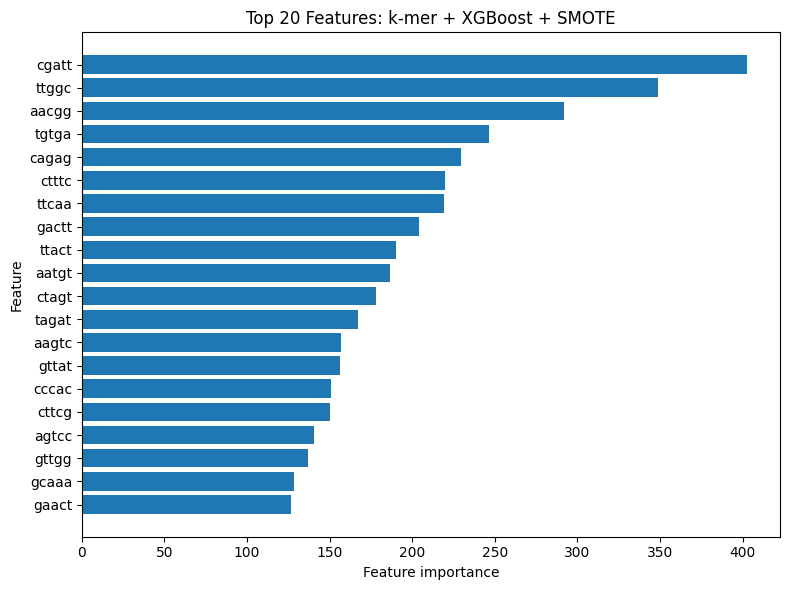

Saved figure: top20_features_kmer_xgboost_smote.png

Top features: k-mer + GC content + GC skew + Random Forest + SMOTE
       Feature  Importance  Rank
0   gc_content    0.008262     1
1        atcct    0.005349     2
2        gtcat    0.005307     3
3        gccta    0.005048     4
4        tcatc    0.004297     5
5        ctgcg    0.004123     6
6        catcc    0.004110     7
7        ggagg    0.004101     8
8        agact    0.004076     9
9        gggga    0.003796    10
10     gc_skew    0.003735    11
11       ggcaa    0.003622    12
12       ttcct    0.003583    13
13       cgtgg    0.003559    14
14       aatgt    0.003491    15
15       cgatt    0.003088    16
16       ggctg    0.003073    17
17       atcat    0.003067    18
18       tctgc    0.003030    19
19       aagtc    0.002973    20


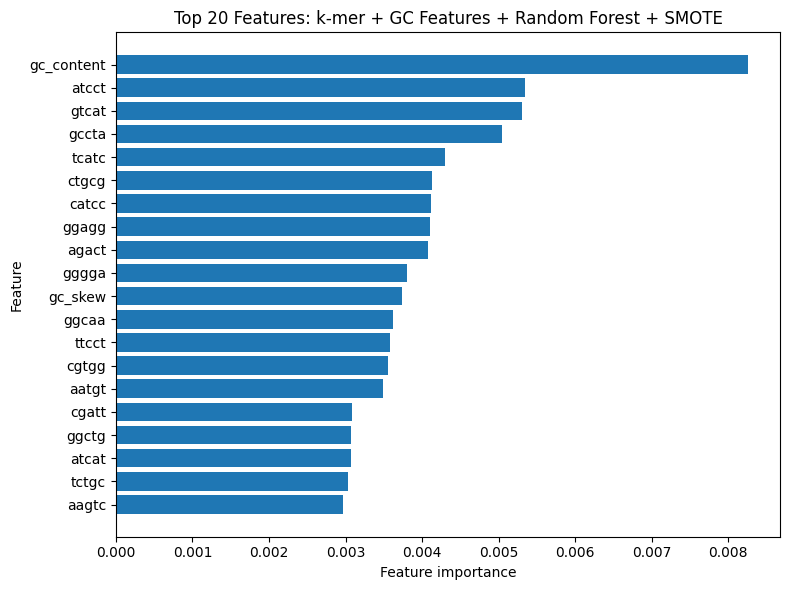

Saved figure: top20_features_kmer_gc_random_forest_smote.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb


# ============================================================
# 1. Safety check: X_train must be a DataFrame
# ============================================================

def check_dataframe(X, name="X"):
    if not isinstance(X, pd.DataFrame):
        raise TypeError(
            f"{name} must be a pandas DataFrame to preserve feature names. "
            "Do not use X_train = X_train.values before feature importance extraction."
        )


# ============================================================
# 2. XGBoost feature importance using gain
# ============================================================

def get_xgb_top_features_gain(
    fitted_pipeline,
    feature_names,
    top_k=20
):
    model = fitted_pipeline.named_steps["clf"]
    booster = model.get_booster()

    importance_dict = booster.get_score(
        importance_type="gain"
    )

    rows = []

    for i, feature_name in enumerate(feature_names):

        # XGBoost may use either "f0" style names or original feature names
        f_key = f"f{i}"

        if feature_name in importance_dict:
            importance = importance_dict[feature_name]
        elif f_key in importance_dict:
            importance = importance_dict[f_key]
        else:
            importance = 0.0

        rows.append({
            "Feature": feature_name,
            "Importance": importance
        })

    importance_df = pd.DataFrame(rows)

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    importance_df["Rank"] = np.arange(1, len(importance_df) + 1)

    return importance_df.head(top_k)


# ============================================================
# 3. Random Forest feature importance
# ============================================================

def get_rf_top_features(
    fitted_pipeline,
    feature_names,
    top_k=20
):
    model = fitted_pipeline.named_steps["clf"]

    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    importance_df["Rank"] = np.arange(1, len(importance_df) + 1)

    return importance_df.head(top_k)


# ============================================================
# 4. Plot top-k features
# ============================================================

def plot_top_features(
    top_features_df,
    title,
    output_path
):
    plot_df = top_features_df.sort_values(
        by="Importance",
        ascending=True
    )

    plt.figure(figsize=(8, 6))

    plt.barh(
        plot_df["Feature"],
        plot_df["Importance"]
    )

    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved figure: {output_path}")


# ============================================================
# 5. Selected Model 1:
#    k-mer + XGBoost + SMOTE
# ============================================================

# X_train_kmer and X_test_kmer should contain only k-mer features
# Example:
X_train_kmer = X_train.copy()
X_test_kmer  = X_test.copy()

check_dataframe(X_train_kmer, "X_train_kmer")

xgb_kmer_smote_pipeline = Pipeline([
    ("smote", SMOTE(
        sampling_strategy="auto",
        random_state=42
    )),
    ("clf", xgb.XGBClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ))
])

xgb_kmer_smote_pipeline.fit(
    X_train_kmer,
    y_train
)

top_k_xgb = get_xgb_top_features_gain(
    fitted_pipeline=xgb_kmer_smote_pipeline,
    feature_names=X_train_kmer.columns,
    top_k=20
)

print("\nTop features: k-mer + XGBoost + SMOTE")
print(top_k_xgb)

top_k_xgb.to_csv(
    "top20_features_kmer_xgboost_smote.csv",
    index=False
)

plot_top_features(
    top_features_df=top_k_xgb,
    title="Top 20 Features: k-mer + XGBoost + SMOTE",
    output_path="top20_features_kmer_xgboost_smote.png"
)


# ============================================================
# 6. Selected Model 2:
#    k-mer + GC content + GC skew + Random Forest + SMOTE
# ============================================================

# X_train_kmer_gc and X_test_kmer_gc should contain:
# - k-mer features
# - GC content
# - GC skew
#
# Example:
X_train_kmer_gc = X_train.copy()
X_test_kmer_gc  = X_test.copy()

check_dataframe(X_train_kmer_gc, "X_train_kmer_gc")

rf_kmer_gc_smote_pipeline = Pipeline([
    ("smote", SMOTE(
        sampling_strategy="auto",
        random_state=42
    )),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_kmer_gc_smote_pipeline.fit(
    X_train_kmer_gc,
    y_train
)

top_k_rf = get_rf_top_features(
    fitted_pipeline=rf_kmer_gc_smote_pipeline,
    feature_names=X_train_kmer_gc.columns,
    top_k=20
)

print("\nTop features: k-mer + GC content + GC skew + Random Forest + SMOTE")
print(top_k_rf)

top_k_rf.to_csv(
    "top20_features_kmer_gc_random_forest_smote.csv",
    index=False
)

plot_top_features(
    top_features_df=top_k_rf,
    title="Top 20 Features: k-mer + GC Features + Random Forest + SMOTE",
    output_path="top20_features_kmer_gc_random_forest_smote.png"
)

In [ ]:
#### statistical analysis

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier


# ============================================================
# INPUTS YOU MUST PROVIDE
# ============================================================

# You must already have:
# X_train: your feature dataframe or array
# y_train: your class labels

# ------------------------------------------------------------
# CASE 1:
# If X_train already contains both k-mer features and GC features,
# define your GC feature names here.
# ------------------------------------------------------------

gc_feature_names = ["gc_content", "gc_skew"]  # modify if needed

# Convert X_train to DataFrame if it is not already
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train)

# Detect which GC columns exist
available_gc_features = [col for col in gc_feature_names if col in X_train.columns]

print("Available GC features:", available_gc_features)

# k-mer only features = remove GC-related columns
X_kmer = X_train.drop(columns=available_gc_features, errors="ignore")

# k-mer + GC features = keep all features
X_kmer_gc = X_train.copy()


# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train)

print("Classes:", list(label_encoder.classes_))


# ============================================================
# MODELS
# ============================================================

n_classes = len(np.unique(y_encoded))

models = {
    "RF": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight=None
    ),

    "XGB": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob" if n_classes > 2 else "binary:logistic",
        num_class=n_classes if n_classes > 2 else None,
        eval_metric="mlogloss" if n_classes > 2 else "logloss",
        random_state=42,
        n_jobs=-1
    )
}


# Remove num_class=None for binary XGBoost
if n_classes == 2:
    models["XGB"].set_params(num_class=None)


# ============================================================
# CROSS-VALIDATION CONFIG
# ============================================================

n_splits = 5

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)


# ============================================================
# EXPERIMENTAL CONDITIONS
# ============================================================

conditions = [
    {
        "condition_name": "kmer_no_smote",
        "X": X_kmer,
        "smote": "No",
        "gc_features": "No"
    },
    {
        "condition_name": "kmer_smote",
        "X": X_kmer,
        "smote": "Yes",
        "gc_features": "No"
    },
    {
        "condition_name": "kmer_gc_no_smote",
        "X": X_kmer_gc,
        "smote": "No",
        "gc_features": "Yes"
    },
    {
        "condition_name": "kmer_gc_smote",
        "X": X_kmer_gc,
        "smote": "Yes",
        "gc_features": "Yes"
    }
]


# ============================================================
# MAIN LOOP TO GENERATE results.csv
# ============================================================

all_results = []

for model_name, base_model in models.items():

    print("\n" + "=" * 70)
    print("Running model:", model_name)
    print("=" * 70)

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_kmer, y_encoded), start=1):

        print(f"\nFold {fold_idx}/{n_splits}")

        for condition in conditions:

            condition_name = condition["condition_name"]
            X_current = condition["X"]
            smote_status = condition["smote"]
            gc_status = condition["gc_features"]

            X_tr = X_current.iloc[train_idx].copy()
            X_val = X_current.iloc[val_idx].copy()

            y_tr = y_encoded[train_idx]
            y_val = y_encoded[val_idx]

            # ------------------------------------------------
            # Apply SMOTE only on the training fold
            # This avoids data leakage.
            # ------------------------------------------------
            if smote_status == "Yes":
                smote = SMOTE(random_state=42)
                X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

            # ------------------------------------------------
            # Train model
            # ------------------------------------------------
            model = clone(base_model)
            model.fit(X_tr, y_tr)

            # ------------------------------------------------
            # Predict validation fold
            # ------------------------------------------------
            y_pred = model.predict(X_val)

            # ------------------------------------------------
            # Compute metrics
            # ------------------------------------------------
            accuracy = accuracy_score(y_val, y_pred)

            macro_f1 = f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0
            )

            weighted_f1 = f1_score(
                y_val,
                y_pred,
                average="weighted",
                zero_division=0
            )

            balanced_acc = balanced_accuracy_score(y_val, y_pred)

            # ------------------------------------------------
            # Store result
            # ------------------------------------------------
            all_results.append({
                "model": model_name,
                "fold": fold_idx,
                "condition": condition_name,
                "smote": smote_status,
                "gc_features": gc_status,
                "accuracy": accuracy,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1,
                "balanced_accuracy": balanced_acc,
                "n_train_original": len(train_idx),
                "n_train_after_smote": len(X_tr),
                "n_validation": len(val_idx)
            })

            print(
                f"{condition_name:20s} | "
                f"Accuracy={accuracy:.4f} | "
                f"Macro-F1={macro_f1:.4f} | "
                f"Balanced Acc={balanced_acc:.4f}"
            )


# ============================================================
# SAVE RESULTS
# ============================================================

results_df = pd.DataFrame(all_results)

results_df.to_csv("results.csv", index=False)

print("\nDone. Saved:")
print("results.csv")

print("\nPreview:")
print(results_df.head(12))

Available GC features: ['gc_content', 'gc_skew']
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Running model: RF

Fold 1/5
kmer_no_smote        | Accuracy=0.9852 | Macro-F1=0.9842 | Balanced Acc=0.9801
kmer_smote           | Accuracy=0.9876 | Macro-F1=0.9870 | Balanced Acc=0.9864
kmer_gc_no_smote     | Accuracy=0.9850 | Macro-F1=0.9845 | Balanced Acc=0.9804
kmer_gc_smote        | Accuracy=0.9861 | Macro-F1=0.9853 | Balanced Acc=0.9852

Fold 2/5
kmer_no_smote        | Accuracy=0.9830 | Macro-F1=0.9817 | Balanced Acc=0.9764
kmer_smote           | Accuracy=0.9885 | Macro-F1=0.9874 | Balanced Acc=0.9860
kmer_gc_no_smote     | Accuracy=0.9833 | Macro-F1=0.9815 | Balanced Acc=0.9752
kmer_gc_smote        | Accuracy=0.9880 | Macro-F1=0.9869 | Balanced Acc=0.9852

Fold 3/5
kmer_no_smote        | Accuracy=0.9830 | Macro-F1=0.9809 | Balanced Acc=0.9767
kmer_smote           | Accuracy=0.9863 | Macro-F1=0

In [ ]:
import pandas as pd
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, wilcoxon


# ============================================================
# LOAD RESULTS
# ============================================================

results_path = "results.csv"
df = pd.read_csv(results_path)

# Expected columns:
# model, fold, smote, gc_features, macro_f1, balanced_accuracy, accuracy

required_cols = ["model", "fold", "smote", "gc_features"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Clean categorical variables
df["model"] = df["model"].astype(str)
df["fold"] = df["fold"].astype(str)
df["smote"] = df["smote"].astype(str)
df["gc_features"] = df["gc_features"].astype(str)

# Optional: normalize labels if you used True/False or 0/1
df["smote"] = df["smote"].replace({
    "True": "Yes", "False": "No",
    "1": "Yes", "0": "No",
    "yes": "Yes", "no": "No",
    "YES": "Yes", "NO": "No"
})

df["gc_features"] = df["gc_features"].replace({
    "True": "Yes", "False": "No",
    "1": "Yes", "0": "No",
    "yes": "Yes", "no": "No",
    "YES": "Yes", "NO": "No"
})


# ============================================================
# CONFIGURATION
# ============================================================

metric = "macro_f1"   # Recommended: "macro_f1" or "balanced_accuracy"

if metric not in df.columns:
    raise ValueError(f"The metric column '{metric}' does not exist in the CSV file.")

models = sorted(df["model"].unique())

anova_outputs = []
pairwise_outputs = []


# ============================================================
# CHECK FUNCTION
# ============================================================

def check_repeated_measures_structure(data_model, model_name):
    """
    Ensures that each fold has the four required conditions:
    No/No, Yes/No, No/Yes, Yes/Yes.
    """

    expected_conditions = {
        ("No", "No"),
        ("Yes", "No"),
        ("No", "Yes"),
        ("Yes", "Yes"),
    }

    bad_folds = []

    for fold, group in data_model.groupby("fold"):
        observed_conditions = set(zip(group["smote"], group["gc_features"]))

        if observed_conditions != expected_conditions:
            bad_folds.append((fold, observed_conditions))

    if len(bad_folds) > 0:
        print(f"\nWARNING: Model {model_name} has incomplete repeated-measures folds.")
        for fold, observed in bad_folds:
            print(f"Fold {fold}: observed conditions = {observed}")

        raise ValueError(
            f"Model {model_name} does not have all four conditions for every fold. "
            "Repeated-measures ANOVA requires each fold to appear in all conditions."
        )


# ============================================================
# TWO-WAY REPEATED-MEASURES ANOVA
# ============================================================

for model_name in models:

    print("\n" + "=" * 70)
    print(f"MODEL: {model_name}")
    print("=" * 70)

    data_model = df[df["model"] == model_name].copy()

    # Keep only columns needed for ANOVA
    data_model = data_model[["fold", "smote", "gc_features", metric]].dropna()

    # Check that each fold has all four repeated conditions
    check_repeated_measures_structure(data_model, model_name)

    # Run two-way repeated-measures ANOVA
    anova = AnovaRM(
        data=data_model,
        depvar=metric,
        subject="fold",
        within=["smote", "gc_features"]
    ).fit()

    print(anova)

    # Store ANOVA table
    anova_table = anova.anova_table.reset_index()
    anova_table = anova_table.rename(columns={"index": "effect"})
    anova_table["model"] = model_name
    anova_table["metric"] = metric

    anova_outputs.append(anova_table)


# ============================================================
# SAVE ANOVA RESULTS
# ============================================================

anova_results_df = pd.concat(anova_outputs, ignore_index=True)
anova_results_df.to_csv("two_way_repeated_measures_anova_results.csv", index=False)

print("\nSaved ANOVA results to:")
print("two_way_repeated_measures_anova_results.csv")


# ============================================================
# OPTIONAL: PAIRED POST-HOC COMPARISONS
# ============================================================

def paired_test(data_model, model_name, metric, condition_a, condition_b, test_name):
    """
    condition_a and condition_b should be dictionaries:
    example:
    {"smote": "No", "gc_features": "No"}
    """

    a = data_model.copy()
    b = data_model.copy()

    for col, val in condition_a.items():
        a = a[a[col] == val]

    for col, val in condition_b.items():
        b = b[b[col] == val]

    merged = pd.merge(
        a[["fold", metric]],
        b[["fold", metric]],
        on="fold",
        suffixes=("_A", "_B")
    )

    scores_a = merged[f"{metric}_A"]
    scores_b = merged[f"{metric}_B"]

    diff = scores_b - scores_a

    mean_a = scores_a.mean()
    mean_b = scores_b.mean()
    mean_diff = diff.mean()

    # Paired t-test
    t_stat, t_p = ttest_rel(scores_b, scores_a)

    # Wilcoxon signed-rank test
    try:
        w_stat, w_p = wilcoxon(scores_b, scores_a)
    except ValueError:
        w_stat, w_p = None, None

    # Cohen's dz
    if diff.std(ddof=1) != 0:
        cohen_dz = diff.mean() / diff.std(ddof=1)
    else:
        cohen_dz = float("nan")

    result = {
        "model": model_name,
        "metric": metric,
        "test": test_name,
        "condition_A": str(condition_a),
        "condition_B": str(condition_b),
        "n_folds": len(merged),
        "mean_A": mean_a,
        "mean_B": mean_b,
        "mean_difference_B_minus_A": mean_diff,
        "paired_t_p": t_p,
        "wilcoxon_p": w_p,
        "cohen_dz": cohen_dz
    }

    print("\n" + "-" * 60)
    print(test_name)
    print("Condition A:", condition_a)
    print("Condition B:", condition_b)
    print("Mean A:", mean_a)
    print("Mean B:", mean_b)
    print("Mean difference B - A:", mean_diff)
    print("Paired t-test p-value:", t_p)
    print("Wilcoxon p-value:", w_p)
    print("Cohen dz:", cohen_dz)

    return result


for model_name in models:

    print("\n" + "=" * 70)
    print(f"POST-HOC TESTS FOR MODEL: {model_name}")
    print("=" * 70)

    data_model = df[df["model"] == model_name].copy()
    data_model = data_model[["fold", "smote", "gc_features", metric]].dropna()

    # 1. Effect of SMOTE without GC features
    pairwise_outputs.append(
        paired_test(
            data_model,
            model_name,
            metric,
            condition_a={"smote": "No", "gc_features": "No"},
            condition_b={"smote": "Yes", "gc_features": "No"},
            test_name="SMOTE effect without GC features"
        )
    )

    # 2. Effect of SMOTE with GC features
    pairwise_outputs.append(
        paired_test(
            data_model,
            model_name,
            metric,
            condition_a={"smote": "No", "gc_features": "Yes"},
            condition_b={"smote": "Yes", "gc_features": "Yes"},
            test_name="SMOTE effect with GC features"
        )
    )

    # 3. Effect of GC features without SMOTE
    pairwise_outputs.append(
        paired_test(
            data_model,
            model_name,
            metric,
            condition_a={"smote": "No", "gc_features": "No"},
            condition_b={"smote": "No", "gc_features": "Yes"},
            test_name="GC feature effect without SMOTE"
        )
    )

    # 4. Effect of GC features with SMOTE
    pairwise_outputs.append(
        paired_test(
            data_model,
            model_name,
            metric,
            condition_a={"smote": "Yes", "gc_features": "No"},
            condition_b={"smote": "Yes", "gc_features": "Yes"},
            test_name="GC feature effect with SMOTE"
        )
    )


# ============================================================
# SAVE POST-HOC RESULTS
# ============================================================

pairwise_results_df = pd.DataFrame(pairwise_outputs)
pairwise_results_df.to_csv("paired_posthoc_tests.csv", index=False)

print("\nSaved paired post-hoc results to:")
print("paired_posthoc_tests.csv")


MODEL: RF
                    Anova
                  F Value Num DF Den DF Pr > F
----------------------------------------------
smote             24.0617 1.0000 4.0000 0.0080
gc_features        2.5702 1.0000 4.0000 0.1842
smote:gc_features  0.0400 1.0000 4.0000 0.8511


MODEL: XGB
                    Anova
                  F Value Num DF Den DF Pr > F
----------------------------------------------
smote              7.0027 1.0000 4.0000 0.0572
gc_features        0.7735 1.0000 4.0000 0.4288
smote:gc_features  0.2456 1.0000 4.0000 0.6462


Saved ANOVA results to:
two_way_repeated_measures_anova_results.csv

POST-HOC TESTS FOR MODEL: RF

------------------------------------------------------------
SMOTE effect without GC features
Condition A: {'smote': 'No', 'gc_features': 'No'}
Condition B: {'smote': 'Yes', 'gc_features': 'No'}
Mean A: 0.9808065431120851
Mean B: 0.9867695878232459
Mean difference B - A: 0.005963044711160581
Paired t-test p-value: 0.010588580919132147
Wilcoxon p-value

In [ ]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# FILE PATHS
# ============================================================

gt_csv_path = Path("new_testset/CollectedData_Ahmed.csv")

# Folder containing the ORIGINAL images
# IMPORTANT: use the folder containing the original images, not old output folders.
image_root = Path("new_testset")

# Output folder
output_dir = Path("gt_corridor_with_length_notation")
output_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# BODY PARTS AND SEGMENTS
# ============================================================

bodyparts = [
    "BackLeft_Trunk",
    "BackLeft_Hip",
    "BackLeft_Knee",
    "BackLeft_Ankle",
    "BackLeft_MTP",
    "BackLeft_Foot",
]

segments = [
    ("BackLeft_Trunk", "BackLeft_Hip"),
    ("BackLeft_Hip", "BackLeft_Knee"),
    ("BackLeft_Knee", "BackLeft_Ankle"),
    ("BackLeft_Ankle", "BackLeft_MTP"),
    ("BackLeft_MTP", "BackLeft_Foot"),
]


# ============================================================
# DISPLAY OPTIONS
# ============================================================

# Main anatomical visualization
SHOW_TUBE = False
SHOW_SKELETON = True
SHOW_JOINTS = True

# Segment-length notation
SHOW_LENGTH_NOTATION = True
SHOW_LENGTH_LABELS = True
SHOW_LENGTH_VALUES = False   # False = show L1, L2, ... only; True = show pixel values

# Background styling
DIM_BACKGROUND = True
DIM_FACTOR = 0.80

# Corridor radius = alpha * total GT limb length
alpha = 0.05


# ============================================================
# VISUAL STYLE
# ============================================================

# OpenCV uses BGR, not RGB
COLOR_TUBE = (255, 220, 60)          # cyan/yellow-like tube
COLOR_SKELETON = (80, 255, 120)      # bright green skeleton
COLOR_JOINTS = (0, 255, 255)         # yellow joints

COLOR_LENGTH_ARROW = (255, 255, 255) # white arrows
COLOR_LENGTH_LABEL = (247, 108, 0) # white text
# COLOR_LENGTH_BG = (0, 0, 0)          # black text background

# Tube appearance
OVERLAY_ALPHA_MAIN = 0.28
OVERLAY_ALPHA_GLOW = 0.18
GLOW_MULTIPLIER_1 = 1.8
GLOW_MULTIPLIER_2 = 1.25

# Skeleton and joints
SKELETON_THICKNESS = 3
JOINT_RADIUS = 6

# Length notation style
LENGTH_ARROW_OFFSET = 20
LENGTH_ARROW_THICKNESS = 2
LENGTH_TICK_SIZE = 5
LENGTH_LABEL_SCALE = 0.45
LENGTH_LABEL_THICKNESS = 2


# ============================================================
# CSV READING FUNCTIONS
# ============================================================

def read_gt_collected_data_csv(csv_path):
    """
    Reads a DeepLabCut CollectedData CSV and returns a dataframe indexed by image filename.

    Expected DLC CollectedData structure:
        metadata columns first, followed by:
        scorer / bodyparts / coords
    """
    raw = pd.read_csv(csv_path, header=[0, 1, 2])

    metadata_cols = [
        col for col in raw.columns
        if col[2] not in ["x", "y", "likelihood"]
    ]

    if len(metadata_cols) == 0:
        raise ValueError(
            "Could not detect metadata columns in the ground-truth CSV. "
            "Please check the CollectedData CSV structure."
        )

    # Usually the last metadata column contains the image filename
    frame_col = metadata_cols[-1]

    frame_names = raw[frame_col].astype(str).apply(lambda x: Path(x).name)

    df = raw.drop(columns=metadata_cols)
    df.index = frame_names
    df.columns.names = ["scorer", "bodyparts", "coords"]

    return df


def get_single_scorer(df):
    """
    Automatically detects the scorer name.
    """
    scorers = list(df.columns.get_level_values("scorer").unique())

    if len(scorers) == 0:
        raise ValueError("No scorer found in ground-truth dataframe.")

    if len(scorers) > 1:
        print("WARNING: multiple GT scorers found:", scorers)
        print("Using the first scorer:", scorers[0])

    return scorers[0]


def get_point(df, frame, scorer, bodypart):
    """
    Extracts x,y coordinates for a bodypart from a DLC-style dataframe.
    Returns None if missing or NaN.
    """
    try:
        x = df.loc[frame, (scorer, bodypart, "x")]
        y = df.loc[frame, (scorer, bodypart, "y")]
    except KeyError:
        return None

    if pd.isna(x) or pd.isna(y):
        return None

    return float(x), float(y)


# ============================================================
# GEOMETRY FUNCTIONS
# ============================================================

def euclidean_distance(p1, p2):
    """
    Euclidean distance between two 2D points.
    """
    p1 = np.array(p1, dtype=float)
    p2 = np.array(p2, dtype=float)
    return np.linalg.norm(p1 - p2)


# ============================================================
# IMAGE HELPERS
# ============================================================

def find_image_file(image_name, root_dir):
    """
    Find the original image recursively, while avoiding generated output folders.
    """
    excluded_dirs = {
        "gt_tube_only_pretty",
        "gt_corridor_pretty_with_options",
        "gt_corridor_with_length_notation",
        "tube_visualization_results",
        "tube_visualization_results_no_labels",
    }

    matches = []

    for path in root_dir.rglob(image_name):
        if not path.is_file():
            continue

        if any(part in excluded_dirs for part in path.parts):
            continue

        matches.append(path)

    if len(matches) == 0:
        return None

    if len(matches) > 1:
        print(f"WARNING: multiple matches found for {image_name}. Using the first one:")
        for m in matches:
            print("  ", m)

    return matches[0]


def draw_plain_text(
    img,
    text,
    org,
    font=cv2.FONT_HERSHEY_SIMPLEX,
    scale=0.45,
    color=(255, 255, 255),
    thickness=1
):
    """
    Draw plain text without any background box.
    """
    cv2.putText(
        img,
        text,
        org,
        font,
        scale,
        color,
        thickness,
        cv2.LINE_AA
    )


def draw_segment_length_notation(
    img,
    p1,
    p2,
    label="L",
    value_px=None,
    offset=20,
    color=(255, 255, 255),
    label_color=(255, 255, 255),
    show_label=True,
    show_value=False,
    arrow_thickness=2,
    tick_size=7
):
    """
    Draws a length notation beside a segment.

    It draws:
        - a double-headed arrow parallel to the segment
        - small endpoint ticks
        - optional label such as L1, L2, ...
        - optional length value in pixels
    """
    p1 = np.array(p1, dtype=float)
    p2 = np.array(p2, dtype=float)

    v = p2 - p1
    length = np.linalg.norm(v)

    if length == 0:
        return

    # Unit vector along the segment
    u = v / length

    # Perpendicular vector used to offset the notation away from the skeleton
    n = np.array([-u[1], u[0]])

    # Offset endpoints for the arrow
    q1 = p1 + offset * n
    q2 = p2 + offset * n

    q1_int = tuple(np.round(q1).astype(int))
    q2_int = tuple(np.round(q2).astype(int))

    # Draw double-headed arrow
    cv2.arrowedLine(
        img,
        q1_int,
        q2_int,
        color,
        arrow_thickness,
        cv2.LINE_AA,
        tipLength=0.08
    )

    cv2.arrowedLine(
        img,
        q2_int,
        q1_int,
        color,
        arrow_thickness,
        cv2.LINE_AA,
        tipLength=0.08
    )

    # Draw endpoint ticks
    tick_vec = tick_size * n

    t1a = tuple(np.round(q1 - tick_vec).astype(int))
    t1b = tuple(np.round(q1 + tick_vec).astype(int))

    t2a = tuple(np.round(q2 - tick_vec).astype(int))
    t2b = tuple(np.round(q2 + tick_vec).astype(int))

    cv2.line(img, t1a, t1b, color, arrow_thickness, cv2.LINE_AA)
    cv2.line(img, t2a, t2b, color, arrow_thickness, cv2.LINE_AA)

    # Draw optional label
    if show_label:
        midpoint = (q1 + q2) / 2

        if show_value and value_px is not None:
            text = f"{label}={value_px:.1f}px"
        else:
            text = label

        text_pos = tuple(np.round(midpoint + 10 * n).astype(int))

        draw_plain_text(
        img,
        text,
        text_pos,
        scale=LENGTH_LABEL_SCALE,
        color=label_color,
        thickness=LENGTH_LABEL_THICKNESS
    )


# ============================================================
# LOAD GROUND TRUTH
# ============================================================

gt_df = read_gt_collected_data_csv(gt_csv_path)
gt_scorer = get_single_scorer(gt_df)

print("GT scorer:", gt_scorer)
print("Number of annotated images:", len(gt_df))


# ============================================================
# MAIN LOOP
# ============================================================

saved_count = 0
missing_images = []

for frame in gt_df.index:

    image_path = find_image_file(frame, image_root)

    if image_path is None:
        missing_images.append(frame)
        continue

    img = cv2.imread(str(image_path))

    if img is None:
        missing_images.append(frame)
        continue

    # Slightly dim background to make the corridor stand out
    if DIM_BACKGROUND:
        img = (img.astype(np.float32) * DIM_FACTOR).clip(0, 255).astype(np.uint8)

    # --------------------------------------------------------
    # Collect ground-truth points
    # --------------------------------------------------------
    gt_points = {}

    for bp in bodyparts:
        pt = get_point(gt_df, frame, gt_scorer, bp)
        if pt is not None:
            gt_points[bp] = pt

    # --------------------------------------------------------
    # Build valid anatomical segments and compute limb length
    # --------------------------------------------------------
    valid_segments = []
    limb_length = 0.0

    for bp1, bp2 in segments:
        if bp1 in gt_points and bp2 in gt_points:

            p1 = gt_points[bp1]
            p2 = gt_points[bp2]

            seg_len = euclidean_distance(p1, p2)

            if seg_len > 0:
                valid_segments.append(
                    {
                        "name": f"{bp1}--{bp2}",
                        "bp1": bp1,
                        "bp2": bp2,
                        "p1": p1,
                        "p2": p2,
                        "length": seg_len,
                    }
                )

                limb_length += seg_len

    if len(valid_segments) == 0 or limb_length == 0:
        continue

    tolerance = alpha * limb_length

    out = img.copy()

    # --------------------------------------------------------
    # Draw anatomical corridor tube
    # --------------------------------------------------------
    if SHOW_TUBE:

        tube_thickness = max(4, int(round(2 * tolerance)))

        glow_thickness_1 = max(
            tube_thickness + 6,
            int(round(tube_thickness * GLOW_MULTIPLIER_1))
        )

        glow_thickness_2 = max(
            tube_thickness + 2,
            int(round(tube_thickness * GLOW_MULTIPLIER_2))
        )

        overlay_glow = out.copy()
        overlay_main = out.copy()

        for seg in valid_segments:
            p1 = tuple(np.round(seg["p1"]).astype(int))
            p2 = tuple(np.round(seg["p2"]).astype(int))

            # Outer glow
            cv2.line(
                overlay_glow,
                p1,
                p2,
                COLOR_TUBE,
                glow_thickness_1,
                cv2.LINE_AA
            )

            # Main tube
            cv2.line(
                overlay_main,
                p1,
                p2,
                COLOR_TUBE,
                glow_thickness_2,
                cv2.LINE_AA
            )

            cv2.line(
                overlay_main,
                p1,
                p2,
                COLOR_TUBE,
                tube_thickness,
                cv2.LINE_AA
            )

        out = cv2.addWeighted(
            overlay_glow,
            OVERLAY_ALPHA_GLOW,
            out,
            1 - OVERLAY_ALPHA_GLOW,
            0
        )

        out = cv2.addWeighted(
            overlay_main,
            OVERLAY_ALPHA_MAIN,
            out,
            1 - OVERLAY_ALPHA_MAIN,
            0
        )

    # --------------------------------------------------------
    # Draw connected skeleton
    # --------------------------------------------------------
    if SHOW_SKELETON:
        for seg in valid_segments:
            p1 = tuple(np.round(seg["p1"]).astype(int))
            p2 = tuple(np.round(seg["p2"]).astype(int))

            cv2.line(
                out,
                p1,
                p2,
                COLOR_SKELETON,
                SKELETON_THICKNESS,
                cv2.LINE_AA
            )

    # --------------------------------------------------------
    # Draw joints
    # --------------------------------------------------------
    if SHOW_JOINTS:
        for bp in bodyparts:
            if bp not in gt_points:
                continue

            p = tuple(np.round(gt_points[bp]).astype(int))

            # Filled joint marker
            cv2.circle(
                out,
                p,
                JOINT_RADIUS,
                COLOR_JOINTS,
                -1,
                cv2.LINE_AA
            )

            # Thin outline
            cv2.circle(
                out,
                p,
                JOINT_RADIUS + 2,
                COLOR_SKELETON,
                1,
                cv2.LINE_AA
            )

    # --------------------------------------------------------
    # Draw segment length notation
    # --------------------------------------------------------
    if SHOW_LENGTH_NOTATION:
        for seg_idx, seg in enumerate(valid_segments, start=1):

            p1 = tuple(np.round(seg["p1"]).astype(int))
            p2 = tuple(np.round(seg["p2"]).astype(int))

            draw_segment_length_notation(
                out,
                p1,
                p2,
                label=f"L{seg_idx}",
                value_px=seg["length"],
                offset=LENGTH_ARROW_OFFSET,
                color=COLOR_LENGTH_ARROW,
                label_color=COLOR_LENGTH_LABEL,
                show_label=SHOW_LENGTH_LABELS,
                show_value=SHOW_LENGTH_VALUES,
                arrow_thickness=LENGTH_ARROW_THICKNESS,
                tick_size=LENGTH_TICK_SIZE
            )

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------
    out_path = output_dir / frame
    cv2.imwrite(str(out_path), out)

    saved_count += 1


print(f"\nDone. Saved {saved_count} images to: {output_dir}")

if missing_images:
    print("\nImages not found:")
    for name in missing_images[:20]:
        print(" -", name)

    if len(missing_images) > 20:
        print(f"... and {len(missing_images) - 20} more.")

GT scorer: Ahmed
Number of annotated images: 21

Done. Saved 21 images to: gt_corridor_with_length_notation


In [ ]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# FILE PATHS
# ============================================================

gt_csv_path = Path("new_testset/CollectedData_Ahmed.csv")

pred_csv_path = Path(
    "new_testset/image_predictions_DLC_DlcrnetStride32Ms5_Cam1Apr16shuffle2_snapshot_100.csv"
)

# Root folder containing your ORIGINAL images
# Prefer a specific folder instead of "." if possible.
image_root = Path(".")

# Output folder
output_dir = Path("tube_visualization_results_name_labels")
output_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# CONFIG
# ============================================================

gt_scorer = "Ahmed"

bodyparts = [
    "BackLeft_Trunk",
    "BackLeft_Hip",
    "BackLeft_Knee",
    "BackLeft_Ankle",
    "BackLeft_MTP",
    "BackLeft_Foot",
]

segments = [
    ("BackLeft_Trunk", "BackLeft_Hip"),
    ("BackLeft_Hip", "BackLeft_Knee"),
    ("BackLeft_Knee", "BackLeft_Ankle"),
    ("BackLeft_Ankle", "BackLeft_MTP"),
    ("BackLeft_MTP", "BackLeft_Foot"),
]

expected_segments = {
    "BackLeft_Trunk": [
        ("BackLeft_Trunk", "BackLeft_Hip"),
    ],
    "BackLeft_Hip": [
        ("BackLeft_Trunk", "BackLeft_Hip"),
        ("BackLeft_Hip", "BackLeft_Knee"),
    ],
    "BackLeft_Knee": [
        ("BackLeft_Hip", "BackLeft_Knee"),
        ("BackLeft_Knee", "BackLeft_Ankle"),
    ],
    "BackLeft_Ankle": [
        ("BackLeft_Knee", "BackLeft_Ankle"),
        ("BackLeft_Ankle", "BackLeft_MTP"),
    ],
    "BackLeft_MTP": [
        ("BackLeft_Ankle", "BackLeft_MTP"),
        ("BackLeft_MTP", "BackLeft_Foot"),
    ],
    "BackLeft_Foot": [
        ("BackLeft_MTP", "BackLeft_Foot"),
    ],
}

alpha = 0.05
pcutoff = None  # set to 0.6 or 0.9 if you want to ignore low-confidence predictions


# ============================================================
# DISPLAY OPTIONS
# ============================================================

SHOW_TUBE = True
SHOW_GT_LINES = True
SHOW_GT_POINTS = True
SHOW_PRED_POINTS = True

SHOW_GT_LABELS = True
SHOW_PRED_LABELS = True

# If True, labels will be shortened:
# BackLeft_Trunk -> Trunk
# BackLeft_Hip   -> Hip
SHORT_LABELS = True


# ============================================================
# DRAWING SETTINGS
# ============================================================

# Colors are BGR for OpenCV
COLOR_GT_POINT = (0, 255, 0)          # green
COLOR_GT_LINE = (0, 180, 0)           # darker green
COLOR_TUBE = (255, 200, 0)            # cyan-ish tube
COLOR_PRED_INSIDE = (0, 255, 255)     # yellow
COLOR_PRED_OUTSIDE = (0, 0, 255)      # red

COLOR_GT_TEXT = (0, 255, 0)           # green text for GT labels
COLOR_PRED_TEXT = (255, 255, 255)     # white text for predicted labels

POINT_RADIUS_GT = 5
POINT_RADIUS_PRED = 5

TEXT_SCALE = 0.5
TEXT_THICKNESS = 1

OVERLAY_ALPHA = 0.25  # transparency for tube


# ============================================================
# GEOMETRY FUNCTIONS
# ============================================================

def euclidean_distance(p1, p2):
    p1 = np.array(p1, dtype=float)
    p2 = np.array(p2, dtype=float)
    return np.linalg.norm(p1 - p2)


def point_to_segment_distance(point, seg_start, seg_end):
    p = np.array(point, dtype=float)
    a = np.array(seg_start, dtype=float)
    b = np.array(seg_end, dtype=float)

    ab = b - a
    ap = p - a

    denom = np.dot(ab, ab)

    if denom == 0:
        return np.linalg.norm(p - a)

    t = np.dot(ap, ab) / denom
    t = np.clip(t, 0, 1)

    closest = a + t * ab

    return np.linalg.norm(p - closest)


# ============================================================
# CSV LOADING FUNCTIONS
# ============================================================

def read_gt_collected_data_csv(csv_path):
    raw = pd.read_csv(csv_path, header=[0, 1, 2])

    metadata_cols = [
        col for col in raw.columns
        if col[2] not in ["x", "y", "likelihood"]
    ]

    if len(metadata_cols) == 0:
        raise ValueError("Could not detect metadata columns in GT CSV.")

    frame_col = metadata_cols[-1]
    frame_names = raw[frame_col].astype(str).apply(lambda x: Path(x).name)

    df = raw.drop(columns=metadata_cols)
    df.index = frame_names
    df.columns.names = ["scorer", "bodyparts", "coords"]

    return df


def read_prediction_csv(csv_path):
    """
    Reads a DLC prediction CSV in 4-level format:
        scorer / individuals / bodyparts / coords
    """
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    df.index = [Path(str(idx)).name for idx in df.index]

    df.columns = pd.MultiIndex.from_tuples(
        [
            (scorer, bodypart, coord)
            for scorer, individual, bodypart, coord in df.columns
        ],
        names=["scorer", "bodyparts", "coords"]
    )

    return df


def get_single_scorer(df):
    scorers = list(df.columns.get_level_values("scorer").unique())

    if len(scorers) == 0:
        raise ValueError("No scorer found.")

    if len(scorers) != 1:
        print("WARNING: multiple scorers found:", scorers)
        print("Using first scorer:", scorers[0])

    return scorers[0]


def get_point(df, frame, scorer, bodypart):
    try:
        x = df.loc[frame, (scorer, bodypart, "x")]
        y = df.loc[frame, (scorer, bodypart, "y")]
    except KeyError:
        return None

    if pd.isna(x) or pd.isna(y):
        return None

    return float(x), float(y)


def get_likelihood(df, frame, scorer, bodypart):
    try:
        likelihood = df.loc[frame, (scorer, bodypart, "likelihood")]
    except KeyError:
        return None

    if pd.isna(likelihood):
        return None

    return float(likelihood)


# ============================================================
# IMAGE HELPERS
# ============================================================

def clean_bodypart_name(bodypart):
    """
    Convert BackLeft_Hip -> Hip if SHORT_LABELS=True.
    """
    if SHORT_LABELS:
        return bodypart.replace("BackLeft_", "")
    return bodypart


def find_image_file(image_name, root_dir):
    """
    Search recursively for the original image file while ignoring old output folders.
    This prevents loading an already-labeled image.
    """
    excluded_dirs = {
        "tube_visualization_results",
        "tube_visualization_results_no_labels",
        "tube_visualization_results_name_labels",
        "gt_tube_only_pretty",
        "gt_corridor_pretty_with_options",
        "gt_corridor_with_length_notation",
    }

    matches = []

    for path in root_dir.rglob(image_name):
        if not path.is_file():
            continue

        if any(part in excluded_dirs for part in path.parts):
            continue

        matches.append(path)

    if len(matches) == 0:
        return None

    if len(matches) > 1:
        print(f"WARNING: multiple image matches found for {image_name}. Using the first:")
        for m in matches:
            print("  ", m)

    return matches[0]


def draw_plain_text(
    img,
    text,
    org,
    font=cv2.FONT_HERSHEY_SIMPLEX,
    scale=TEXT_SCALE,
    color=(255, 255, 255),
    thickness=TEXT_THICKNESS
):
    """
    Draw plain text with no background box.
    """
    cv2.putText(
        img,
        text,
        org,
        font,
        scale,
        color,
        thickness,
        cv2.LINE_AA
    )


# ============================================================
# LOAD DATA
# ============================================================

gt_df = read_gt_collected_data_csv(gt_csv_path)
pred_df = read_prediction_csv(pred_csv_path)

pred_scorer = get_single_scorer(pred_df)

common_frames = gt_df.index.intersection(pred_df.index)

print("GT scorers:", list(gt_df.columns.get_level_values("scorer").unique()))
print("Prediction scorer:", pred_scorer)
print("Number of common frames:", len(common_frames))

if len(common_frames) == 0:
    raise ValueError("No matching images found between GT and prediction files.")


# ============================================================
# MAIN VISUALIZATION LOOP
# ============================================================

saved_count = 0
missing_images = []

for frame in common_frames:

    image_path = find_image_file(frame, image_root)

    if image_path is None:
        missing_images.append(frame)
        continue

    img = cv2.imread(str(image_path))

    if img is None:
        missing_images.append(frame)
        continue

    gt_points = {}
    pred_points = {}

    for bp in bodyparts:

        gt_pt = get_point(gt_df, frame, gt_scorer, bp)
        if gt_pt is not None:
            gt_points[bp] = gt_pt

        pred_pt = get_point(pred_df, frame, pred_scorer, bp)
        if pred_pt is not None:
            likelihood = get_likelihood(pred_df, frame, pred_scorer, bp)

            if pcutoff is not None:
                if likelihood is None or likelihood < pcutoff:
                    continue

            pred_points[bp] = {
                "point": pred_pt,
                "likelihood": likelihood
            }

    # --------------------------------------------------------
    # Build GT valid segments and limb length
    # --------------------------------------------------------
    valid_segments = {}
    limb_length = 0.0

    for bp1, bp2 in segments:

        if bp1 in gt_points and bp2 in gt_points:

            p1 = gt_points[bp1]
            p2 = gt_points[bp2]

            seg_len = euclidean_distance(p1, p2)

            if seg_len > 0:
                valid_segments[(bp1, bp2)] = {
                    "start": p1,
                    "end": p2,
                    "length": seg_len,
                }

                limb_length += seg_len

    if limb_length == 0 or len(valid_segments) == 0:
        continue

    tolerance = alpha * limb_length
    tube_thickness = max(2, int(round(2 * tolerance)))

    # --------------------------------------------------------
    # Draw tube overlay
    # --------------------------------------------------------
    if SHOW_TUBE:

        overlay = img.copy()

        for (bp1, bp2), seg_data in valid_segments.items():

            p1 = tuple(map(int, map(round, seg_data["start"])))
            p2 = tuple(map(int, map(round, seg_data["end"])))

            cv2.line(
                overlay,
                p1,
                p2,
                COLOR_TUBE,
                tube_thickness,
                cv2.LINE_AA
            )

        img = cv2.addWeighted(
            overlay,
            OVERLAY_ALPHA,
            img,
            1 - OVERLAY_ALPHA,
            0
        )

    # --------------------------------------------------------
    # Draw GT limb lines
    # --------------------------------------------------------
    if SHOW_GT_LINES:

        for (bp1, bp2), seg_data in valid_segments.items():

            p1 = tuple(map(int, map(round, seg_data["start"])))
            p2 = tuple(map(int, map(round, seg_data["end"])))

            cv2.line(
                img,
                p1,
                p2,
                COLOR_GT_LINE,
                2,
                cv2.LINE_AA
            )

    # --------------------------------------------------------
    # Draw GT points and name-only labels
    # --------------------------------------------------------
    if SHOW_GT_POINTS:

        for bp, pt in gt_points.items():

            p = tuple(map(int, map(round, pt)))

            cv2.circle(
                img,
                p,
                POINT_RADIUS_GT,
                COLOR_GT_POINT,
                -1,
                cv2.LINE_AA
            )

            if SHOW_GT_LABELS:
                label = clean_bodypart_name(bp)

                draw_plain_text(
                    img,
                    label,
                    (p[0] + 6, p[1] - 6),
                    color=COLOR_GT_TEXT
                )

    # --------------------------------------------------------
    # Draw predicted points and name-only labels
    # --------------------------------------------------------
    if SHOW_PRED_POINTS:

        for bp, pred_info in pred_points.items():

            pred_pt = pred_info["point"]

            expected_distances = []

            for expected_seg in expected_segments[bp]:

                if expected_seg in valid_segments:

                    seg_data = valid_segments[expected_seg]

                    d = point_to_segment_distance(
                        pred_pt,
                        seg_data["start"],
                        seg_data["end"]
                    )

                    expected_distances.append(
                        (d, expected_seg[0], expected_seg[1])
                    )

            if len(expected_distances) == 0:
                continue

            min_d, seg_start, seg_end = min(
                expected_distances,
                key=lambda x: x[0]
            )

            inside = min_d <= tolerance

            color = COLOR_PRED_INSIDE if inside else COLOR_PRED_OUTSIDE

            p = tuple(map(int, map(round, pred_pt)))

            cv2.circle(
                img,
                p,
                POINT_RADIUS_PRED,
                color,
                -1,
                cv2.LINE_AA
            )

            cv2.circle(
                img,
                p,
                POINT_RADIUS_PRED + 2,
                color,
                1,
                cv2.LINE_AA
            )

            if SHOW_PRED_LABELS:
                label = clean_bodypart_name(bp)

                draw_plain_text(
                    img,
                    label,
                    (p[0] + 6, p[1] + 16),
                    color=COLOR_PRED_TEXT
                )

    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------
    out_path = output_dir / frame
    cv2.imwrite(str(out_path), img)

    saved_count += 1


print(f"\nDone. Saved {saved_count} visualized images to: {output_dir}")

if missing_images:
    print("\nImages not found:")
    for name in missing_images[:20]:
        print(" -", name)

    if len(missing_images) > 20:
        print(f"... and {len(missing_images) - 20} more.")

GT scorers: ['Ahmed']
Prediction scorer: DLC_DlcrnetStride32Ms5_Cam1Apr16shuffle2_snapshot_100
Number of common frames: 21

Done. Saved 21 visualized images to: tube_visualization_results_name_labels


In [ ]:
import re
from pathlib import Path

import pandas as pd


INPUT_FILE = Path("results.txt")
OUTPUT_FILE = Path("filtered_model_metrics.csv")

REQUIRED_METRICS = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall/Sensitivity",
    "Macro Specificity",
    "Macro F1-score",
    "Macro AUC-ROC",
    "Matthews Correlation Coefficient",
]


def clean_section_name(line: str) -> str:
    """Remove comment markers and surrounding whitespace."""
    return line.strip().lstrip("#").strip()


def read_required_metrics(file_path: Path) -> pd.DataFrame:
    records = []
    current_encoding_method = None

    # Example metric row:
    # # 0 xgboost Accuracy 0.807920
    row_pattern = re.compile(
        r"^\s*#?\s*\d+\s+"
        r"(?P<model>\S+)\s+"
        r"(?P<metric>.*?)\s+"
        r"(?P<value>-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*$"
    )

    with file_path.open("r", encoding="utf-8") as file:
        for raw_line in file:
            line = raw_line.strip()

            if not line:
                continue

            # Detect encoding/feature section headers.
            section_name = clean_section_name(line)
            section_lower = section_name.lower()

            if (
                not section_name.startswith("Model")
                and any(
                    keyword in section_lower
                    for keyword in ("encoding", "fcgr", "kmer")
                )
                and "metric" not in section_lower
            ):
                current_encoding_method = section_name
                continue

            match = row_pattern.match(line)
            if not match or current_encoding_method is None:
                continue

            metric = match.group("metric").strip()

            if metric not in REQUIRED_METRICS:
                continue

            records.append(
                {
                    "Encoding Method": current_encoding_method,
                    "Model": match.group("model"),
                    "Metric": metric,
                    "Value": float(match.group("value")),
                }
            )

    if not records:
        raise ValueError(
            "No matching metric rows were found. "
            "Check that the input file follows the expected format."
        )

    return pd.DataFrame(records)


def main() -> None:
    long_df = read_required_metrics(INPUT_FILE)

    # Convert from one-row-per-metric to one-row-per-encoding-and-model.
    result_df = (
        long_df.pivot_table(
            index=["Encoding Method", "Model"],
            columns="Metric",
            values="Value",
            aggfunc="first",
        )
        .reindex(columns=REQUIRED_METRICS)
        .reset_index()
    )

    # Remove the internal pandas column-axis label.
    result_df.columns.name = None

    result_df.to_csv(OUTPUT_FILE, index=False)

    print(result_df.to_string(index=False))
    print(f"\nSaved filtered results to: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

            Encoding Method         Model  Accuracy  Macro Precision  Macro Recall/Sensitivity  Macro Specificity  Macro F1-score  Macro AUC-ROC  Matthews Correlation Coefficient
fcgr + random undersampling           knn  0.861457         0.755182                  0.828898           0.979016        0.758985       0.948071                          0.801275
fcgr + random undersampling           mlp  0.849736         0.792314                  0.875628           0.980688        0.821061       0.964097                          0.797032
fcgr + random undersampling random_forest  0.860507         0.793687                  0.846454           0.981838        0.810030       0.970707                          0.810884
fcgr + random undersampling       xgboost  0.857339         0.734188                  0.829030           0.981589        0.769752       0.963472                          0.805430
               fcgr + smote           knn  0.947202         0.794312                  0.941030           